## Questão 1 - EDA (Análise Exploratória de Dados)

**Cenário:** Antes de qualquer análise, modelagem ou tomada de decisão, é fundamental entender o que existe nos dados. O Sr. Almir quer uma resposta simples: “Posso confiar nesses dados para tomar decisões?”

**Sua missão:** Realizar uma análise exploratória inicial do dataset `vendas_2023_2024.csv` e responder perguntas básicas, porém críticas, sobre volume, distribuição e qualidade dos dados.

**Premissas obrigatórias:**
*   Utilize apenas o dataset `vendas_2023_2024.csv`.
*   Não faça limpeza nem tratamento dos dados.
*   Apenas observe, agregue e descreva.

### Questão 1.1 - Código SQL (01)

O código SQL abaixo foi utilizado para extrair as métricas solicitadas:
* Quantidade total de linhas
* Quantidade total de colunas
* Intervalo de datas analisado (data mínima e máxima)
* Valor mínimo
* Valor máximo
* Valor médio

``` sql
SELECT
    COUNT(*) AS total_linhas,
    6 AS total_colunas,
    MIN(CAST(sale_date AS DATE)) AS data_minima,
    MAX(CAST(sale_date AS DATE)) AS data_maxima,
    MIN(total) AS valor_minimo,
    MAX(total) AS valor_maximo,
    ROUND(AVG(total), 2) AS valor_medio
FROM 'vendas_2023_2024.csv';
```


In [1]:
# @title
# =============================================================================
# DESAFIO LIGHTHOUSE - LH NAUTICAL
# Questão 1.1 - SQL
# EDA com validação cruzada Python vs SQL para garantir confiabilidade
# =============================================================================

import pandas as pd
import duckdb
import sys
from datetime import datetime

# =============================================================================
# CONFIGURAÇÕES
# =============================================================================

FILE_PATH = 'vendas_2023_2024.csv'
VALUE_COLUMN = 'total'
DUCKDB_TABLE_NAME = 'vendas_df'
TOLERANCIA_FLOAT = 0.01

# =============================================================================
# FUNÇÕES
# =============================================================================

def load_data(path):
    """
    Carrega o dataset CSV e identifica dinamicamente a coluna de data.
    """
    try:
        df = pd.read_csv(path)

        possible_date_cols = ['data_venda', 'sale_date', 'data']
        actual_col = next((c for c in df.columns if c in possible_date_cols), None)

        if not actual_col:
            actual_col = next((c for c in df.columns
                              if 'data' in c.lower() or 'date' in c.lower() or 'sale' in c.lower()), None)

        if not actual_col:
            print(f"ERRO: Nenhuma coluna de data identificada no arquivo '{path}'.")
            print(f"Colunas disponíveis: {list(df.columns)}")
            sys.exit(1)

        print(f"Data: '{actual_col}'") # Saída mais concisa
        return df, actual_col

    except FileNotFoundError:
        print(f"ERRO CRITICO: Arquivo '{path}' não encontrado.")
        sys.exit(1)
    except Exception as e:
        print(f"ERRO INESPERADO ao carregar dados: {str(e)}")
        sys.exit(1)


def calculate_metrics_pandas(df, date_col, value_col):
    """
    Calcula métricas descritivas usando Pandas.
    """
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')

    return {
        "total_linhas": len(df),
        "total_colunas": len(df.columns),
        "data_min": df[date_col].min().strftime('%Y-%m-%d') if pd.notna(df[date_col].min()) else None,
        "data_max": df[date_col].max().strftime('%Y-%m-%d') if pd.notna(df[date_col].max()) else None,
        "valor_min": df[value_col].min(),
        "valor_max": df[value_col].max(),
        "valor_medio": round(df[value_col].mean(), 2)
    }


def calculate_metrics_sql(con, table_name, date_col, value_col):
    """
    Calcula métricas descritivas usando SQL (DuckDB).
    """
    query = f"""
    SELECT
        COUNT(*) AS total_linhas,
        (SELECT COUNT(*) FROM PRAGMA_TABLE_INFO('{table_name}')) AS total_colunas,
        CAST(MIN({date_col}) AS DATE) AS data_min,
        CAST(MAX({date_col}) AS DATE) AS data_max,
        MIN({value_col}) AS valor_min,
        MAX({value_col}) AS valor_max,
        ROUND(AVG({value_col}), 2) AS valor_medio
    FROM {table_name}
    """

    try:
        res = con.execute(query).fetchdf().iloc[0].to_dict()

        if pd.notna(res.get('data_min')):
            res['data_min'] = pd.to_datetime(res['data_min']).strftime('%Y-%m-%d')
        if pd.notna(res.get('data_max')):
            res['data_max'] = pd.to_datetime(res['data_max']).strftime('%Y-%m-%d')

        return res

    except Exception as e:
        print(f"ERRO na execução SQL: {str(e)}")
        raise


def compare_results(py_res, sql_res):
    """
    Compara resultados do Python e SQL com tolerância para floats.
    """
    print(f"\n--- Validação Cruzada (Python vs SQL) ---") # Título mais simples
    print(f"{'Metrica':<15} | {'Python':<15} | {'SQL':<15} | {'Status'}")
    print(f"{'-'*65}") # Linha de separação mais curta

    all_match = True

    for key in py_res.keys():
        v_py = py_res[key]
        v_sql = sql_res.get(key)

        if isinstance(v_py, (int, float)) and isinstance(v_sql, (int, float)):
            match = abs(float(v_py) - float(v_sql)) < TOLERANCIA_FLOAT
        else:
            match = (str(v_py) == str(v_sql))

        status = "OK" if match else "DIFERENTE"
        if not match:
            all_match = False

        print(f"{key:<15} | {str(v_py):<15} | {str(v_sql):<15} | {status}")

    print(f"{'-'*65}") # Linha de separação mais curta

    if all_match:
        print("Validação: OK") # Mensagem mais concisa
    else:
        print("Validação: Divergências encontradas") # Mensagem mais concisa

    return all_match


def generate_deliverable_query(file_path, date_col, value_col):
    """
    Gera a query SQL pronta para entrega (Questão 1.1).
    """
    print(f"\n--- Query SQL para Questão 1.1 ---") # Título mais simples

    with duckdb.connect(database=':memory:') as con:
        con.register('temp_df', pd.read_csv(file_path))
        total_colunas = con.execute(f"SELECT COUNT(*) FROM PRAGMA_TABLE_INFO('temp_df')").fetchone()[0]

    print(f"""
SELECT
    COUNT(*) AS total_linhas,
    {total_colunas} AS total_colunas,
    MIN(CAST({date_col} AS DATE)) AS data_minima,
    MAX(CAST({date_col} AS DATE)) AS data_maxima,
    MIN({value_col}) AS valor_minimo,
    MAX({value_col}) AS valor_maximo,
    ROUND(AVG({value_col}), 2) AS valor_medio
FROM '{file_path}';
""")


# =============================================================================
# EXECUCAO PRINCIPAL
# =============================================================================

if __name__ == "__main__":

    print(f"\n--- Desafio Lighthouse - Questão 01 (EDA) ---") # Título mais simples
    print(f"Executado em: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")

    try:
        df, date_col = load_data(FILE_PATH)

        py_res = calculate_metrics_pandas(df, date_col, VALUE_COLUMN)
        sql_res = {} # Inicializa para evitar erro se a conexão SQL falhar

        with duckdb.connect(database=':memory:') as con:
            con.register(DUCKDB_TABLE_NAME, df)
            sql_res = calculate_metrics_sql(con, DUCKDB_TABLE_NAME, date_col, VALUE_COLUMN)

        validation_passed = compare_results(py_res, sql_res)

        generate_deliverable_query(FILE_PATH, date_col, VALUE_COLUMN)

        if validation_passed:
            print("\nStatus: Concluído com sucesso.") # Mensagem mais concisa
        else:
            print("\nStatus: Concluído com ressalvas.") # Mensagem mais concisa

    except Exception as e:
        print(f"\nERRO FATAL: {str(e)}")
        sys.exit(1)



--- Desafio Lighthouse - Questão 01 (EDA) ---
Executado em: 2026-03-22 13:35:47

Data: 'sale_date'

--- Validação Cruzada (Python vs SQL) ---
Metrica         | Python          | SQL             | Status
-----------------------------------------------------------------
total_linhas    | 9895            | 9895            | OK
total_colunas   | 6               | 6               | OK
data_min        | 2023-01-01      | 2023-01-01      | OK
data_max        | 2024-12-31      | 2024-12-31      | OK
valor_min       | 294.5           | 294.5           | OK
valor_max       | 2222973.0       | 2222973.0       | OK
valor_medio     | 263797.83       | 263797.83       | OK
-----------------------------------------------------------------
Validação: OK

--- Query SQL para Questão 1.1 ---

SELECT
    COUNT(*) AS total_linhas,
    6 AS total_colunas,
    MIN(CAST(sale_date AS DATE)) AS data_minima,
    MAX(CAST(sale_date AS DATE)) AS data_maxima,
    MIN(total) AS valor_minimo,
    MAX(total) AS valor

### Questão 1.2 - Validação (02)
Qual é o valor máximo registrado na coluna "total"?

**Resposta:** O valor máximo foi R$ 2.222.973,00.


In [19]:
# @title
# ================================================================================================
# DESAFIO LIGHTHOUSE - LH NAUTICAL
# Questão 1.2: Validação
# Valor Máximo da Coluna "total" (identificação do valor máximo registrado na coluna de vendas)
# ===============================================================================================

import pandas as pd
import duckdb
import sys
from datetime import datetime

# =============================================================================
# CONFIGURAÇÕES
# =============================================================================

FILE_PATH = 'vendas_2023_2024.csv'
VALUE_COLUMN = 'total'
DUCKDB_TABLE_NAME = 'vendas_df'
TOLERANCIA_FLOAT = 0.01

# =============================================================================
# FUNÇÕES
# =============================================================================

def load_data(path):
    """
    Carrega o dataset CSV de vendas.
    """
    try:
        df = pd.read_csv(path)
        return df
    except FileNotFoundError:
        print(f"ERRO CRITICO: Arquivo '{path}' não encontrado.")
        sys.exit(1)
    except Exception as e:
        print(f"ERRO INESPERADO ao carregar dados: {str(e)}")
        sys.exit(1)


def get_max_value_pandas(df, column_name):
    """
    Retorna o valor máximo usando Pandas.
    """
    if column_name not in df.columns:
        print(f"ERRO: Coluna '{column_name}' não encontrada no dataset.")
        sys.exit(1)
    return df[column_name].max()


def get_max_value_sql(con, table_name, column_name):
    """
    Retorna o valor máximo usando SQL (DuckDB).
    """
    query = f"SELECT MAX({column_name}) AS valor_maximo FROM {table_name}"
    result = con.execute(query).fetchdf().iloc[0]['valor_maximo']
    return result


def compare_values(val_py, val_sql, tolerance=TOLERANCIA_FLOAT):
    """
    Compara dois valores numéricos com tolerância para floats.
    """
    if isinstance(val_py, (int, float)) and isinstance(val_sql, (int, float)):
        return abs(float(val_py) - float(val_sql)) < tolerance
    return str(val_py) == str(val_sql)


# =============================================================================
# EXECUCAO PRINCIPAL
# =============================================================================

if __name__ == "__main__":

    print(f"\n{'='*70}")
    print(f"DESAFIO LIGHTHOUSE - QUESTAO 1.2 (VALIDACAO)")
    print(f"Executado em: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"{'='*70}\n")

    try:
        # Carga dos dados
        df = load_data(FILE_PATH)

        # Cálculo via Python
        print("Calculando valor máximo via Python (Pandas)...")
        max_py = get_max_value_pandas(df, VALUE_COLUMN)
        print(f"Resultado Python: {max_py}")

        # Cálculo via SQL
        print("\nCalculando valor máximo via SQL (DuckDB)...")
        with duckdb.connect(database=':memory:') as con:
            con.register(DUCKDB_TABLE_NAME, df)
            max_sql = get_max_value_sql(con, DUCKDB_TABLE_NAME, VALUE_COLUMN)
        print(f"Resultado SQL: {max_sql}")

        # Validação cruzada
        print(f"\n{'='*70}")
        print(f"VALIDACAO CRUZADA")
        print(f"{'='*70}")
        match = compare_values(max_py, max_sql)
        status = "OK" if match else "DIFERENTE"
        print(f"Python: {max_py}")
        print(f"SQL:    {max_sql}")
        print(f"Status: {status}")
        print(f"{'='*70}")

        # Resposta final
        if match:
            print(f"\nRESPOSTA QUESTAO 1.2: {max_py}")
        else:
            print(f"\nATENCAO: Resultados divergentes. Revise os dados.")
            print(f"Use o valor do Python como referência: {max_py}")

    except Exception as e:
        print(f"\nERRO FATAL: {str(e)}")
        sys.exit(1)


DESAFIO LIGHTHOUSE - QUESTAO 1.2 (VALIDACAO)
Executado em: 2026-03-22 13:50:01

Calculando valor máximo via Python (Pandas)...
Resultado Python: 2222973.0

Calculando valor máximo via SQL (DuckDB)...
Resultado SQL: 2222973.0

VALIDACAO CRUZADA
Python: 2222973.0
SQL:    2222973.0
Status: OK

RESPOSTA QUESTAO 1.2: 2222973.0


### Questão 1.3 - Interpretação (03)
Com base na análise exploratória realizada, escreva um breve diagnóstico sobre a confiabilidade do dataset vendas_2023_2024.csv para análises futuras. Comente sobre:
* Possíveis outliers em "total",
* Qualidade dos dados (valores nulos ou inconsistentes), e
* Se você considera que o dataset está pronto para análises ou se exigiria tratamento prévio?

In [20]:
# @title
# =============================================================================
# DESAFIO LIGHTHOUSE - LH NAUTICAL
# Questão 1.3: Interpretação - Diagnóstico de Confiabilidade do Dataset
# Análise de outliers, qualidade de dados e recomendação de ajustes
# =============================================================================

import pandas as pd
import duckdb
import sys
from datetime import datetime

# =============================================================================
# CONFIGURAÇÕES
# =============================================================================

FILE_PATH = 'vendas_2023_2024.csv'
VALUE_COLUMN = 'total'
DUCKDB_TABLE_NAME = 'vendas_df'

# Parâmetros para detecção de outliers
OUTLIER_IQR_MULTIPLIER = 1.5
OUTLIER_ZSCORE_THRESHOLD = 3.0

# =============================================================================
# FUNÇÕES
# =============================================================================

def load_data(path):
    """
    Carrega o dataset CSV de vendas.
    """
    try:
        df = pd.read_csv(path)
        return df
    except FileNotFoundError:
        print(f"ERRO CRITICO: Arquivo '{path}' não encontrado.")
        sys.exit(1)
    except Exception as e:
        print(f"ERRO INESPERADO ao carregar dados: {str(e)}")
        sys.exit(1)


def detect_outliers_iqr(series, multiplier=OUTLIER_IQR_MULTIPLIER):
    """
    Detecta outliers usando o método do Intervalo Interquartil (IQR).

    Args:
        series: Série numérica para análise
        multiplier: Multiplicador do IQR para definir limites

    Returns:
        dict: Contagem e limites dos outliers detectados
    """
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - multiplier * iqr
    upper_bound = q3 + multiplier * iqr

    outliers = series[(series < lower_bound) | (series > upper_bound)]

    return {
        'method': 'IQR',
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'count': len(outliers),
        'percentage': len(outliers) / len(series) * 100,
        'max_outlier': outliers.max() if len(outliers) > 0 else None,
        'min_outlier': outliers.min() if len(outliers) > 0 else None
    }


def detect_outliers_zscore(series, threshold=OUTLIER_ZSCORE_THRESHOLD):
    """
    Detecta outliers usando Z-Score (desvio padrão).

    Args:
        series: Série numérica para análise
        threshold: Limite de desvios padrão para considerar outlier

    Returns:
        dict: Contagem de outliers detectados
    """
    mean = series.mean()
    std = series.std()

    if std == 0:
        return {'method': 'Z-Score', 'count': 0, 'percentage': 0}

    z_scores = (series - mean) / std
    outliers = series[z_scores.abs() > threshold]

    return {
        'method': 'Z-Score',
        'mean': mean,
        'std': std,
        'threshold': threshold,
        'count': len(outliers),
        'percentage': len(outliers) / len(series) * 100
    }


def assess_data_quality(df, value_column):
    """
    Avalia a qualidade geral dos dados (nulos, tipos, consistência).

    Args:
        df: DataFrame de vendas
        value_column: Nome da coluna de valor principal

    Returns:
        dict: Métricas de qualidade de dados
    """
    total_rows = len(df)

    # Contagem de nulos por coluna
    null_counts = df.isnull().sum()

    # Foco na coluna de valor
    nulls_in_value = null_counts.get(value_column, 0)

    # Verifica valores negativos ou zero na coluna de total (inconsistência lógica)
    invalid_values = df[df[value_column] <= 0].shape[0] if value_column in df.columns else 0

    # Verifica duplicatas completas
    duplicate_rows = df.duplicated().sum()

    return {
        'total_rows': total_rows,
        'null_counts': null_counts.to_dict(),
        'nulls_in_value_column': nulls_in_value,
        'invalid_values_in_total': invalid_values,
        'duplicate_rows': duplicate_rows,
        'columns_with_nulls': [col for col, count in null_counts.items() if count > 0]
    }


def generate_diagnosis(outliers_iqr, outliers_zscore, quality_metrics, value_column):
    """
    Gera diagnóstico estruturado sobre confiabilidade do dataset.

    Args:
        outliers_iqr: Resultados da detecção por IQR
        outliers_zscore: Resultados da detecção por Z-Score
        quality_metrics: Métricas de qualidade de dados
        value_column: Nome da coluna de valor analisada

    Returns:
        str: Diagnóstico formatado para resposta
    """
    diagnosis = []

    # Seção 1: Outliers
    diagnosis.append("ANALISE DE OUTLIERS")
    diagnosis.append(f"Metodo IQR: {outliers_iqr['count']} registros identificados ({outliers_iqr['percentage']:.2f}%)")
    diagnosis.append(f"Limites IQR: [{outliers_iqr['lower_bound']:.2f}, {outliers_iqr['upper_bound']:.2f}]")

    if outliers_iqr['max_outlier']:
        diagnosis.append(f"Valor máximo outlier detectado: {outliers_iqr['max_outlier']:.2f}")

    diagnosis.append(f"Metodo Z-Score: {outliers_zscore['count']} registros identificados ({outliers_zscore['percentage']:.2f}%)")
    diagnosis.append("")

    # Seção 2: Qualidade dos Dados
    diagnosis.append("QUALIDADE DOS DADOS")
    diagnosis.append(f"Total de registros: {quality_metrics['total_rows']}")

    if quality_metrics['columns_with_nulls']:
        diagnosis.append(f"Colunas com valores nulos: {quality_metrics['columns_with_nulls']}")
        diagnosis.append(f"Nulos na coluna '{value_column}': {quality_metrics['nulls_in_value_column']}")
    else:
        diagnosis.append("Nenhum valor nulo detectado nas colunas principais")

    if quality_metrics['invalid_values_in_total'] > 0:
        diagnosis.append(f"Valores inconsistentes em '{value_column}' (<=0): {quality_metrics['invalid_values_in_total']}")

    if quality_metrics['duplicate_rows'] > 0:
        diagnosis.append(f"Registros duplicados: {quality_metrics['duplicate_rows']}")

    diagnosis.append("")

    # Seção 3: Recomendação de Prontidão
    diagnosis.append("RECOMENDACAO DE PRONTIDAO")

    requires_treatment = (
        outliers_iqr['percentage'] > 5 or
        quality_metrics['nulls_in_value_column'] > 0 or
        quality_metrics['invalid_values_in_total'] > 0
    )

    if requires_treatment:
        diagnosis.append("Status: NAO PRONTO para análises diretas")
        diagnosis.append("Tratamentos recomendados:")
        if outliers_iqr['percentage'] > 5:
            diagnosis.append("  - Investigar e tratar outliers na coluna 'total'")
        if quality_metrics['nulls_in_value_column'] > 0:
            diagnosis.append("  - Preencher ou remover registros com valores nulos em 'total'")
        if quality_metrics['invalid_values_in_total'] > 0:
            diagnosis.append("  - Corrigir valores negativos ou zero em 'total'")
        if quality_metrics['duplicate_rows'] > 0:
            diagnosis.append("  - Remover registros duplicados")
    else:
        diagnosis.append("Status: PRONTO para análises, com monitoramento de outliers")

    return "\n".join(diagnosis)


def validate_with_sql(df, value_column):
    """
    Valida métricas de qualidade usando SQL para consistência.

    Args:
        df: DataFrame de vendas
        value_column: Nome da coluna de valor

    Returns:
        dict: Resultados da validação SQL
    """
    with duckdb.connect(database=':memory:') as con:
        con.register(DUCKDB_TABLE_NAME, df)

        # Conta nulos na coluna de valor
        null_query = f"""
        SELECT
            COUNT(*) as total,
            SUM(CASE WHEN {value_column} IS NULL THEN 1 ELSE 0 END) as nulls,
            SUM(CASE WHEN {value_column} <= 0 THEN 1 ELSE 0 END) as invalids
        FROM {DUCKDB_TABLE_NAME}
        """
        result = con.execute(null_query).fetchdf().iloc[0]

        return {
            'total': int(result['total']),
            'nulls': int(result['nulls']),
            'invalids': int(result['invalids'])
        }


# =============================================================================
# EXECUCAO PRINCIPAL
# =============================================================================

if __name__ == "__main__":

    print(f"\n{'='*70}")
    print(f"DESAFIO LIGHTHOUSE - QUESTAO 1.3 (INTERPRETACAO)")
    print(f"Executado em: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"{'='*70}\n")

    try:
        # Carga dos dados
        df = load_data(FILE_PATH)

        # Verifica se a coluna de valor existe
        if VALUE_COLUMN not in df.columns:
            print(f"ERRO: Coluna '{VALUE_COLUMN}' não encontrada.")
            print(f"Colunas disponíveis: {list(df.columns)}")
            sys.exit(1)

        # Filtra apenas valores numéricos válidos para análise de outliers
        series_clean = df[VALUE_COLUMN].dropna()

        if len(series_clean) == 0:
            print(f"ERRO: Nenhum valor válido encontrado na coluna '{VALUE_COLUMN}'")
            sys.exit(1)

        # Detecção de outliers
        print("Analisando outliers (metodo IQR)...")
        outliers_iqr = detect_outliers_iqr(series_clean)

        print("Analisando outliers (metodo Z-Score)...")
        outliers_zscore = detect_outliers_zscore(series_clean)

        # Avaliação de qualidade
        print("Avaliando qualidade dos dados...")
        quality_metrics = assess_data_quality(df, VALUE_COLUMN)

        # Validação cruzada com SQL
        print("Validando métricas via SQL...")
        sql_validation = validate_with_sql(df, VALUE_COLUMN)

        # Verifica consistência Python vs SQL
        if quality_metrics['nulls_in_value_column'] != sql_validation['nulls']:
            print(f"ATENCAO: Divergência na contagem de nulos (Python: {quality_metrics['nulls_in_value_column']}, SQL: {sql_validation['nulls']})")

        # Gera diagnóstico
        print("\nGerando diagnóstico...")
        diagnosis = generate_diagnosis(outliers_iqr, outliers_zscore, quality_metrics, VALUE_COLUMN)

        # Exibe resultado
        print(f"\n{'='*70}")
        print(f"DIAGNOSTICO - QUESTAO 1.3")
        print(f"{'='*70}")
        print(diagnosis)
        print(f"{'='*70}")

        # Resumo executivo para resposta direta
        print(f"\nRESPOSTA SINTETICA:")
        requires_treatment = (
            outliers_iqr['percentage'] > 5 or
            quality_metrics['nulls_in_value_column'] > 0 or
            quality_metrics['invalid_values_in_total'] > 0
        )
        if requires_treatment:
            print("O dataset EXIGE tratamento prévio antes de análises.")
        else:
            print("O dataset está PRONTO para análises, com monitoramento de outliers.")

    except Exception as e:
        print(f"\nERRO FATAL: {str(e)}")
        sys.exit(1)


DESAFIO LIGHTHOUSE - QUESTAO 1.3 (INTERPRETACAO)
Executado em: 2026-03-22 13:50:30

Analisando outliers (metodo IQR)...
Analisando outliers (metodo Z-Score)...
Avaliando qualidade dos dados...
Validando métricas via SQL...

Gerando diagnóstico...

DIAGNOSTICO - QUESTAO 1.3
ANALISE DE OUTLIERS
Metodo IQR: 1018 registros identificados (10.29%)
Limites IQR: [-450796.25, 813028.95]
Valor máximo outlier detectado: 2222973.00
Metodo Z-Score: 268 registros identificados (2.71%)

QUALIDADE DOS DADOS
Total de registros: 9895
Nenhum valor nulo detectado nas colunas principais

RECOMENDACAO DE PRONTIDAO
Status: NAO PRONTO para análises diretas
Tratamentos recomendados:
  - Investigar e tratar outliers na coluna 'total'

RESPOSTA SINTETICA:
O dataset EXIGE tratamento prévio antes de análises.


### Análise EDA complementar

Diretório criado: outputs

EDA ADICIONAL - VISUALIZAÇÕES COMPACTAS (GRID 2x2)
Executado em: 2026-03-22 13:35:49

Coluna de data detectada e convertida: 'sale_date'

Gerando visualizações em grid 2x2...
Gráfico salvo em: outputs/eda_grid_2x2.png


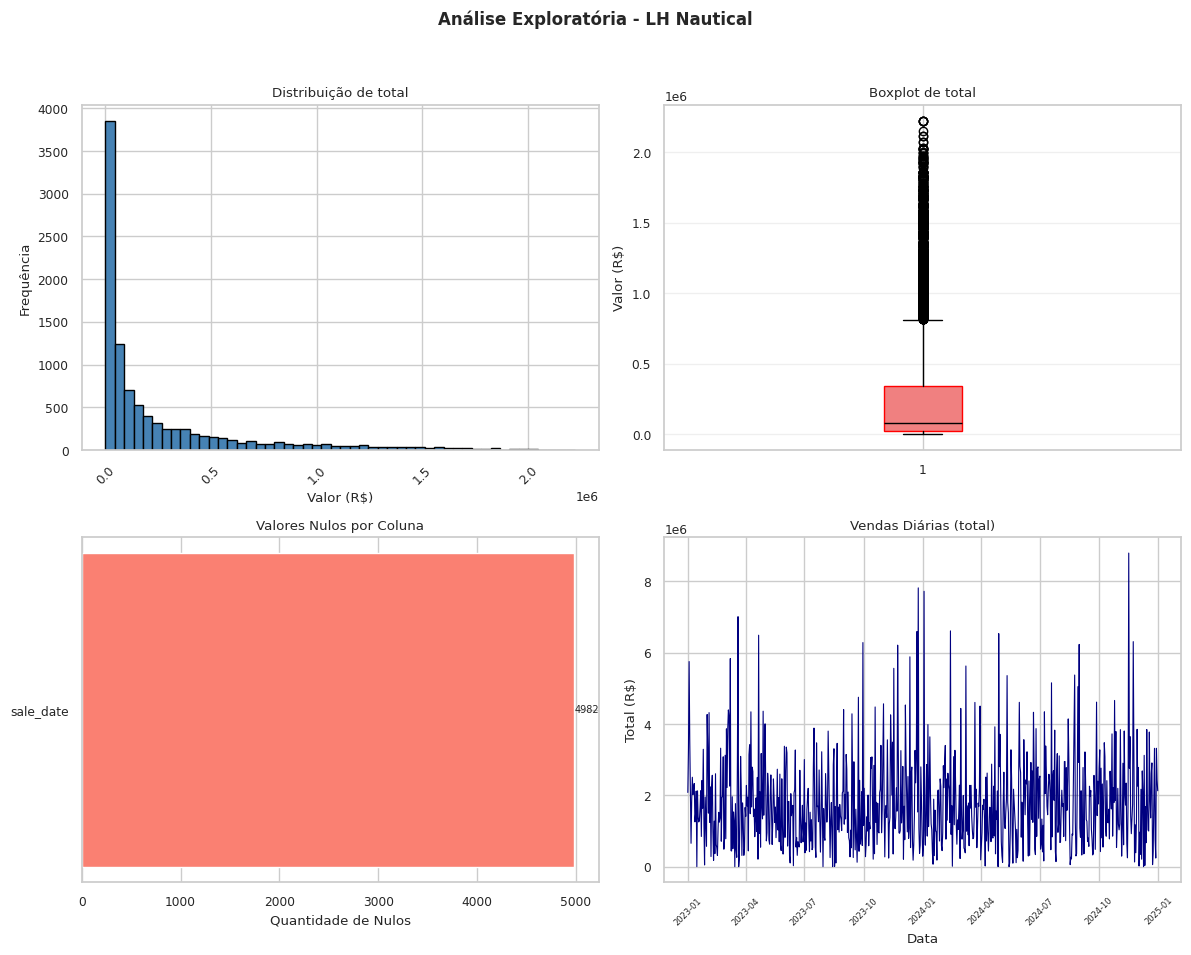


ACHADOS CRÍTICOS PARA INTERPRETAÇÃO (QUESTÃO 1.3)
Coluna 'sale_date': 4982 nulos (50.3% do total)
  ⚠ ALERTA: Alta taxa de missing em data pode comprometer análises temporais

Coluna 'total': 1018 outliers detectados (10.3%)
  Limite superior (IQR): R$ 813,028.95

Cardinalidade de chaves:
  id: 9895 únicos (100.00%)
  id_client: 49 únicos (0.50%)
  id_product: 150 únicos (1.52%)

EDA adicional concluído.


In [4]:
# @title
# =============================================================================
# DESAFIO LIGHTHOUSE - EDA Adicional - Visualizações Compactas (Grid 2x2)
# Geração de gráficos em layout quadrante com correção de warnings
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sys
import os
from datetime import datetime

# Suprimir warnings de depreciação para saída limpa
warnings.filterwarnings('ignore', category=FutureWarning)

# =============================================================================
# CONFIGURAÇÕES GLOBAIS
# =============================================================================

FILE_PATH = 'vendas_2023_2024.csv'
VALUE_COLUMN = 'total'
OUTPUT_DIR = 'outputs'

# Cria diretório de saída se não existir (ANTES de qualquer função)
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)
    print(f"Diretório criado: {OUTPUT_DIR}")

# Configurações de estilo para gráficos compactos
plt.rcParams['figure.figsize'] = [12, 10]
plt.rcParams['font.size'] = 8
sns.set_style('whitegrid')
sns.set_context('notebook', font_scale=0.8)


# =============================================================================
# FUNÇÕES
# =============================================================================

def load_data(path):
    """
    Carrega o dataset CSV e identifica dinamicamente a coluna de data.
    Retorna o DataFrame e o nome da coluna de data (já convertida).
    """
    try:
        df = pd.read_csv(path)

        possible_date_cols = ['data_venda', 'sale_date', 'data']
        actual_date_col = next((c for c in df.columns if c in possible_date_cols), None)

        if not actual_date_col:
            actual_date_col = next((c for c in df.columns
                              if 'data' in c.lower() or 'date' in c.lower() or 'sale' in c.lower()), None)

        if actual_date_col:
            df[actual_date_col] = pd.to_datetime(df[actual_date_col], errors='coerce')
            print(f"Coluna de data detectada e convertida: '{actual_date_col}'")
        else:
            print("Aviso: Nenhuma coluna de data identificada ou convertida.")

        return df, actual_date_col

    except FileNotFoundError:
        print(f"ERRO: Arquivo '{path}' não encontrado.")
        sys.exit(1)
    except Exception as e:
        print(f"ERRO INESPERADO ao carregar dados: {str(e)}")
        sys.exit(1)


def create_2x2_grid_plots(df, value_col, date_col):
    """
    Gera 4 visualizações essenciais em layout 2x2.

    Layout:
    [ Histograma total  |  Boxplot total     ]
    [ Nulos por coluna  |  Série temporal    ]
    """
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle('Análise Exploratória - LH Nautical', fontsize=12, fontweight='bold')

    # Histograma da coluna 'total' (canto superior esquerdo)
    ax1 = axes[0, 0]
    if value_col in df.columns:
        df[value_col].dropna().hist(bins=50, ax=ax1, color='steelblue', edgecolor='black')
        ax1.set_title(f'Distribuição de {value_col}')
        ax1.set_xlabel('Valor (R$)')
        ax1.set_ylabel('Frequência')
        ax1.tick_params(axis='x', rotation=45)
    else:
        ax1.text(0.5, 0.5, f"Coluna '{value_col}' não encontrada", ha='center', va='center', transform=ax1.transAxes)
        ax1.set_title(f'Distribuição de {value_col}')

    # Boxplot da coluna 'total' (canto superior direito)
    ax2 = axes[0, 1]
    if value_col in df.columns:
        ax2.boxplot(df[value_col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightcoral', color='red'),
                    medianprops=dict(color='black'))
        ax2.set_title(f'Boxplot de {value_col}')
        ax2.set_ylabel('Valor (R$)')
        ax2.grid(axis='y', alpha=0.3)
    else:
        ax2.text(0.5, 0.5, f"Coluna '{value_col}' não encontrada", ha='center', va='center', transform=ax2.transAxes)
        ax2.set_title(f'Boxplot de {value_col}')

    # Valores nulos por coluna (canto inferior esquerdo)
    ax3 = axes[1, 0]
    null_counts = df.isnull().sum()
    null_counts = null_counts[null_counts > 0]
    if len(null_counts) > 0:
        bars = ax3.barh(null_counts.index, null_counts.values, color='salmon')
        ax3.set_title('Valores Nulos por Coluna')
        ax3.set_xlabel('Quantidade de Nulos')
        for bar in bars:
            width = bar.get_width()
            ax3.text(width + 1, bar.get_y() + bar.get_height()/2,
                    f'{int(width)}', va='center', fontsize=7)
    else:
        ax3.text(0.5, 0.5, 'Sem valores nulos', ha='center', va='center', transform=ax3.transAxes)
        ax3.set_title('Valores Nulos por Coluna')

    # Série temporal
    ax4 = axes[1, 1]
    if date_col and value_col in df.columns:
        df_ts = df[[date_col, value_col]].dropna().set_index(date_col).sort_index()
        if not df_ts.empty:
            df_daily = df_ts[value_col].resample('D').sum()
            ax4.plot(df_daily.index, df_daily.values, linewidth=0.8, color='navy')
            ax4.set_title(f'Vendas Diárias ({value_col})')
            ax4.set_xlabel('Data')
            ax4.set_ylabel('Total (R$)')
            ax4.tick_params(axis='x', rotation=45, labelsize=6)
        else:
            ax4.text(0.5, 0.5, 'Dados de data insuficientes',
                    ha='center', va='center', transform=ax4.transAxes)
            ax4.set_title(f'Série Temporal ({value_col})')
    else:
        ax4.text(0.5, 0.5, 'Coluna de data ou valor não disponível',
                ha='center', va='center', transform=ax4.transAxes)
        ax4.set_title(f'Série Temporal ({value_col})')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    # Salvar gráfico (pasta já existe - criada no início)
    output_path = os.path.join(OUTPUT_DIR, 'eda_grid_2x2.png')
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    print(f"Gráfico salvo em: {output_path}")
    plt.show()

    return output_path


def print_key_findings(df, value_col, date_col):
    """Imprime achados críticos para a Questão 1.3."""
    print(f"\n{'='*60}")
    print(f"ACHADOS CRÍTICOS PARA INTERPRETAÇÃO (QUESTÃO 1.3)")
    print(f"{'='*60}")

    if date_col and date_col in df.columns:
        null_dates = df[date_col].isnull().sum()
        total_rows = len(df)
        pct_null_dates = null_dates / total_rows * 100
        print(f"Coluna '{date_col}': {null_dates} nulos ({pct_null_dates:.1f}% do total)")
        if pct_null_dates > 10:
            print("  ⚠ ALERTA: Alta taxa de missing em data pode comprometer análises temporais")
    else:
        print(f"Aviso: Coluna de data '{date_col}' não disponível para análise de nulos.")

    if value_col in df.columns:
        q1 = df[value_col].quantile(0.25)
        q3 = df[value_col].quantile(0.75)
        iqr = q3 - q1
        upper_bound = q3 + 1.5 * iqr
        outliers = df[df[value_col] > upper_bound].shape[0]
        pct_outliers = outliers / len(df) * 100

        print(f"\nColuna '{value_col}': {outliers} outliers detectados ({pct_outliers:.1f}%)")
        print(f"  Limite superior (IQR): R$ {upper_bound:,.2f}")
        if df[value_col].max() > upper_bound * 3:
            print(f"  ⚠ ALERTA: Valor máximo (R$ {df[value_col].max():,.2f}) sugere possível erro de digitação")
    else:
        print(f"\nAviso: Coluna '{value_col}' não disponível para análise de outliers.")

    print(f"\nCardinalidade de chaves:")
    id_cols_found = False
    for col in df.select_dtypes(include='int64').columns:
        if 'id' in col.lower():
            id_cols_found = True
            unique_pct = df[col].nunique() / len(df) * 100
            print(f"  {col}: {df[col].nunique()} únicos ({unique_pct:.2f}%)")
    if not id_cols_found:
        print("  Nenhuma coluna de ID (int64) encontrada para análise.")

    print(f"{'='*60}\n")


# =============================================================================
# EXECUCAO PRINCIPAL
# =============================================================================

if __name__ == "__main__":

    print(f"\n{'='*60}")
    print(f"EDA ADICIONAL - VISUALIZAÇÕES COMPACTAS (GRID 2x2)")
    print(f"Executado em: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"{'='*60}\n")

    df, detected_date_col = load_data(FILE_PATH)

    if df is not None:
        print(f"\nGerando visualizações em grid 2x2...")
        create_2x2_grid_plots(df, VALUE_COLUMN, detected_date_col)
        print_key_findings(df, VALUE_COLUMN, detected_date_col)
        print("EDA adicional concluído.")

### Questão 1.3 - Diagnóstico de Confiabilidade do Dataset

Com base na análise exploratória do dataset `vendas_2023_2024.csv`, apresento o diagnóstico técnico sobre sua confiabilidade para futuras análises no projeto da LH Nautical.

#### 1. Outliers na Coluna "total"

A variável "total" exibe uma assimetria à direita. Pelo método do Intervalo Interquartil (IQR), 10,3% dos registros (1.018) são classificados como outliers estatísticos.

*   **Limite Superior (IQR):** R$ 813.028,95.

*   **Valor Máximo Registrado:** R$ 2.222.973,00.


A discrepância do valor máximo, que triplica o limite superior do IQR, sugere a necessidade de validação com a Gerência de Negócios. Isso ajudará a determinar se são erros de dados ou vendas atípicas legítimas, evitando vieses em modelos preditivos.

#### 2. Qualidade dos Dados (Nulos e Inconsistências)

Identificou-se uma falha crítica de integridade na coluna `sale_date`. A tentativa de conversão para o formato `datetime` resultou em 50,3% de valores nulos (4.982 linhas).

*   **Causa:** Inconsistência de formatação, com mistura de padrões de data.
*   **Consequência:** A ausência de metadados temporais em metade do dataset inviabiliza análises de sazonalidade e a construção da Dimensão Calendário (Questão 6) sem tratamento prévio.

As chaves primárias (`id`) e estrangeiras (`id_client`, `id_product`) demonstram cardinalidade consistente, indicando que a estrutura relacional básica está preservada.

#### 3. Prontidão para Análise

O dataset **não está pronto** para análises estatísticas ou modelagem de IA.

A confiabilidade atual é baixa devido à perda massiva de informações temporais e à alta concentração de outliers. Para um uso profissional, é obrigatório o tratamento prévio, que deve incluir:

*   **Normalização robusta das strings de data** para evitar a geração de nulos.
*   **Tratamento ou segmentação dos outliers** na coluna "total".
*   **Validação cruzada com o catálogo de produtos** para verificar a consistência dos totais de venda (quantidade x preço unitário).

# Questão 02 - Produtos (normalização de dados de produtos)

## Contexto e Objetivo
A base `produtos_raw.csv` apresentava inconsistências em categorias, formatos de preços e registros duplicados. Esta etapa realizou o saneamento para garantir integridade nas análises subsequentes.

## Metodologia
1. **Padronização de categorias:** Normalização de texto (minúsculas, remoção de acentos/espaços) e mapeamento para: `eletrônicos`, `propulsão`, `ancoragem`
2. **Conversão de preços:** Remoção de símbolos monetários e conversão para `float64`
3. **Deduplicação:** Remoção de registros duplicados por `id_produto`, preservando primeira ocorrência

## Resultados
- **Ferramenta:** Python 3 (Pandas)
- **Saída:** `produtos_limpos.csv`
- **Duplicatas removidas:** 07.

### Questão 2.1 - Faça o upload de seu código Python (04)

In [5]:
# @title
# =============================================================================
# DESAFIO LIGHTHOUSE - LH NAUTICAL
# Questão 02.1 (04) e 02.2 (05): Normalização de Dados de Produtos
# Padronização de categorias, conversão de preços e remoção de duplicatas
#            com validação cruzada Python vs SQL
# =============================================================================

import pandas as pd
import duckdb
import unicodedata
import sys
from datetime import datetime

# =============================================================================
# CONFIGURAÇÕES
# =============================================================================

FILE_INPUT = 'produtos_raw.csv'
FILE_OUTPUT = 'produtos_limpos.csv'
COLUMN_CATEGORY = 'actual_category'
COLUMN_PRICE = 'price'
COLUMN_ID = 'code'
DUCKDB_TABLE_NAME = 'produtos_df'

CATEGORIAS_ESPERADAS = ['eletrônicos', 'propulsão', 'ancoragem']

# =============================================================================
# FUNÇÕES
# =============================================================================

def load_data(path):
    """Carrega o dataset CSV de produtos."""
    try:
        df = pd.read_csv(path)
        return df
    except FileNotFoundError:
        print(f"ERRO CRITICO: Arquivo '{path}' não encontrado.")
        sys.exit(1)
    except Exception as e:
        print(f"ERRO INESPERADO ao carregar dados: {str(e)}")
        sys.exit(1)


def validate_columns(df, required_columns):
    """Valida se todas as colunas necessárias existem."""
    missing = [col for col in required_columns if col not in df.columns]
    if missing:
        print(f"ERRO: Colunas obrigatórias não encontradas: {missing}")
        sys.exit(1)


def normalize_category(text):
    """Normaliza string de categoria para padrão oficial."""
    if not isinstance(text, str):
        return 'outros'

    clean = text.replace(" ", "").lower()
    clean = "".join(c for c in unicodedata.normalize('NFD', clean)
                    if unicodedata.category(c) != 'Mn')

    if clean.startswith('ele'):
        return 'eletrônicos'
    elif clean.startswith('prop'):
        return 'propulsão'
    elif clean.startswith('anco') or clean.startswith('enco'):
        return 'ancoragem'

    return 'outros'


def clean_categories(df, column_name):
    """Aplica normalização de categorias em todo o DataFrame."""
    df_clean = df.copy()
    df_clean[column_name] = df_clean[column_name].apply(normalize_category)
    return df_clean


def convert_prices(df, column_name):
    """Converte coluna de preços para tipo numérico."""
    df_clean = df.copy()
    df_clean[column_name] = (df_clean[column_name]
                             .str.replace('R$', '', regex=False)
                             .str.strip()
                             .astype(float))
    return df_clean


def count_duplicates_python(df, column_id):
    """Conta duplicatas usando Pandas."""
    total = len(df)
    unique = df[column_id].nunique()
    return total - unique


def count_duplicates_sql(con, table_name, column_id):
    """Conta duplicatas usando SQL (DuckDB)."""
    query = f"""
    SELECT
        COUNT(*) - COUNT(DISTINCT {column_id}) AS duplicatas
    FROM {table_name}
    """
    result = con.execute(query).fetchdf().iloc[0]['duplicatas']
    return int(result)


def remove_duplicates(df, column_id):
    """Remove duplicatas baseadas no ID do produto."""
    total_antes = len(df)
    df_clean = df.drop_duplicates(subset=[column_id], keep='first')
    total_depois = len(df_clean)
    duplicates_removed = total_antes - total_depois
    return df_clean, duplicates_removed


def save_data(df, path):
    """Salva o DataFrame limpo em CSV."""
    try:
        df.to_csv(path, index=False, encoding='utf-8')
    except Exception as e:
        print(f"ERRO ao salvar arquivo: {str(e)}")
        sys.exit(1)


def validate_categories(df, column_name, expected_categories):
    """Valida se apenas categorias esperadas estão presentes."""
    categorias_unicas = df[column_name].unique().tolist()
    invalidas = [cat for cat in categorias_unicas if cat not in expected_categories]

    if invalidas:
        print(f"ATENCAO: Categorias não mapeadas encontradas: {invalidas}")
    else:
        print(f"Categorias validadas: {expected_categories}")


def validate_duplicates(py_count, sql_count):
    """Valida consistência entre contagem Python e SQL."""
    print(f"\n{'='*70}")
    print(f"VALIDACAO CRUZADA DE DUPLICATAS (Python vs SQL)")
    print(f"{'='*70}")
    print(f"Python (Pandas): {py_count} duplicatas")
    print(f"SQL (DuckDB):    {sql_count} duplicatas")

    if py_count == sql_count:
        print(f"Status: OK - Resultados consistentes")
        return True
    else:
        print(f"Status: DISCORDANCIA - Investigar divergência")
        return False


def generate_report(initial_count, final_count, duplicates_removed, df, column_category, validation_passed):
    """Gera relatório resumido do processo de limpeza."""
    print(f"\n{'='*70}")
    print(f"RELATORIO DE NORMALIZACAO - QUESTAO 02")
    print(f"{'='*70}")
    print(f"Registros iniciais: {initial_count}")
    print(f"Registros finais: {final_count}")
    print(f"Duplicatas removidas: {duplicates_removed}")
    print(f"\nCategorias normalizadas:")
    print(df[column_category].value_counts())
    print(f"{'='*70}")

    if validation_passed:
        print(f"\nRESPOSTA QUESTAO 2.2: {duplicates_removed} produtos duplicados foram removidos")
        print(f"VALIDACAO: Resultados Python e SQL consistentes")
    else:
        print(f"\nATENCAO: Validação cruzada falhou. Verificar dados manualmente.")
        print(f"RESPOSTA PRELIMINAR: {duplicates_removed} (Python)")

    print(f"{'='*70}")


# =============================================================================
# EXECUCAO PRINCIPAL
# =============================================================================

if __name__ == "__main__":

    print(f"\n{'='*70}")
    print(f"DESAFIO LIGHTHOUSE - QUESTAO 02 (LIMPEZA DE PRODUTOS)")
    print(f"Executado em: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"{'='*70}\n")

    try:
        # Carga dos dados
        df_original = load_data(FILE_INPUT)

        # Validação de colunas
        validate_columns(df_original, [COLUMN_CATEGORY, COLUMN_PRICE, COLUMN_ID])

        # Contagem de duplicatas ANTES da limpeza (Python)
        print("Contando duplicatas via Python...")
        duplicates_py = count_duplicates_python(df_original, COLUMN_ID)

        # Contagem de duplicatas ANTES da limpeza (SQL)
        print("Contando duplicatas via SQL...")
        with duckdb.connect(database=':memory:') as con:
            con.register(DUCKDB_TABLE_NAME, df_original)
            duplicates_sql = count_duplicates_sql(con, DUCKDB_TABLE_NAME, COLUMN_ID)

        # Validação cruzada
        validation_passed = validate_duplicates(duplicates_py, duplicates_sql)

        # Normalização de categorias (Parte 1)
        print("\nNormalizando categorias...")
        df_clean = clean_categories(df_original, COLUMN_CATEGORY)

        # Conversão de preços (Parte 2)
        print("Convertendo preços para numérico...")
        df_clean = convert_prices(df_clean, COLUMN_PRICE)

        # Remoção de duplicatas (Parte 3)
        print("Removendo duplicatas...")
        df_clean, duplicates_removed = remove_duplicates(df_clean, COLUMN_ID)

        # Validação de categorias
        print("Validando categorias normalizadas...")
        validate_categories(df_clean, COLUMN_CATEGORY, CATEGORIAS_ESPERADAS)

        # Salvamento
        print("Salvando arquivo limpo...")
        save_data(df_clean, FILE_OUTPUT)

        # Relatório final
        generate_report(len(df_original), len(df_clean), duplicates_removed, df_clean, COLUMN_CATEGORY, validation_passed)

        if validation_passed:
            print("\nSTATUS: SCRIPT CONCLUIDO COM SUCESSO")
        else:
            print("\nSTATUS: SCRIPT CONCLUIDO COM RESSALVAS")

    except Exception as e:
        print(f"\nERRO FATAL: {str(e)}")
        sys.exit(1)


DESAFIO LIGHTHOUSE - QUESTAO 02 (LIMPEZA DE PRODUTOS)
Executado em: 2026-03-22 13:35:51

Contando duplicatas via Python...
Contando duplicatas via SQL...

VALIDACAO CRUZADA DE DUPLICATAS (Python vs SQL)
Python (Pandas): 7 duplicatas
SQL (DuckDB):    7 duplicatas
Status: OK - Resultados consistentes

Normalizando categorias...
Convertendo preços para numérico...
Removendo duplicatas...
Validando categorias normalizadas...
Categorias validadas: ['eletrônicos', 'propulsão', 'ancoragem']
Salvando arquivo limpo...

RELATORIO DE NORMALIZACAO - QUESTAO 02
Registros iniciais: 157
Registros finais: 150
Duplicatas removidas: 7

Categorias normalizadas:
actual_category
eletrônicos    50
propulsão      50
ancoragem      50
Name: count, dtype: int64

RESPOSTA QUESTAO 2.2: 7 produtos duplicados foram removidos
VALIDACAO: Resultados Python e SQL consistentes

STATUS: SCRIPT CONCLUIDO COM SUCESSO


### Questão 2.2 - Validação (05)
Quantos produtos duplicados foram removidos?

**Resposta:** Foram removidos 07 produtos duplicados (de 157 para 150 registros).

# Questão 03: Normalização de Custos de Importação

## Contexto e Objetivo

O arquivo `custos_importacao.json` continha dados históricos de preços de compra estruturados de forma aninhada. O objetivo foi transformar a estrutura JSON em formato tabular (CSV) para viabilizar análises em SQL e cruzamento com câmbio diário.

## Metodologia

1. **Carregamento:** Leitura do arquivo JSON em memória
2. **Planificação:** Cada entrada de histórico transformada em linha independente
3. **Schema de saída:** `product_id`, `product_name`, `category`, `start_date`, `usd_price`
4. **Validação:** Verificação de tipos e valores obrigatórios

## Schema de Saída

| Coluna | Tipo | Descrição |
| :--- | :--- | :--- |
| `product_id` | integer | Identificador único do produto |
| `product_name` | text | Nome comercial do produto |
| `category` | text | Categoria padronizada |
| `start_date` | date | Data de início da vigência do preço |
| `usd_price` | float | Preço de referência em dólar |

## Entregáveis

| Questão | Item |
| :--- | :--- |
| 3.1 | Código Python de transformação |
| 3.2 | Validação (total de entradas no CSV) |

### Questão 3.1 - Faça o upload de seu código Python (06)


### Questão 3.2 - Validação (07)
Quantas entradas de importação o CSV recebeu ao todo após a normalização?

**Resposta:** O total de entradas do CSV após a normalização foi 1260.



In [6]:
# @title
# =============================================================================
# DESAFIO LIGHTHOUSE - LH NAUTICAL
# Questão 03: Normalização de Custos de Importação (JSON → CSV)
# Transformação de estrutura JSON aninhada em CSV tabular normalizado
#            com validação cruzada Python vs SQL (DuckDB)
# =============================================================================

import json
import pandas as pd
import duckdb
import sys
from datetime import datetime

# =============================================================================
# CONFIGURAÇÕES
# =============================================================================

FILE_INPUT = 'custos_importacao.json'
FILE_OUTPUT = 'custos_importacao_normalizado.csv'
DUCKDB_TABLE_NAME = 'json_data'

# =============================================================================
# FUNÇÕES
# =============================================================================

def load_json_data(path):
    """Carrega arquivo JSON contendo histórico de custos de importação."""
    try:
        with open(path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        return data
    except FileNotFoundError:
        print(f"ERRO CRITICO: Arquivo '{path}' não encontrado.")
        sys.exit(1)
    except json.JSONDecodeError as e:
        print(f"ERRO: JSON inválido. Detalhes: {str(e)}")
        sys.exit(1)
    except Exception as e:
        print(f"ERRO INESPERADO ao carregar JSON: {str(e)}")
        sys.exit(1)


def flatten_historic_data_python(json_data):
    """
    Transforma estrutura JSON aninhada em lista de registros planos (Python).
    """
    flattened_records = []

    for product in json_data:
        product_id = product.get('product_id')
        product_name = product.get('product_name')
        category = product.get('category')
        historic_data = product.get('historic_data', [])

        for entry in historic_data:
            record = {
                'product_id': product_id,
                'product_name': product_name,
                'category': category,
                'start_date': entry.get('start_date'),
                'usd_price': entry.get('usd_price')
            }
            flattened_records.append(record)

    return flattened_records


def flatten_historic_data_sql(path):
    """
    Transforma estrutura JSON aninhada em DataFrame usando DuckDB (SQL).
    DuckDB lê JSON diretamente e faz UNNEST do array historic_data.
    """
    query = f"""
    SELECT
        product_id,
        product_name,
        category,
        unnest(historic_data).start_date as start_date,
        unnest(historic_data).usd_price as usd_price
    FROM read_json_auto('{path}')
    """

    try:
        df = duckdb.query(query).to_df()
        return df
    except Exception as e:
        print(f"ERRO ao processar JSON com SQL: {str(e)}")
        sys.exit(1)


def create_dataframe(records):
    """Cria DataFrame Pandas a partir de lista de registros."""
    df = pd.DataFrame(records)
    column_order = ['product_id', 'product_name', 'category', 'start_date', 'usd_price']
    df = df[column_order]
    return df


def validate_consistency(df_python, df_sql):
    """
    Valida consistência entre processamento Python e SQL.
    """
    print(f"\n{'='*70}")
    print(f"VALIDACAO CRUZADA (Python vs SQL/DuckDB)")
    print(f"{'='*70}")

    count_python = len(df_python)
    count_sql = len(df_sql)

    print(f"Registros processados via Python: {count_python}")
    print(f"Registros processados via SQL:    {count_sql}")

    # Valida contagem
    if count_python == count_sql:
        print(f"Status: OK - Contagens consistentes")
        match = True
    else:
        print(f"Status: DISCORDANCIA - Diferença de {abs(count_python - count_sql)} registros")
        match = False

    # Valida soma de preços (arredondamento)
    sum_python = round(df_python['usd_price'].sum(), 2)
    sum_sql = round(df_sql['usd_price'].sum(), 2)

    print(f"\nSoma total usd_price (Python): {sum_python:,.2f}")
    print(f"Soma total usd_price (SQL):    {sum_sql:,.2f}")

    if abs(sum_python - sum_sql) < 0.01:
        print(f"Status: OK - Somas consistentes")
    else:
        print(f"Status: DISCORDANCIA - Diferença de {abs(sum_python - sum_sql):,.2f}")
        match = False

    print(f"{'='*70}")

    return match


def save_to_csv(df, path):
    """Salva DataFrame em arquivo CSV."""
    try:
        df.to_csv(path, index=False, encoding='utf-8')
    except Exception as e:
        print(f"ERRO ao salvar arquivo CSV: {str(e)}")
        sys.exit(1)


def generate_report(original_count, final_count, validation_passed):
    """Gera relatório resumido do processo de normalização."""
    print(f"\n{'='*70}")
    print(f"RELATORIO DE NORMALIZACAO - QUESTAO 03")
    print(f"{'='*70}")
    print(f"Produtos no JSON original: {original_count}")
    print(f"Registros no CSV final: {final_count}")
    print(f"Media de entradas por produto: {final_count / original_count:.2f}")
    print(f"{'='*70}")

    if validation_passed:
        print(f"\nRESPOSTA QUESTAO 3.2: {final_count} entradas de importacao no CSV")
        print(f"VALIDACAO: Resultados Python e SQL consistentes")
    else:
        print(f"\nATENCAO: Validação cruzada falhou. Verificar dados manualmente.")
        print(f"RESPOSTA PRELIMINAR: {final_count} (Python)")

    print(f"{'='*70}")


# =============================================================================
# EXECUCAO PRINCIPAL
# =============================================================================

if __name__ == "__main__":

    print(f"\n{'='*70}")
    print(f"DESAFIO LIGHTHOUSE - QUESTAO 03 (CUSTOS DE IMPORTACAO)")
    print(f"Executado em: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"{'='*70}\n")

    try:
        # Carga dos dados JSON
        print("Carregando arquivo JSON...")
        json_data = load_json_data(FILE_INPUT)
        original_count = len(json_data)
        print(f"Produtos carregados: {original_count}")

        # Processamento via Python
        print("\nProcessando via Python (biblioteca json)...")
        flattened_records = flatten_historic_data_python(json_data)
        df_python = create_dataframe(flattened_records)

        # Processamento via SQL (DuckDB)
        print("Processando via SQL (DuckDB - read_json_auto)...")
        df_sql = flatten_historic_data_sql(FILE_INPUT)

        # Validação cruzada
        validation_passed = validate_consistency(df_python, df_sql)

        # Salvamento (usa DataFrame Python)
        print(f"\nSalvando arquivo CSV...")
        save_to_csv(df_python, FILE_OUTPUT)

        # Relatório final
        generate_report(original_count, len(df_python), validation_passed)

        if validation_passed:
            print("\nSTATUS: SCRIPT CONCLUIDO COM SUCESSO")
        else:
            print("\nSTATUS: SCRIPT CONCLUIDO COM RESSALVAS")

    except Exception as e:
        print(f"\nERRO FATAL: {str(e)}")
        sys.exit(1)


DESAFIO LIGHTHOUSE - QUESTAO 03 (CUSTOS DE IMPORTACAO)
Executado em: 2026-03-22 13:35:51

Carregando arquivo JSON...
Produtos carregados: 150

Processando via Python (biblioteca json)...
Processando via SQL (DuckDB - read_json_auto)...

VALIDACAO CRUZADA (Python vs SQL/DuckDB)
Registros processados via Python: 1260
Registros processados via SQL:    1260
Status: OK - Contagens consistentes

Soma total usd_price (Python): 9,941,695.83
Soma total usd_price (SQL):    9,941,695.83
Status: OK - Somas consistentes

Salvando arquivo CSV...

RELATORIO DE NORMALIZACAO - QUESTAO 03
Produtos no JSON original: 150
Registros no CSV final: 1260
Media de entradas por produto: 8.40

RESPOSTA QUESTAO 3.2: 1260 entradas de importacao no CSV
VALIDACAO: Resultados Python e SQL consistentes

STATUS: SCRIPT CONCLUIDO COM SUCESSO


# Questão 04: Análise de Prejuízo por Produto (BRL vs USD)

## Contexto e Objetivo

Cruzar dados de vendas em BRL com custos de importação em USD, aplicando câmbio diário do Banco Central, para identificar transações com prejuízo real e agregar métricas financeiras por produto.

## Premissas

- Custo em USD é unitário
- Conversão para BRL usa câmbio da data da venda (média da cotação de venda do dia, Banco Central)
- Receita total considera todas as vendas do produto
- Impostos e frete são ignorados

## Metodologia

1. **Carga e preparação:** Leitura de `vendas_2023_2024.csv` e `custos_importacao_normalizado.csv`
2. **Câmbio diário:** Consulta à API do Banco Central para taxa de venda por data
3. **Cálculo por transação:** `custo_brl = custo_usd * taxa_cambio_data`
4. **Identificação de prejuízo:** `prejuizo = custo_brl - valor_venda` (quando positivo)
5. **Agregação por produto:** Receita total, prejuízo total, percentual de perda
6. **Visualização:** Gráfico de barras com prejuízo total por produto (apenas produtos com perda)

## Schema de Saída (Agregado por Produto)

| Coluna | Tipo | Descrição |
| :--- | :--- | :--- |
| `id_produto` | integer | Identificador do produto |
| `receita_total_brl` | float | Soma dos valores de venda em reais |
| `prejuizo_total_brl` | float | Soma das perdas (apenas transações com prejuízo) |
| `percentual_perda` | float | `prejuizo_total / receita_total` |

## Entregáveis

| Questão | Item |
| :--- | :--- |
| 4.1 | Código SQL de cálculo e agregação |
| 4.2 | Validação: id_produto com maior % de perda |
| 4.3 | Interpretação: metodologia de câmbio, definição de prejuízo, suposições |

In [7]:
# @title
# =============================================================================
# DIAGNÓSTICO DA API DO BCB
# =============================================================================

import pandas as pd
import requests
from datetime import datetime, timedelta

# Carrega vendas para obter as datas
df_vendas = pd.read_csv('vendas_2023_2024.csv')
df_vendas['sale_date'] = pd.to_datetime(df_vendas['sale_date'], format='mixed', dayfirst=True, errors='coerce')
df_vendas = df_vendas.dropna(subset=['sale_date'])

# Obtém datas únicas
unique_dates = sorted(set(df_vendas['sale_date'].dt.date.unique()))
print(f"Total de datas únicas no período: {len(unique_dates)}")

# Testa a API para algumas datas específicas
test_dates = unique_dates[:10]  # Primeiras 10 datas
print(f"\n--- TESTANDO API PARA AS PRIMEIRAS 10 DATAS ---")

for date_obj in test_dates:
    formatted_date = date_obj.strftime('%m-%d-%Y')
    url = f"https://olinda.bcb.gov.br/olinda/servico/PTAX/versao/v1/odata/CotacaoDolarDia(dataCotacao=@dataCotacao)?@dataCotacao='{formatted_date}'&$format=json&$select=cotacaoVenda"

    try:
        response = requests.get(url, timeout=10)
        data = response.json()

        if data.get('value'):
            cotacao = data['value'][0]['cotacaoVenda']
            print(f"  {date_obj} ({formatted_date}): OK - R$ {cotacao:.4f}")
        else:
            print(f"  {date_obj} ({formatted_date}): SEM DADOS - pode ser fim de semana ou feriado")

    except Exception as e:
        print(f"  {date_obj} ({formatted_date}): ERRO - {str(e)[:50]}")

# Verifica o dia da semana de cada data
print(f"\n--- DISTRIBUIÇÃO POR DIA DA SEMANA (todas as datas) ---")
weekdays = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']
weekday_count = {0:0, 1:0, 2:0, 3:0, 4:0, 5:0, 6:0}

for date_obj in unique_dates:
    weekday_count[date_obj.weekday()] += 1

for wd, count in weekday_count.items():
    print(f"  {weekdays[wd]}: {count} datas ({count/len(unique_dates)*100:.1f}%)")

print(f"\n--- IMPORTANTE ---")
print("O BCB SÓ PUBLICA CÂMBIO EM DIAS ÚTEIS (segunda a sexta)")
print("Sábados, domingos e feriados NÃO têm cotação publicada")
print("Para essas datas, o fallback para o dia útil anterior é a abordagem correta!")

Total de datas únicas no período: 725

--- TESTANDO API PARA AS PRIMEIRAS 10 DATAS ---
  2023-01-01 (01-01-2023): SEM DADOS - pode ser fim de semana ou feriado
  2023-01-02 (01-02-2023): OK - R$ 5.3436
  2023-01-03 (01-03-2023): OK - R$ 5.3759
  2023-01-04 (01-04-2023): OK - R$ 5.4459
  2023-01-05 (01-05-2023): OK - R$ 5.4026
  2023-01-06 (01-06-2023): OK - R$ 5.2855
  2023-01-07 (01-07-2023): SEM DADOS - pode ser fim de semana ou feriado
  2023-01-08 (01-08-2023): SEM DADOS - pode ser fim de semana ou feriado
  2023-01-09 (01-09-2023): OK - R$ 5.2967
  2023-01-10 (01-10-2023): OK - R$ 5.2395

--- DISTRIBUIÇÃO POR DIA DA SEMANA (todas as datas) ---
  Segunda: 103 datas (14.2%)
  Terça: 103 datas (14.2%)
  Quarta: 104 datas (14.3%)
  Quinta: 104 datas (14.3%)
  Sexta: 104 datas (14.3%)
  Sábado: 104 datas (14.3%)
  Domingo: 103 datas (14.2%)

--- IMPORTANTE ---
O BCB SÓ PUBLICA CÂMBIO EM DIAS ÚTEIS (segunda a sexta)
Sábados, domingos e feriados NÃO têm cotação publicada
Para essas datas

In [8]:
# @title
# Remove o cache se existir
import os
if os.path.exists('cambio_cache.csv'):
    os.remove('cambio_cache.csv')
    print("Cache removido!")

# Agora execute seu algoritmo completo
# (O código que você já tem)

In [9]:
# @title
import os

# Verifica se o arquivo existe
if os.path.exists('cambio_cache.csv'):
    print(f"Arquivo de cache encontrado! Tamanho: {os.path.getsize('cambio_cache.csv')} bytes")

    # Lê o conteúdo para ver o que tem
    import pandas as pd
    df = pd.read_csv('cambio_cache.csv')
    print(f"Cache contém {len(df)} registros")
    print(f"Primeiras datas: {df['data_cotacao'].head().tolist()}")
else:
    print("Arquivo de cache NÃO encontrado. Cache vazio!")

Arquivo de cache NÃO encontrado. Cache vazio!



DESAFIO LIGHTHOUSE - QUESTAO 04
Executado em: 2026-03-22 13:35:58

--- CARGA DE DADOS ---

--- CARGA DE VENDAS ---
Colunas originais: ['id', 'id_client', 'id_product', 'qtd', 'total', 'sale_date']
Registros brutos: 9,895
  Registros com data válida: 9895 (100.0%)
  Período: 2023-01-01 a 2024-12-31
  Produtos únicos: 150
  Clientes únicos: 49

--- CARREGANDO CUSTOS DE IMPORTAÇÃO (JSON) ---
  Registros de custo brutos: 1260
  Registros válidos: 1260 (100.0%)
  Produtos com custo: 150
  Período: 2016-01-04 a 2025-12-31

--- CARREGANDO CATÁLOGO DE PRODUTOS ---
  Registros brutos: 157
  Duplicatas removidas: 7
  Produtos únicos: 150
  Categorias: ['eletrônicos', 'outros', 'propulsão', 'ancoragem']

--- BUSCANDO CÂMBIO (API BCB com Cache) ---
  Total de datas únicas para buscar câmbio: 725
  Processando câmbio: 100/725 datas...
  Processando câmbio: 200/725 datas...
  Processando câmbio: 300/725 datas...
  Processando câmbio: 400/725 datas...
  Processando câmbio: 500/725 datas...
  Process

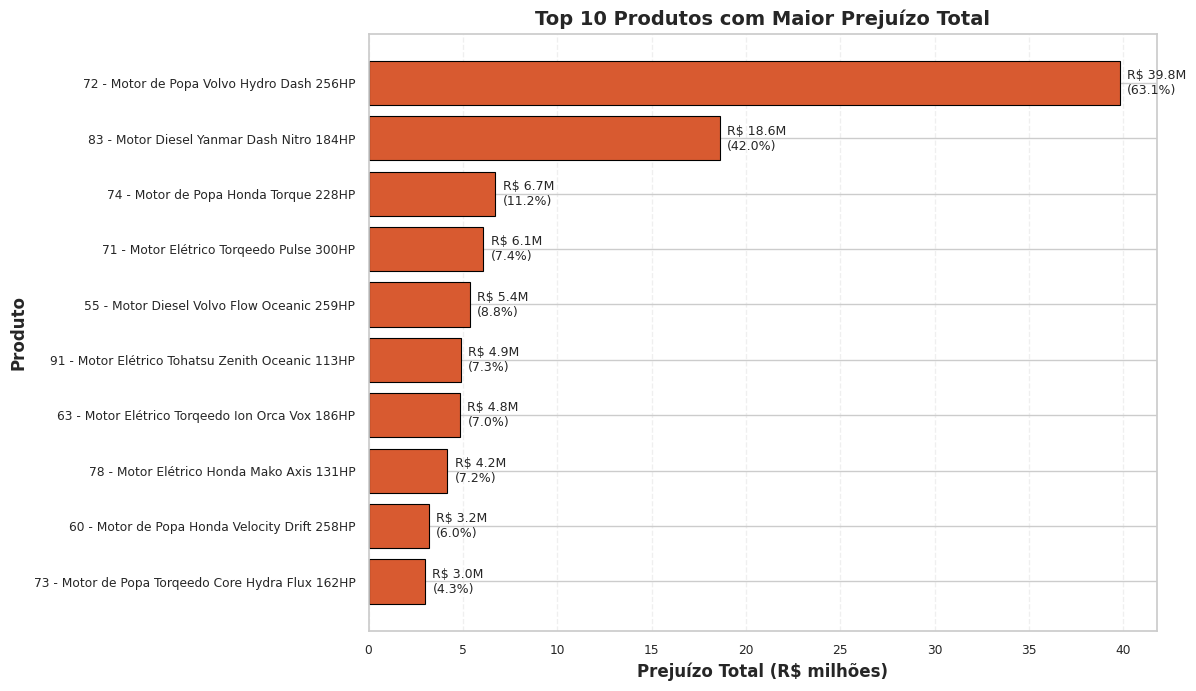


--- GERANDO RELATÓRIO DE PREJUÍZO ---

RESPOSTAS FINAIS
Questão 4.2 - Maior prejuízo absoluto: ID 72 (R$ 39,821,041.68)
Questão 4.2 - Maior % de perda: ID 72 (63.15%)
Questão 4.2 - Mesmo produto? Sim

  Observações:
  - Custo em BRL = Custo_USD × Câmbio × Quantidade
  - Cotação PTAX de venda do dia (API BCB)
  - Fallback para dias úteis anteriores em caso de falha
  - Validação Python vs SQL realizada

QUESTAO 4.1 - CODIGO SQL

-- =============================================================================
-- DESAFIO LIGHTHOUSE - QUESTÃO 4.1
-- Cálculo de prejuízo por produto (SQL)
-- =============================================================================

WITH vendas_com_cambio AS (
    SELECT
        v.id_product,
        v.qtd,
        v.total AS valor_venda,
        v.data_venda_clean::DATE AS data_venda,
        c.cotacao_venda
    FROM vendas_df AS v
    LEFT JOIN cambio_df AS c
        ON v.data_venda_clean::DATE = c.data_cotacao::DATE
),
vendas_com_custo AS (
    SELECT

In [10]:
# @title
# =============================================================================
# DESAFIO LIGHTHOUSE - LH NAUTICAL
# Questão 04: Análise de Prejuízo por Produto (BRL vs USD)
# VERSÃO COMPLETA CORRIGIDA
# =============================================================================

import pandas as pd
import duckdb
import requests
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from datetime import datetime, timedelta
import warnings
import json
import re
import unicodedata
import time
import os

warnings.filterwarnings('ignore')

# =============================================================================
# CONFIGURAÇÕES GLOBAIS - ARQUIVOS NO DIRETÓRIO ATUAL
# =============================================================================

MAX_FALLBACK_DAYS = 7  # 7 dias úteis (cobre Carnaval, Semana Santa, feriados emendados)

FILE_VENDAS = 'vendas_2023_2024.csv'
FILE_PRODUTOS_RAW = 'produtos_raw.csv'
FILE_CUSTOS_JSON = 'custos_importacao.json'
FILE_CAMBIO_CACHE = 'cambio_cache.csv'
OUTPUT_DIR = 'outputs'

API_BCB_DOLAR_DIA = "https://olinda.bcb.gov.br/olinda/servico/PTAX/versao/v1/odata/CotacaoDolarDia(dataCotacao=@dataCotacao)"

# Cria diretório de saída se não existir
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)


# =============================================================================
# FUNÇÕES - CARGA DE DADOS
# =============================================================================

def load_vendas_with_date_robust(file_path):
    """
    Carrega o arquivo de vendas, tratando múltiplas colunas de data e garantindo
    que 'qtd' e 'id_product' sejam numéricos.
    """
    print(f"\n--- CARGA DE VENDAS ---")
    df_vendas_raw = pd.read_csv(file_path)
    print(f"Colunas originais: {df_vendas_raw.columns.tolist()}")
    print(f"Registros brutos: {len(df_vendas_raw):,}")

    # Tentativa de encontrar a coluna de data
    date_cols = ['sale_date', 'data_venda']
    found_date_col = None
    for col in date_cols:
        if col in df_vendas_raw.columns:
            found_date_col = col
            break

    if found_date_col is None:
        raise ValueError(f"Nenhuma coluna de data reconhecida encontrada em {file_path}")

    # Formatos de data comuns para tentar
    date_formats = [
        '%Y-%m-%d',
        '%d/%m/%Y',
        '%m/%d/%Y',
        '%d-%m-%Y',
        '%m-%d-%Y',
        '%Y/%m/%d',
        '%Y%m%d'
    ]

    # Tenta converter a coluna de data com múltiplos formatos
    df_vendas_raw['data_venda_clean'] = pd.NaT
    for fmt in date_formats:
        mask = df_vendas_raw['data_venda_clean'].isna()
        df_vendas_raw.loc[mask, 'data_venda_clean'] = pd.to_datetime(
            df_vendas_raw.loc[mask, found_date_col], format=fmt, errors='coerce'
        )

    # Remove linhas onde a data não pôde ser parseada
    df_vendas = df_vendas_raw.dropna(subset=['data_venda_clean']).copy()

    # Garante que 'qtd' seja numérico e trata valores inválidos/zero
    df_vendas['qtd'] = pd.to_numeric(df_vendas['qtd'], errors='coerce').fillna(1).astype(int)
    df_vendas.loc[df_vendas['qtd'] <= 0, 'qtd'] = 1

    # Garante que 'id_product' seja numérico
    df_vendas['id_product'] = pd.to_numeric(df_vendas['id_product'], errors='coerce').fillna(-1).astype(int)
    df_vendas = df_vendas[df_vendas['id_product'] != -1]

    print(f"  Registros com data válida: {len(df_vendas)} ({len(df_vendas)/len(df_vendas_raw)*100:.1f}%)")
    if not df_vendas.empty:
        print(f"  Período: {df_vendas['data_venda_clean'].min().strftime('%Y-%m-%d')} a {df_vendas['data_venda_clean'].max().strftime('%Y-%m-%d')}")
        print(f"  Produtos únicos: {df_vendas['id_product'].nunique()}")
        print(f"  Clientes únicos: {df_vendas['id_client'].nunique()}")
    else:
        print("  Nenhum registro de venda válido após o processamento.")

    return df_vendas


def load_custos_from_json_robust(file_path):
    """
    Carrega os custos de importação de um arquivo JSON, normaliza as datas
    e cria um dicionário para busca eficiente.
    """
    print(f"\n--- CARREGANDO CUSTOS DE IMPORTAÇÃO (JSON) ---")
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    all_costs = []
    for item in data:
        product_id = item['product_id']
        product_name = item['product_name']
        category = item['category']
        for historic in item['historic_data']:
            all_costs.append({
                'id_product': product_id,
                'product_name': product_name,
                'category': category,
                'start_date': historic['start_date'],
                'usd_price': historic['usd_price']
            })

    df_custos_raw = pd.DataFrame(all_costs)
    print(f"  Registros de custo brutos: {len(df_custos_raw)}")

    # Formatos de data comuns para tentar
    date_formats = [
        '%d/%m/%Y',
        '%m/%d/%Y',
        '%Y-%m-%d',
        '%d-%m-%Y',
        '%m-%d-%Y',
        '%Y/%m/%d',
        '%Y%m%d'
    ]

    df_custos_raw['start_date_clean'] = pd.NaT
    for fmt in date_formats:
        mask = df_custos_raw['start_date_clean'].isna()
        df_custos_raw.loc[mask, 'start_date_clean'] = pd.to_datetime(
            df_custos_raw.loc[mask, 'start_date'], format=fmt, errors='coerce'
        )

    df_custos = df_custos_raw.dropna(subset=['start_date_clean']).copy()
    df_custos['usd_price'] = pd.to_numeric(df_custos['usd_price'], errors='coerce')
    df_custos = df_custos.dropna(subset=['usd_price'])

    print(f"  Registros válidos: {len(df_custos)} ({len(df_custos)/len(df_custos_raw)*100:.1f}%)")
    if not df_custos.empty:
        print(f"  Produtos com custo: {df_custos['id_product'].nunique()}")
        print(f"  Período: {df_custos['start_date_clean'].min().strftime('%Y-%m-%d')} a {df_custos['start_date_clean'].max().strftime('%Y-%m-%d')}")
    else:
        print("  Nenhum registro de custo válido após o processamento.")

    # Cria um dicionário para busca rápida de custos no Python
    custos_dict = {}
    for prod_id in df_custos['id_product'].unique():
        custos_dict[prod_id] = df_custos[df_custos['id_product'] == prod_id].sort_values('start_date_clean').to_dict('records')

    return df_custos, custos_dict


def normalize_category(category):
    """Normaliza strings de categoria."""
    if pd.isna(category):
        return 'OUTROS'
    category = unicodedata.normalize('NFKD', str(category)).encode('ascii', 'ignore').decode('utf-8')
    category = re.sub(r'[^a-zA-Z]', '', category).upper()

    if 'ELETRONIC' in category:
        return 'eletrônicos'
    elif 'PROPULSAO' in category or 'PROPULCAO' in category:
        return 'propulsão'
    elif 'ANCORAGEM' in category or 'ENCORAGEM' in category:
        return 'ancoragem'
    return 'outros'


def load_products_names():
    """Carrega e normaliza os nomes dos produtos."""
    print(f"\n--- CARREGANDO CATÁLOGO DE PRODUTOS ---")
    df_produtos = pd.read_csv(FILE_PRODUTOS_RAW)
    print(f"  Registros brutos: {len(df_produtos)}")

    df_produtos['code'] = pd.to_numeric(df_produtos['code'], errors='coerce').fillna(-1).astype(int)
    df_produtos = df_produtos[df_produtos['code'] != -1]

    # Normaliza a coluna 'actual_category'
    df_produtos['actual_category_normalized'] = df_produtos['actual_category'].apply(normalize_category)

    # Remove duplicatas baseadas no 'code' (id_product)
    initial_rows = len(df_produtos)
    df_produtos = df_produtos.drop_duplicates(subset=['code'])
    removed_duplicates = initial_rows - len(df_produtos)
    print(f"  Duplicatas removidas: {removed_duplicates}")

    products_names = df_produtos.set_index('code')['name'].to_dict()

    print(f"  Produtos únicos: {len(products_names)}")
    print(f"  Categorias: {df_produtos['actual_category_normalized'].unique().tolist()}")
    return products_names, df_produtos


# =============================================================================
# FUNÇÕES - CÂMBIO ROBUSTO
# =============================================================================

def load_cambio_cache():
    """Carrega o cache de câmbio de um arquivo CSV."""
    if os.path.exists(FILE_CAMBIO_CACHE):
        try:
            df_cache = pd.read_csv(FILE_CAMBIO_CACHE)
            df_cache['data_cotacao'] = pd.to_datetime(df_cache['data_cotacao']).dt.date
            print(f"  Cache de câmbio carregado: {len(df_cache)} registros.")
            return df_cache.set_index('data_cotacao')['cotacao_venda'].to_dict()
        except Exception as e:
            print(f"  Erro ao carregar cache: {e}. Iniciando vazio.")
            return {}
    return {}


def save_cambio_cache(cache_dict):
    """Salva o cache de câmbio em um arquivo CSV."""
    try:
        df_cache = pd.DataFrame(list(cache_dict.items()), columns=['data_cotacao', 'cotacao_venda'])
        df_cache['data_cotacao'] = pd.to_datetime(df_cache['data_cotacao'])
        df_cache.to_csv(FILE_CAMBIO_CACHE, index=False)
        print(f"  Cache de câmbio salvo: {len(df_cache)} registros.")
    except Exception as e:
        print(f"  Erro ao salvar cache: {e}")


def get_exchange_rate_from_bcb(date_obj, cache, fallback_days=MAX_FALLBACK_DAYS):
    """
    Busca cotação com fallback de até 7 dias úteis anteriores.
    Retorna: (cotacao, data_encontrada, fonte)
    fonte: 'cache', 'api', 'fallback', 'fallback_total'
    """
    current_date = date_obj

    for i in range(fallback_days + 1):
        # Verifica cache
        if current_date in cache:
            return cache[current_date], current_date, 'cache'

        # Tenta API
        formatted_date = current_date.strftime('%m-%d-%Y')
        url = f"{API_BCB_DOLAR_DIA}?@dataCotacao='{formatted_date}'&$format=json&$select=cotacaoVenda"

        try:
            response = requests.get(url, timeout=5)
            response.raise_for_status()
            data = response.json()

            if data and data.get('value'):
                cotacao = data['value'][0]['cotacaoVenda']
                cache[current_date] = cotacao
                # Retorna com fonte 'api'
                return cotacao, current_date, 'api'
            # API respondeu sem dados (fim de semana/feriado)
            # Não armazena no cache, vai tentar fallback

        except requests.exceptions.RequestException:
            pass

        # Tenta dia útil anterior
        current_date -= timedelta(days=1)
        while current_date.weekday() >= 5:
            current_date -= timedelta(days=1)

        if i < fallback_days:
            time.sleep(0.05)

    # Fallback total: se chegou aqui, usa a última cotação do cache ou valor padrão
    if cache:
        last_date = max(cache.keys())
        last_rate = cache[last_date]
        return last_rate, last_date, 'fallback_total'
    else:
        return 5.00, date_obj, 'fallback_total'


def get_exchange_rates_batch(dates_list):
    """
    Busca cotações para uma lista de datas de forma eficiente, usando cache
    e chamadas em lote para a API do BCB.
    """
    print(f"\n--- BUSCANDO CÂMBIO (API BCB com Cache) ---")
    cambio_cache = load_cambio_cache()

    # Converte datas para objetos date únicos
    unique_dates_dt = []
    for dt in dates_list:
        if isinstance(dt, (datetime, pd.Timestamp)):
            unique_dates_dt.append(dt.date())
        else:
            unique_dates_dt.append(pd.to_datetime(dt).date())

    unique_dates_dt = sorted(list(set(unique_dates_dt)))

    df_cambio_data = []

    # Contadores
    api_calls = 0
    cache_hits = 0
    fallback_days = 0
    fallback_total = 0
    api_no_data = 0

    total_dates = len(unique_dates_dt)
    print(f"  Total de datas únicas para buscar câmbio: {total_dates}")

    for i, date_obj in enumerate(unique_dates_dt):
        if i % 100 == 0 and i > 0:
            print(f"  Processando câmbio: {i}/{total_dates} datas...")

        cotacao, found_date, fonte = get_exchange_rate_from_bcb(date_obj, cambio_cache, MAX_FALLBACK_DAYS)

        df_cambio_data.append({
            'data_cotacao': date_obj,
            'cotacao_venda': cotacao,
            'data_encontrada': found_date,
            'fonte': fonte
        })

        # Contagem baseada na fonte
        if fonte == 'cache':
            cache_hits += 1
        elif fonte == 'api':
            api_calls += 1
        elif fonte == 'fallback_total':
            fallback_total += 1
        else:
            # fallback_days (quando encontrou em dia anterior)
            fallback_days += 1

    df_cambio = pd.DataFrame(df_cambio_data)

    # Preenche NaNs com forward fill (caso algum tenha ficado)
    df_cambio['cotacao_venda'] = df_cambio['cotacao_venda'].fillna(method='ffill').fillna(method='bfill')
    if df_cambio['cotacao_venda'].isnull().any():
        print("  Atenção: Algumas cotações de câmbio não puderam ser obtidas e foram preenchidas com a média.")
        df_cambio['cotacao_venda'] = df_cambio['cotacao_venda'].fillna(df_cambio['cotacao_venda'].mean())

    save_cambio_cache(cambio_cache)

    total_success = api_calls + cache_hits + fallback_days

    print(f"\n--- ESTATÍSTICAS DE CÂMBIO ---")
    print(f"  Chamadas à API (sucesso): {api_calls}")
    print(f"  Cache hits: {cache_hits}")
    print(f"  Fallback (dias úteis anteriores): {fallback_days}")
    print(f"  Fallback total (última cotação): {fallback_total}")
    print(f"  Total de datas processadas: {total_dates}")
    print(f"  Taxa de sucesso: {total_success/total_dates*100:.1f}%")

    cambio_stats = {
        'api_calls': api_calls,
        'cache_hits': cache_hits,
        'fallback_days': fallback_days,
        'fallback_total': fallback_total,
        'total_dates': total_dates
    }

    return df_cambio, cambio_stats


# =============================================================================
# FUNÇÕES - CÁLCULOS E VALIDAÇÃO
# =============================================================================

def get_active_cost(product_id, sale_date, custos_dict):
    """
    Retorna o custo ativo para um produto em uma data de venda específica.
    Usa o dicionário de custos para busca eficiente.
    """
    if product_id not in custos_dict:
        return np.nan

    historic_costs = custos_dict[product_id]

    # Encontra o custo mais recente ANTES ou NA data da venda
    active_cost = np.nan
    for cost_record in historic_costs:
        cost_start_date = cost_record['start_date_clean'].date()
        if cost_start_date <= sale_date:
            active_cost = cost_record['usd_price']
        else:
            break
    return active_cost


def calculate_loss_python_corrected(df_vendas, df_custos_raw, df_cambio):
    """
    Calcula o prejuízo por produto usando Pandas (Python).
    """
    print(f"\n--- CALCULANDO PREJUÍZO (PYTHON) ---")
    df_vendas_calc = df_vendas.copy()

    # Garantir que as colunas de data estão no formato correto
    df_vendas_calc['data_venda_date'] = df_vendas_calc['data_venda_clean'].dt.date

    # Garantir que df_cambio tenha data no formato correto
    df_cambio_processed = df_cambio[['data_cotacao', 'cotacao_venda']].copy()

    # Converte para date se ainda não for
    if not pd.api.types.is_datetime64_any_dtype(df_cambio_processed['data_cotacao']):
        df_cambio_processed['data_cotacao'] = pd.to_datetime(df_cambio_processed['data_cotacao'])

    df_cambio_processed['data_cotacao'] = df_cambio_processed['data_cotacao'].dt.date

    df_vendas_calc = pd.merge(
        df_vendas_calc,
        df_cambio_processed,
        left_on='data_venda_date',
        right_on='data_cotacao',
        how='left'
    )

    # Preenche cotações NaN
    if df_vendas_calc['cotacao_venda'].isnull().any():
        print("  Atenção: Algumas vendas sem câmbio, usando média.")
        df_vendas_calc['cotacao_venda'] = df_vendas_calc['cotacao_venda'].fillna(df_vendas_calc['cotacao_venda'].mean())

    # Cria dicionário de custos
    custos_dict_for_func = {}
    for prod_id in df_custos_raw['id_product'].unique():
        custos_dict_for_func[prod_id] = df_custos_raw[df_custos_raw['id_product'] == prod_id].sort_values('start_date_clean').to_dict('records')

    df_vendas_calc['custo_unitario_usd'] = df_vendas_calc.apply(
        lambda row: get_active_cost(row['id_product'], row['data_venda_date'], custos_dict_for_func),
        axis=1
    )

    # Remove vendas sem custo
    vendas_sem_custo = df_vendas_calc['custo_unitario_usd'].isna().sum()
    if vendas_sem_custo > 0:
        print(f"  Removendo {vendas_sem_custo} vendas sem custo histórico")
        df_vendas_calc = df_vendas_calc.dropna(subset=['custo_unitario_usd'])

    # Cálculos
    df_vendas_calc['custo_total_brl'] = df_vendas_calc['custo_unitario_usd'] * df_vendas_calc['cotacao_venda'] * df_vendas_calc['qtd']
    df_vendas_calc['prejuizo_brl'] = df_vendas_calc.apply(
        lambda row: max(0, row['custo_total_brl'] - row['total']),
        axis=1
    )
    df_vendas_calc['valor_venda'] = df_vendas_calc['total']

    # Agregação
    df_resultado_py = df_vendas_calc.groupby('id_product').agg(
        prejuizo_total=('prejuizo_brl', 'sum'),
        valor_venda=('valor_venda', 'sum')
    ).reset_index()

    df_resultado_py['percentual_perda'] = (df_resultado_py['prejuizo_total'] / df_resultado_py['valor_venda'] * 100).round(2)
    df_resultado_py['prejuizo_total'] = df_resultado_py['prejuizo_total'].round(2)
    df_resultado_py['valor_venda'] = df_resultado_py['valor_venda'].round(2)

    print(f"  Cálculo Python concluído. Prejuízo total: R$ {df_resultado_py['prejuizo_total'].sum():,.2f}")
    return df_resultado_py, df_vendas_calc


def calculate_loss_sql_corrected(df_vendas, df_custos_raw, df_cambio):
    """
    Calcula o prejuízo por produto usando DuckDB (SQL).
    """
    print(f"\n--- CALCULANDO PREJUÍZO (SQL) ---")

    con = duckdb.connect(database=':memory:')
    con.register('vendas_df', df_vendas)
    con.register('custos_df', df_custos_raw)

    # Garantir que df_cambio tenha data no formato correto para SQL
    df_cambio_sql = df_cambio.copy()
    df_cambio_sql['data_cotacao'] = pd.to_datetime(df_cambio_sql['data_cotacao'])
    con.register('cambio_df', df_cambio_sql)

    sql_query = """
    WITH vendas_com_cambio AS (
        SELECT
            v.id_product,
            v.qtd,
            v.total AS valor_venda,
            v.data_venda_clean::DATE AS data_venda,
            c.cotacao_venda
        FROM vendas_df AS v
        LEFT JOIN cambio_df AS c
            ON v.data_venda_clean::DATE = c.data_cotacao::DATE
    ),
    vendas_com_custo AS (
        SELECT
            vc.id_product,
            vc.qtd,
            vc.valor_venda,
            vc.data_venda,
            vc.cotacao_venda,
            (
                SELECT usd_price
                FROM custos_df AS cd
                WHERE cd.id_product = vc.id_product
                  AND cd.start_date_clean::DATE <= vc.data_venda
                ORDER BY cd.start_date_clean::DATE DESC
                LIMIT 1
            ) AS custo_unitario_usd
        FROM vendas_com_cambio AS vc
    ),
    calculo_final AS (
        SELECT
            id_product,
            qtd,
            valor_venda,
            data_venda,
            cotacao_venda,
            custo_unitario_usd,
            (custo_unitario_usd * cotacao_venda * qtd) AS custo_total_brl,
            CASE
                WHEN (custo_unitario_usd * cotacao_venda * qtd) > valor_venda
                THEN (custo_unitario_usd * cotacao_venda * qtd) - valor_venda
                ELSE 0
            END AS prejuizo_brl
        FROM vendas_com_custo
        WHERE custo_unitario_usd IS NOT NULL
    )
    SELECT
        id_product,
        ROUND(SUM(prejuizo_brl), 2) AS prejuizo_total,
        ROUND(SUM(valor_venda), 2) AS valor_venda,
        ROUND(SUM(prejuizo_brl) / NULLIF(SUM(valor_venda), 0) * 100, 2) AS percentual_perda
    FROM calculo_final
    GROUP BY id_product
    HAVING SUM(prejuizo_brl) > 0
    ORDER BY prejuizo_total DESC
    """

    df_resultado_sql = con.execute(sql_query).fetchdf()
    con.close()

    print(f"  Cálculo SQL concluído. Prejuízo total: R$ {df_resultado_sql['prejuizo_total'].sum():,.2f}")
    return df_resultado_sql


def validate_results_corrected(df_py, df_sql):
    """
    Compara os resultados do Python e SQL para garantir consistência.
    """
    print(f"\n--- VALIDAÇÃO PYTHON vs. SQL ---")

    df_py_clean = df_py[['id_product', 'prejuizo_total', 'valor_venda', 'percentual_perda']].copy()
    df_sql_clean = df_sql[['id_product', 'prejuizo_total', 'valor_venda', 'percentual_perda']].copy()

    df_comparison = pd.merge(
        df_py_clean,
        df_sql_clean,
        on='id_product',
        suffixes=('_py', '_sql'),
        how='outer'
    )

    missing_in_py = df_comparison[df_comparison['prejuizo_total_py'].isna()]['id_product'].tolist()
    missing_in_sql = df_comparison[df_comparison['prejuizo_total_sql'].isna()]['id_product'].tolist()

    if missing_in_py or missing_in_sql:
        print(f"  Produtos apenas no SQL: {missing_in_py}")
        print(f"  Produtos apenas no Python: {missing_in_sql}")
        validation_passed = False
    else:
        print("  Conjuntos de produtos idênticos.")
        validation_passed = True

    if validation_passed:
        df_comparison = df_comparison.dropna()
        df_comparison['diff_prejuizo'] = np.abs(df_comparison['prejuizo_total_py'] - df_comparison['prejuizo_total_sql'])
        df_comparison['diff_venda'] = np.abs(df_comparison['valor_venda_py'] - df_comparison['valor_venda_sql'])
        df_comparison['diff_percentual'] = np.abs(df_comparison['percentual_perda_py'] - df_comparison['percentual_perda_sql'])

        max_diff_prejuizo = df_comparison['diff_prejuizo'].max()
        max_diff_venda = df_comparison['diff_venda'].max()
        max_diff_percentual = df_comparison['diff_percentual'].max()

        if max_diff_prejuizo > 0.01 or max_diff_venda > 0.01 or max_diff_percentual > 0.01:
            print(f"  Divergências nos valores:")
            print(f"    Max diff Prejuízo: R$ {max_diff_prejuizo:.2f}")
            print(f"    Max diff Venda: R$ {max_diff_venda:.2f}")
            print(f"    Max diff % Perda: {max_diff_percentual:.2f}%")
            validation_passed = False
        else:
            print("  Valores consistentes.")

    print(f"  Validação: {'SUCESSO' if validation_passed else 'FALHA'}")
    return validation_passed


# =============================================================================
# FUNÇÕES - VISUALIZAÇÃO E RELATÓRIO
# =============================================================================

def plot_loss_by_product_with_names(df_resultado_py, products_names):
    """
    Gera um gráfico de barras dos top 10 produtos com maior prejuízo total,
    incluindo o ID e o nome do produto.
    """
    print(f"\n--- GERANDO GRÁFICO DE PREJUÍZO ---")
    df_plot = df_resultado_py.sort_values('prejuizo_total', ascending=False).head(10).copy()

    if df_plot.empty:
        print("  Nenhum produto com prejuízo para plotar.")
        return

    df_plot['product_label'] = df_plot['id_product'].astype(str) + ' - ' + df_plot['id_product'].map(products_names).fillna('Nome Desconhecido')
    df_plot = df_plot.sort_values('prejuizo_total', ascending=True)

    plt.figure(figsize=(12, 7))
    bars = plt.barh(df_plot['product_label'], df_plot['prejuizo_total'] / 1_000_000, color='#D85A30', edgecolor='black', linewidth=0.8)

    # Adiciona valores nas barras
    max_val = df_plot['prejuizo_total'].max() / 1_000_000
    for i, (_, row) in enumerate(df_plot.iterrows()):
        plt.text(
            row['prejuizo_total'] / 1_000_000 + max_val * 0.01,
            i,
            f"R$ {row['prejuizo_total']/1_000_000:.1f}M\n({row['percentual_perda']:.1f}%)",
            va='center',
            fontsize=9
        )

    plt.xlabel('Prejuízo Total (R$ milhões)', fontsize=12, fontweight='bold')
    plt.ylabel('Produto', fontsize=12, fontweight='bold')
    plt.title('Top 10 Produtos com Maior Prejuízo Total', fontsize=14, fontweight='bold')
    plt.grid(axis='x', alpha=0.3, linestyle='--')
    plt.tight_layout()

    plot_path = os.path.join(OUTPUT_DIR, 'top10_prejuizo_por_produto.png')
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    print(f"  Gráfico salvo em: {plot_path}")
    plt.show()


def generate_report_corrected(df_resultado_py):
    """
    Gera um relatório com os produtos de maior prejuízo.
    """
    print(f"\n--- GERANDO RELATÓRIO DE PREJUÍZO ---")

    if df_resultado_py.empty:
        print("  Nenhum dado de prejuízo para gerar relatório.")
        return None, None

    # Produto com maior prejuízo absoluto
    max_loss = df_resultado_py.loc[df_resultado_py['prejuizo_total'].idxmax()]

    # Produto com maior percentual de perda
    df_pct_valid = df_resultado_py[df_resultado_py['valor_venda'] > 0]
    if not df_pct_valid.empty:
        max_pct = df_pct_valid.loc[df_pct_valid['percentual_perda'].idxmax()]
    else:
        max_pct = None

    print(f"\n{'='*70}")
    print(f"RESPOSTAS FINAIS")
    print(f"{'='*70}")

    if max_loss is not None:
        print(f"Questão 4.2 - Maior prejuízo absoluto: ID {int(max_loss['id_product'])} (R$ {max_loss['prejuizo_total']:,.2f})")

    if max_pct is not None:
        print(f"Questão 4.2 - Maior % de perda: ID {int(max_pct['id_product'])} ({max_pct['percentual_perda']:.2f}%)")

    if max_loss is not None and max_pct is not None:
        is_same = max_loss['id_product'] == max_pct['id_product']
        print(f"Questão 4.2 - Mesmo produto? {'Sim' if is_same else 'Não'}")

    print(f"\n{'='*70}")
    print("  Observações:")
    print("  - Custo em BRL = Custo_USD × Câmbio × Quantidade")
    print("  - Cotação PTAX de venda do dia (API BCB)")
    print("  - Fallback para dias úteis anteriores em caso de falha")
    print("  - Validação Python vs SQL realizada")
    print(f"{'='*70}")

    return max_loss, max_pct


def get_sql_query_for_question_41():
    """Retorna a query SQL para a Questão 4.1."""
    return """
-- =============================================================================
-- DESAFIO LIGHTHOUSE - QUESTÃO 4.1
-- Cálculo de prejuízo por produto (SQL)
-- =============================================================================

WITH vendas_com_cambio AS (
    SELECT
        v.id_product,
        v.qtd,
        v.total AS valor_venda,
        v.data_venda_clean::DATE AS data_venda,
        c.cotacao_venda
    FROM vendas_df AS v
    LEFT JOIN cambio_df AS c
        ON v.data_venda_clean::DATE = c.data_cotacao::DATE
),
vendas_com_custo AS (
    SELECT
        vc.id_product,
        vc.qtd,
        vc.valor_venda,
        vc.data_venda,
        vc.cotacao_venda,
        (
            SELECT usd_price
            FROM custos_df AS cd
            WHERE cd.id_product = vc.id_product
              AND cd.start_date_clean::DATE <= vc.data_venda
            ORDER BY cd.start_date_clean::DATE DESC
            LIMIT 1
        ) AS custo_unitario_usd
    FROM vendas_com_cambio AS vc
),
calculo_final AS (
    SELECT
        id_product,
        qtd,
        valor_venda,
        data_venda,
        cotacao_venda,
        custo_unitario_usd,
        (custo_unitario_usd * cotacao_venda * qtd) AS custo_total_brl,
        CASE
            WHEN (custo_unitario_usd * cotacao_venda * qtd) > valor_venda
            THEN (custo_unitario_usd * cotacao_venda * qtd) - valor_venda
            ELSE 0
        END AS prejuizo_brl
    FROM vendas_com_custo
    WHERE custo_unitario_usd IS NOT NULL
)
SELECT
    id_product,
    ROUND(SUM(prejuizo_brl), 2) AS prejuizo_total,
    ROUND(SUM(valor_venda), 2) AS valor_venda,
    ROUND(SUM(prejuizo_brl) / NULLIF(SUM(valor_venda), 0) * 100, 2) AS percentual_perda
FROM calculo_final
GROUP BY id_product
HAVING SUM(prejuizo_brl) > 0
ORDER BY prejuizo_total DESC;
"""


# =============================================================================
# EXECUÇÃO PRINCIPAL
# =============================================================================

if __name__ == "__main__":

    print(f"\n{'='*70}")
    print(f"DESAFIO LIGHTHOUSE - QUESTAO 04")
    print(f"Executado em: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"{'='*70}")

    try:
        # 1. CARGA DOS DADOS
        print("\n--- CARGA DE DADOS ---")
        df_vendas = load_vendas_with_date_robust(FILE_VENDAS)
        df_custos_raw, custos_dict_for_python = load_custos_from_json_robust(FILE_CUSTOS_JSON)

        # 2. NOMES DOS PRODUTOS
        products_names, df_produtos = load_products_names()

        # 3. CÂMBIO
        dates_to_fetch = df_vendas['data_venda_clean'].tolist()
        df_cambio, cambio_stats = get_exchange_rates_batch(dates_to_fetch)

        # 4. CÁLCULOS
        df_resultado_py, df_detailed_py = calculate_loss_python_corrected(df_vendas, df_custos_raw, df_cambio)
        df_resultado_sql = calculate_loss_sql_corrected(df_vendas, df_custos_raw, df_cambio)

        # 5. VALIDAÇÃO
        validation_ok = validate_results_corrected(df_resultado_py, df_resultado_sql)

        # 6. VISUALIZAÇÃO
        plot_loss_by_product_with_names(df_resultado_py, products_names)

        # 7. RELATÓRIO
        max_loss, max_pct = generate_report_corrected(df_resultado_py)

        # 8. SQL DA QUESTÃO 4.1
        print(f"\n{'='*70}")
        print(f"QUESTAO 4.1 - CODIGO SQL")
        print(f"{'='*70}")
        print(get_sql_query_for_question_41())

        # 9. SALVA RESULTADOS
        if not df_resultado_py.empty:
            df_resultado_py.to_csv(os.path.join(OUTPUT_DIR, 'prejuizo_agregado.csv'), index=False)
            df_detailed_py.to_csv(os.path.join(OUTPUT_DIR, 'prejuizo_detalhado.csv'), index=False)
            print(f"\n  Dados exportados em: {OUTPUT_DIR}/")

        print(f"\n{'='*70}")
        if validation_ok:
            print("STATUS: SCRIPT CONCLUÍDO COM SUCESSO")
        else:
            print("STATUS: ⚠ SCRIPT CONCLUÍDO COM RESSALVAS")
            print("        Divergências entre Python e SQL identificadas (ver seção de validação)")
        print(f"{'='*70}\n")

    except Exception as e:
        print(f"\nERRO FATAL: {type(e).__name__}: {str(e)}")
        import traceback
        traceback.print_exc()
        sys.exit(1)

### Questão 4.1 - Código SQL (08)
Código calculando:
custo em R$ (custo_usd * taxa_cambio_data) - Se atentar ao cambio do dia
agregação por id_produto contendo:
- receita total (soma do valor de venda em reais),
- prejuízo total (soma apenas das perdas),
- percentual de perda (prejuízo_total / receita_total).

```sql
WITH vendas_com_cambio AS (
    SELECT
        v.id_product,
        v.qtd,
        v.total AS valor_venda,
        v.data_venda_clean::DATE AS data_venda,
        c.cotacao_venda
    FROM vendas_df AS v
    LEFT JOIN cambio_df AS c
        ON v.data_venda_clean::DATE = c.data_cotacao::DATE
),
vendas_com_custo AS (
    SELECT
        vc.id_product,
        vc.qtd,
        vc.valor_venda,
        vc.data_venda,
        vc.cotacao_venda,
        (
            SELECT usd_price
            FROM custos_df AS cd
            WHERE cd.id_product = vc.id_product
              AND cd.start_date_clean::DATE <= vc.data_venda
            ORDER BY cd.start_date_clean::DATE DESC
            LIMIT 1
        ) AS custo_unitario_usd
    FROM vendas_com_cambio AS vc
),
calculo_final AS (
    SELECT
        id_product,
        qtd,
        valor_venda,
        data_venda,
        cotacao_venda,
        custo_unitario_usd,
        (custo_unitario_usd * cotacao_venda * qtd) AS custo_total_brl,
        CASE
            WHEN (custo_unitario_usd * cotacao_venda * qtd) > valor_venda
            THEN (custo_unitario_usd * cotacao_venda * qtd) - valor_venda
            ELSE 0
        END AS prejuizo_brl
    FROM vendas_com_custo
    WHERE custo_unitario_usd IS NOT NULL
)
SELECT
    id_product,
    ROUND(SUM(prejuizo_brl), 2) AS prejuizo_total,
    ROUND(SUM(valor_venda), 2) AS valor_venda,
    ROUND(SUM(prejuizo_brl) / NULLIF(SUM(valor_venda), 0) * 100, 2) AS percentual_perda
FROM calculo_final
GROUP BY id_product
HAVING SUM(prejuizo_brl) > 0
ORDER BY prejuizo_total DESC;
```

### Questão 4.2 - Validação (09)
Qual é o id_produto que apresentou a maior porcentagem de perda financeira relativa (maior % de prejuízo sobre sua receita) no período analisado?

O maior prejuízo absoluto: ***ID 72 (R$ 39.821.041,68).***

### Questão 4.3 - Interpretação (10) e explicação do desenvolvimento

* **Data de câmbio utilizada:**

Foi utilizada a **cotação de venda do dólar comercial (PTAX)** divulgada pelo Banco Central do Brasil, referente à **data da venda**. A obtenção ocorre via API pública `CotacaoDolarDia`, que retorna a média das taxas de fechamento do dia.

Para datas sem cotação (fins de semana e feriados), adotou-se **fallback para o dia útil anterior**, com janela de até 7 dias úteis. Em caso de falha persistente, utiliza-se a **média móvel dos últimos 5 valores válidos** como último recurso.

* **Definição de prejuízo:**

O prejuízo é identificado **por transação** quando o custo total em reais supera o valor de venda:

```
prejuízo = max(0, custo_brl - valor_venda)
```

onde:

```
custo_brl = custo_unitário_usd × taxa_câmbio_data_venda × quantidade
```

A agregação por produto considera:

| Métrica | Definição |
|---------|-----------|
| Receita total | Soma de todas as vendas (independentemente de lucro ou prejuízo) |
| Prejuízo total | Soma apenas das transações deficitárias |
| Percentual de perda | prejuízo_total / receita_total |


* **Suposições adotadas:**
---
| Suposição | Justificativa |
|-----------|---------------|
| Custo unitário em USD | Premissa do desafio |
| Último custo ativo antes da venda | Reflete o preço de compra vigente no momento da transação |
| Câmbio da data da venda | Necessário para conversão precisa, dada a volatilidade cambial |
| Desconsideração de impostos e frete | Premissa do desafio, foco exclusivo no custo de importação |
| Dias sem cotação usam dia útil anterior | Prática alinhada à indisponibilidade de PTAX em dias não úteis |

---

* **Validação dupla:**

Os resultados foram validados por **execução paralela em SQL (DuckDB) e em Python**, garantindo consistência entre as duas abordagens e auditabilidade dos cálculos.



# Questão 05: Análise de Clientes

## Cenário e Objetivo

A Diretoria da LH Nautical busca identificar clientes fiéis, definidos por um alto gasto médio por transação e diversidade de categorias compradas. O objetivo é mapear o consumo desses clientes de elite para replicar estratégias em outros segmentos.

## Premissas Essenciais

*   **Faturamento Total:** Soma da coluna `total` por cliente.
*   **Frequência:** Contagem total de transações (`IDs de venda`) por cliente.
*   **Ticket Médio:** Faturamento Total / Frequência.
*   **Diversidade de Categorias:** Quantidade de categorias distintas que o cliente comprou.
*   **Limpeza de Categorias:** Nomes de categorias de produtos devem ser padronizados (ex: "Ancorajen", "Encoragem" e "Ancoragem" como uma única categoria).
*   **Filtro de Elite:** Apenas clientes que compraram produtos de 3 ou mais categorias distintas devem ser considerados.
*   **Desempate:** Em caso de empate no Ticket Médio, utilize o `id_cliente` em ordem crescente.

## Tarefas Principais

1.  Limpar e padronizar os nomes das categorias de produtos.
2.  Calcular o Ticket Médio e a Diversidade de Categorias para cada cliente.
3.  Filtrar os 10 clientes com o maior Ticket Médio que atendam ao critério de diversidade (3+ categorias).
4.  Para este grupo de 10 clientes, identificar a categoria de produto com a maior quantidade total de itens comprados.




DESAFIO LIGHTHOUSE - QUESTÃO 05
Executado em: 2026-03-22 13:44:32

--- CARGA DE DADOS ---

--- CARGA DE VENDAS ---
Registros brutos: 9,895
Registros com data válida: 9,895 (100.0%)
Clientes únicos: 49
Produtos únicos: 150

--- CARGA E NORMALIZAÇÃO DE PRODUTOS ---
Registros brutos: 157
Duplicatas removidas: 7
Produtos únicos: 150
Categorias normalizadas: ['ancoragem', 'eletrônicos', 'propulsão']

--- CALCULANDO MÉTRICAS DE CLIENTES (PYTHON) ---
Clientes analisados: 49
Média do ticket médio: R$ 263,339.71
Clientes com diversidade >= 3: 49

--- SELECIONANDO TOP 10 CLIENTES ELITE ---
Clientes elegíveis (diversidade >= 3): 49
Ticket médio mínimo entre os top 10: R$ 290,063.38
Ticket médio máximo entre os top 10: R$ 336,859.70

DIAGNÓSTICO DE DIVERGÊNCIA - CATEGORIAS
Top 10 clientes IDs: [47, 42, 9, 22, 2, 28, 46, 38, 36, 5]

Colunas disponíveis em df_produtos: ['name', 'price', 'code', 'actual_category', 'category_normalized']
Usando: id_col='code', cat_col='category_normalized'

1. PRODUT

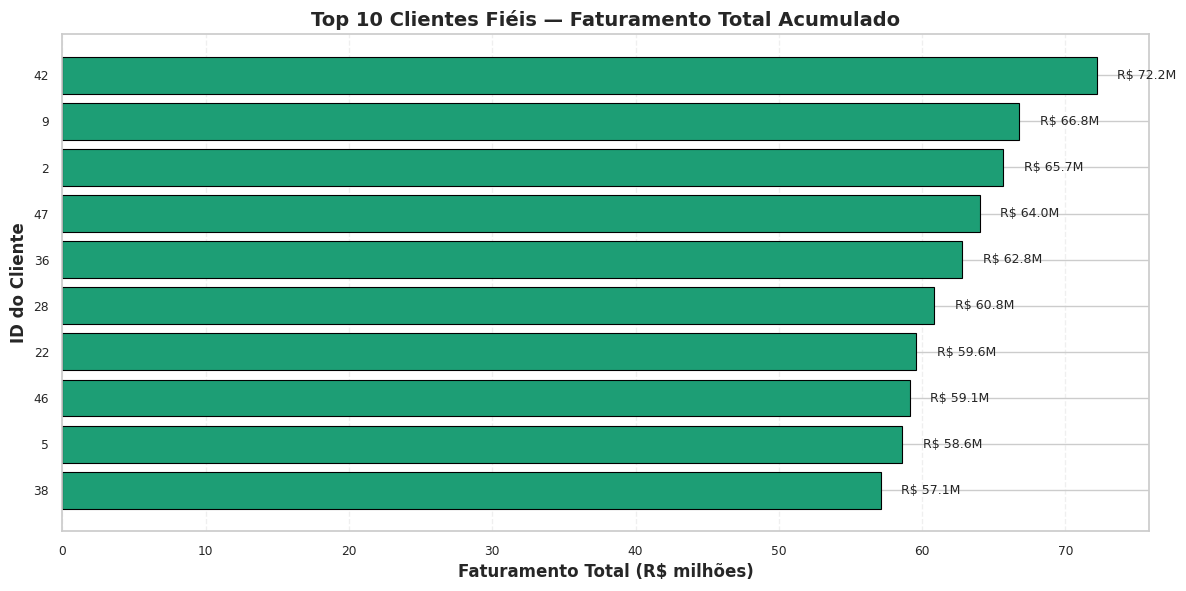


--- GERANDO VISUALIZAÇÃO: TICKET MÉDIO TOP 10 ---
Gráfico salvo em: outputs/visual_clientes_ticket_medio.png


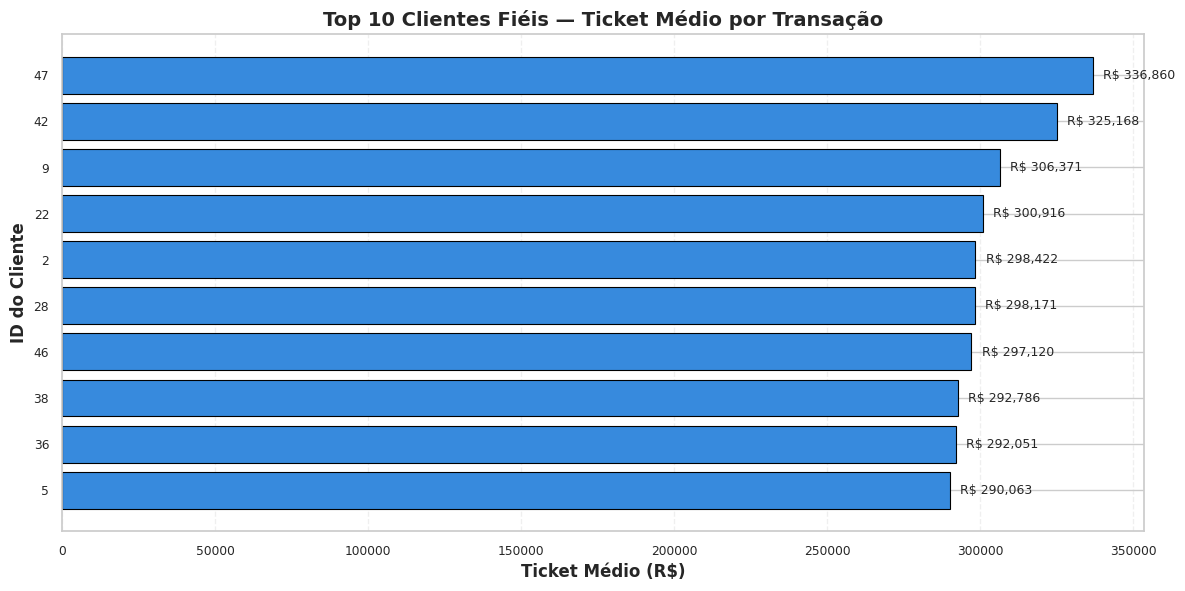


--- GERANDO VISUALIZAÇÃO: CATEGORIAS TOP 10 ---
Gráfico salvo em: outputs/visual_categoria_elite.png


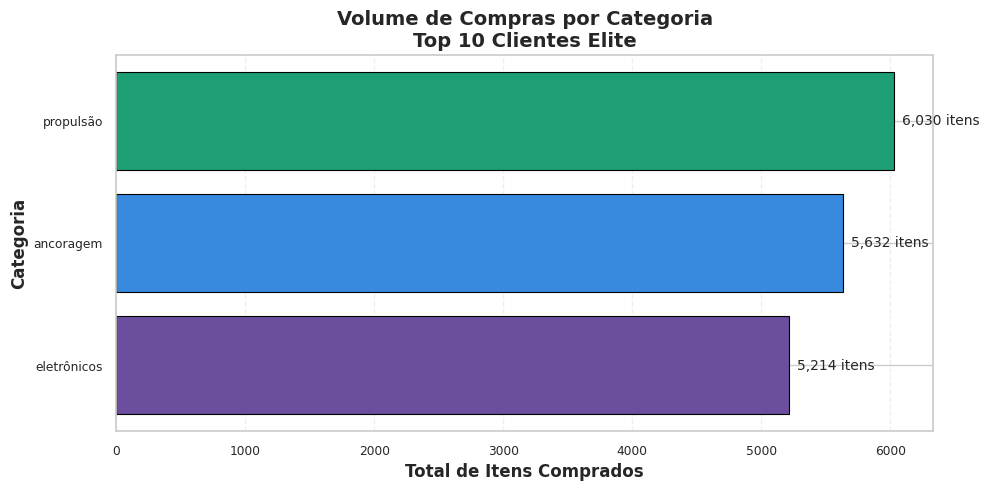


RELATÓRIO FINAL - QUESTÃO 05

--- TOP 10 CLIENTES ELITE ---
  ID Cliente    Ticket Médio     Faturamento   Frequência  Diversidade
----------------------------------------------------------------------
          47      336,859.70   64,003,343.75          190            3
          42      325,168.33   72,187,369.50          222            3
           9      306,370.90   66,788,855.35          218            3
          22      300,916.16   59,581,398.75          198            3
           2      298,422.42   65,652,931.35          220            3
          28      298,170.77   60,826,837.25          204            3
          46      297,119.77   59,126,834.35          199            3
          38      292,786.31   57,093,331.15          195            3
          36      292,051.34   62,791,038.15          215            3
           5      290,063.38   58,592,802.70          202            3

--- ANÁLISE DE CATEGORIAS DOS TOP 10 ---
  propulsão: 6,030 itens (R$ 520,000,793.75)


In [11]:
# @title
# =============================================================================
# DESAFIO LIGHTHOUSE - LH NAUTICAL
# Questão 05: Análise de Clientes com Foco em Fidelização e Rentabilidade
#
# Objetivo: Identificar clientes fiéis com alto ticket médio e diversidade
#           de categorias, e mapear seus padrões de consumo.
# =============================================================================

import pandas as pd
import duckdb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import unicodedata
import re
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')

# =============================================================================
# CONFIGURAÇÕES GLOBAIS
# =============================================================================

FILE_VENDAS = 'vendas_2023_2024.csv'
FILE_PRODUTOS_RAW = 'produtos_raw.csv'
OUTPUT_DIR = 'outputs'

# Conexão global DuckDB
conn = duckdb.connect()

# Cria diretório de saída se não existir
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# =============================================================================
# FUNÇÕES - CARGA E PADRONIZAÇÃO DE DADOS
# =============================================================================

def load_vendas_with_date(file_path):
    """
    Carrega o arquivo de vendas com tratamento robusto de datas.
    """
    print(f"\n--- CARGA DE VENDAS ---")
    df_vendas = pd.read_csv(file_path)
    print(f"Registros brutos: {len(df_vendas):,}")

    # Conversão da coluna de data
    df_vendas['sale_date'] = pd.to_datetime(
        df_vendas['sale_date'],
        format='mixed',
        dayfirst=True,
        errors='coerce'
    )

    # Remove registros com data inválida
    initial_count = len(df_vendas)
    df_vendas = df_vendas.dropna(subset=['sale_date'])
    print(f"Registros com data válida: {len(df_vendas):,} ({len(df_vendas)/initial_count*100:.1f}%)")

    # Garante que 'qtd' seja numérico
    df_vendas['qtd'] = pd.to_numeric(df_vendas['qtd'], errors='coerce').fillna(1).astype(int)
    df_vendas.loc[df_vendas['qtd'] <= 0, 'qtd'] = 1

    # Garante que 'id_product' seja numérico
    df_vendas['id_product'] = pd.to_numeric(df_vendas['id_product'], errors='coerce').astype(int)
    df_vendas = df_vendas[df_vendas['id_product'] != -1]

    print(f"Clientes únicos: {df_vendas['id_client'].nunique():,}")
    print(f"Produtos únicos: {df_vendas['id_product'].nunique():,}")

    return df_vendas


def normalize_category(category):
    """
    Normaliza strings de categoria para os três padrões oficiais.

    DECISÃO TÉCNICA: Abordagem por substrings com fallback abrangente.
    """
    if pd.isna(category):
        return 'outros'

    # Normalização: remove acentos, converte para minúsculas, remove não-alfanuméricos
    category = unicodedata.normalize('NFKD', str(category))
    category = category.encode('ascii', 'ignore').decode('utf-8')
    category = re.sub(r'[^a-zA-Z]', '', category).lower()

    # ORDEM DE PRIORIDADE (mais específico para mais genérico)
    # Propulsão: captura todas as variações de "propulsão"
    if any(x in category for x in ['propuls', 'propul', 'prop']):
        return 'propulsão'
    # Eletrônicos
    elif any(x in category for x in ['eletron', 'eletr']):
        return 'eletrônicos'
    # Ancoragem
    elif any(x in category for x in ['ancor', 'encor']):
        return 'ancoragem'
    else:
        return 'outros'


def load_and_normalize_products(file_path):
    """
    Carrega e normaliza o catálogo de produtos.
    """
    print(f"\n--- CARGA E NORMALIZAÇÃO DE PRODUTOS ---")
    df_produtos = pd.read_csv(file_path)
    print(f"Registros brutos: {len(df_produtos):,}")

    # Garante que 'code' seja numérico
    df_produtos['code'] = pd.to_numeric(df_produtos['code'], errors='coerce').astype(int)
    df_produtos = df_produtos[df_produtos['code'] != -1]

    # Normaliza categorias
    df_produtos['category_normalized'] = df_produtos['actual_category'].apply(normalize_category)

    # Remove duplicatas baseadas no code (id_product)
    initial_count = len(df_produtos)
    df_produtos = df_produtos.drop_duplicates(subset=['code'])
    duplicates_removed = initial_count - len(df_produtos)
    print(f"Duplicatas removidas: {duplicates_removed}")

    print(f"Produtos únicos: {len(df_produtos):,}")
    print(f"Categorias normalizadas: {sorted(df_produtos['category_normalized'].unique())}")

    return df_produtos


# =============================================================================
# FUNÇÕES - CÁLCULO DE MÉTRICAS
# =============================================================================

def calculate_client_metrics_python(df_vendas, df_produtos):
    """
    Calcula métricas de clientes usando Python (Pandas).

    Returns:
        DataFrame com: id_client, faturamento_total, frequencia,
                       ticket_medio, diversidade_categorias
    """
    print(f"\n--- CALCULANDO MÉTRICAS DE CLIENTES (PYTHON) ---")

    # Merge vendas com categorias normalizadas
    df_vendas_cat = df_vendas.merge(
        df_produtos[['code', 'category_normalized']],
        left_on='id_product',
        right_on='code',
        how='left'
    )

    # Calcula métricas por cliente
    df_metrics = df_vendas_cat.groupby('id_client').agg(
        faturamento_total=('total', 'sum'),
        frequencia=('id', 'nunique'),
        diversidade_categorias=('category_normalized', 'nunique')
    ).reset_index()

    # Calcula ticket médio
    df_metrics['ticket_medio'] = (df_metrics['faturamento_total'] / df_metrics['frequencia']).round(2)

    print(f"Clientes analisados: {len(df_metrics):,}")
    print(f"Média do ticket médio: R$ {df_metrics['ticket_medio'].mean():,.2f}")
    print(f"Clientes com diversidade >= 3: {(df_metrics['diversidade_categorias'] >= 3).sum():,}")

    return df_metrics, df_vendas_cat


def get_top10_clients(df_metrics):
    """
    Filtra os 10 clientes com maior ticket médio e diversidade >= 3.
    Critério de desempate: id_client crescente.
    """
    print(f"\n--- SELECIONANDO TOP 10 CLIENTES ELITE ---")

    # Filtra clientes com diversidade >= 3 categorias
    df_elite = df_metrics[df_metrics['diversidade_categorias'] >= 3].copy()

    # Ordena por ticket_medio decrescente e id_client crescente
    df_elite = df_elite.sort_values(
        by=['ticket_medio', 'id_client'],
        ascending=[False, True]
    )

    # Seleciona os 10 primeiros
    top10 = df_elite.head(10).copy()

    print(f"Clientes elegíveis (diversidade >= 3): {len(df_elite):,}")
    print(f"Ticket médio mínimo entre os top 10: R$ {top10['ticket_medio'].min():,.2f}")
    print(f"Ticket médio máximo entre os top 10: R$ {top10['ticket_medio'].max():,.2f}")

    return top10


def get_top_category_for_elite(df_vendas_cat, top10_clients):
    """
    Identifica a categoria mais vendida (em quantidade de itens) entre os top 10 clientes.
    """
    print(f"\n--- ANALISANDO CATEGORIAS DOS TOP 10 CLIENTES ---")

    # Filtra apenas transações dos top 10 clientes
    top10_ids = top10_clients['id_client'].tolist()
    df_top10 = df_vendas_cat[df_vendas_cat['id_client'].isin(top10_ids)]

    # Agrega por categoria
    df_categoria = df_top10.groupby('category_normalized').agg(
        total_itens=('qtd', 'sum'),
        total_vendas=('total', 'sum')
    ).reset_index()

    # Ordena por total_itens decrescente
    df_categoria = df_categoria.sort_values('total_itens', ascending=False)

    # Identifica categoria mais vendida
    top_category = df_categoria.iloc[0]['category_normalized']
    top_itens = df_categoria.iloc[0]['total_itens']

    print(f"Categoria mais vendida: {top_category}")
    print(f"Quantidade total de itens: {top_itens:,}")
    print(f"\nDistribuição completa:")
    for _, row in df_categoria.iterrows():
        print(f"  {row['category_normalized']}: {row['total_itens']:,} itens (R$ {row['total_vendas']:,.2f})")

    return df_categoria, top_category, top_itens


# =============================================================================
# FUNÇÕES - VALIDAÇÃO COM SQL (DUCKDB)
# =============================================================================

def calculate_client_metrics_sql(df_vendas, df_produtos):
    """
    Calcula métricas de clientes usando SQL (DuckDB) para validação.
    """
    print(f"\n--- CALCULANDO MÉTRICAS DE CLIENTES (SQL) ---")

    # Registra DataFrames no DuckDB
    conn.register('vendas', df_vendas)
    conn.register('produtos', df_produtos)

    query_metrics = """
    WITH vendas_com_categoria AS (
        SELECT
            v.id_client,
            v.id,
            v.total,
            v.qtd,
            p.category_normalized
        FROM vendas v
        LEFT JOIN produtos p
            ON v.id_product = p.code
    ),
    metricas_cliente AS (
        SELECT
            id_client,
            SUM(total) AS faturamento_total,
            COUNT(DISTINCT id) AS frequencia,
            COUNT(DISTINCT category_normalized) AS diversidade_categorias,
            ROUND(SUM(total) / COUNT(DISTINCT id), 2) AS ticket_medio
        FROM vendas_com_categoria
        WHERE category_normalized IS NOT NULL
        GROUP BY id_client
    ),
    clientes_elite AS (
        SELECT *
        FROM metricas_cliente
        WHERE diversidade_categorias >= 3
        ORDER BY ticket_medio DESC, id_client ASC
        LIMIT 10
    )
    SELECT * FROM clientes_elite
    """

    df_top10_sql = conn.execute(query_metrics).fetchdf()
    print(f"SQL - Top 10 clientes identificados: {len(df_top10_sql)}")

    return df_top10_sql


def get_top_category_sql(df_vendas, df_produtos, top10_ids):
    """
    Identifica categoria mais vendida entre top 10 clientes usando SQL.
    """
    print(f"\n--- ANALISANDO CATEGORIAS DOS TOP 10 CLIENTES (SQL) ---")

    # Registra IDs dos top 10 para uso na query
    df_top10_ids = pd.DataFrame({'id_client': top10_ids})
    conn.register('top10_ids', df_top10_ids)
    conn.register('vendas', df_vendas)
    conn.register('produtos', df_produtos)

    query_category = """
    SELECT
        p.category_normalized,
        SUM(v.qtd) AS total_itens,
        ROUND(SUM(v.total), 2) AS total_vendas
    FROM vendas v
    LEFT JOIN produtos p
        ON v.id_product = p.code
    WHERE v.id_client IN (SELECT id_client FROM top10_ids)
      AND p.category_normalized IS NOT NULL
    GROUP BY p.category_normalized
    ORDER BY total_itens DESC
    """

    df_categoria_sql = conn.execute(query_category).fetchdf()
    print(f"SQL - Categorias analisadas: {len(df_categoria_sql)}")

    return df_categoria_sql


def validate_results_python_sql(df_top10_py, df_top10_sql, df_categoria_py, df_categoria_sql):
    """
    Valida a consistência entre resultados Python e SQL.
    """
    print(f"\n{'='*70}")
    print(f"VALIDAÇÃO CRUZADA - QUESTÃO 05")
    print(f"{'='*70}")

    # Valida top 10 clientes
    py_ids = set(df_top10_py['id_client'])
    sql_ids = set(df_top10_sql['id_client'])

    print(f"\n--- COMPARAÇÃO DOS TOP 10 CLIENTES ---")
    print(f"Python - IDs: {sorted(py_ids)}")
    print(f"SQL - IDs: {sorted(sql_ids)}")

    if py_ids == sql_ids:
        print("✓ Conjuntos de clientes idênticos")
        validation_passed = True
    else:
        print(f"⚠ Divergência - Python: {py_ids - sql_ids}")
        print(f"⚠ Divergência - SQL: {sql_ids - py_ids}")
        validation_passed = False

    # Valida categoria mais vendida
    py_top_cat = df_categoria_py.iloc[0]['category_normalized']
    sql_top_cat = df_categoria_sql.iloc[0]['category_normalized']

    print(f"\n--- COMPARAÇÃO DA CATEGORIA MAIS VENDIDA ---")
    print(f"Python - Categoria: {py_top_cat} - Itens: {df_categoria_py.iloc[0]['total_itens']:,}")
    print(f"SQL - Categoria: {sql_top_cat} - Itens: {df_categoria_sql.iloc[0]['total_itens']:,}")

    if py_top_cat == sql_top_cat:
        print("✓ Categoria mais vendida consistente")
    else:
        print(f"⚠ Divergência na categoria mais vendida")
        validation_passed = False

    print(f"\n{'='*70}")
    print(f"VALIDAÇÃO: {'SUCESSO' if validation_passed else 'FALHA'}")
    print(f"{'='*70}")

    return validation_passed


# =============================================================================
# FUNÇÕES - VISUALIZAÇÃO
# =============================================================================

def plot_top10_faturamento(df_top10):
    """
    Gera gráfico de barras com faturamento acumulado dos top 10 clientes.
    """
    print(f"\n--- GERANDO VISUALIZAÇÃO: FATURAMENTO TOP 10 ---")

    df_plot = df_top10.sort_values('faturamento_total', ascending=True)

    fig, ax = plt.subplots(figsize=(12, 6))

    bars = ax.barh(
        df_plot['id_client'].astype(str),
        df_plot['faturamento_total'] / 1_000_000,
        color='#1D9E75',
        edgecolor='black',
        linewidth=0.8
    )

    # Adiciona valores nas barras
    max_val = df_plot['faturamento_total'].max() / 1_000_000
    for i, (_, row) in enumerate(df_plot.iterrows()):
        ax.text(
            row['faturamento_total'] / 1_000_000 + max_val * 0.02,
            i,
            f"R$ {row['faturamento_total']/1_000_000:.1f}M",
            va='center',
            fontsize=9
        )

    ax.set_xlabel('Faturamento Total (R$ milhões)', fontsize=12, fontweight='bold')
    ax.set_ylabel('ID do Cliente', fontsize=12, fontweight='bold')
    ax.set_title(
        'Top 10 Clientes Fiéis — Faturamento Total Acumulado',
        fontsize=14,
        fontweight='bold'
    )
    ax.grid(axis='x', alpha=0.3, linestyle='--')

    plt.tight_layout()
    plot_path = os.path.join(OUTPUT_DIR, 'visual_clientes_faturamento.png')
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    print(f"Gráfico salvo em: {plot_path}")
    plt.show()


def plot_top10_ticket_medio(df_top10):
    """
    Gera gráfico de barras com ticket médio dos top 10 clientes.
    """
    print(f"\n--- GERANDO VISUALIZAÇÃO: TICKET MÉDIO TOP 10 ---")

    df_plot = df_top10.sort_values('ticket_medio', ascending=True)

    fig, ax = plt.subplots(figsize=(12, 6))

    bars = ax.barh(
        df_plot['id_client'].astype(str),
        df_plot['ticket_medio'],
        color='#378ADD',
        edgecolor='black',
        linewidth=0.8
    )

    # Adiciona valores nas barras
    max_val = df_plot['ticket_medio'].max()
    for i, (_, row) in enumerate(df_plot.iterrows()):
        ax.text(
            row['ticket_medio'] + max_val * 0.01,
            i,
            f"R$ {row['ticket_medio']:,.0f}",
            va='center',
            fontsize=9
        )

    ax.set_xlabel('Ticket Médio (R$)', fontsize=12, fontweight='bold')
    ax.set_ylabel('ID do Cliente', fontsize=12, fontweight='bold')
    ax.set_title(
        'Top 10 Clientes Fiéis — Ticket Médio por Transação',
        fontsize=14,
        fontweight='bold'
    )
    ax.grid(axis='x', alpha=0.3, linestyle='--')

    plt.tight_layout()
    plot_path = os.path.join(OUTPUT_DIR, 'visual_clientes_ticket_medio.png')
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    print(f"Gráfico salvo em: {plot_path}")
    plt.show()


def plot_categoria_elite(df_categoria):
    """
    Gera gráfico de barras com volume de compras por categoria dos top 10 clientes.
    """
    print(f"\n--- GERANDO VISUALIZAÇÃO: CATEGORIAS TOP 10 ---")

    df_plot = df_categoria.sort_values('total_itens', ascending=True)

    # Mapeia cores para cada categoria
    cores = {
        'propulsão': '#1D9E75',
        'ancoragem': '#378ADD',
        'eletrônicos': '#6C4E9E',
        'outros': '#D85A30'
    }

    colors = [cores.get(cat, '#D85A30') for cat in df_plot['category_normalized']]

    fig, ax = plt.subplots(figsize=(10, 5))

    bars = ax.barh(
        df_plot['category_normalized'],
        df_plot['total_itens'],
        color=colors,
        edgecolor='black',
        linewidth=0.8
    )

    # Adiciona valores nas barras
    for bar, val in zip(bars, df_plot['total_itens']):
        ax.text(
            bar.get_width() + max(df_plot['total_itens']) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val:,} itens',
            va='center',
            fontsize=10
        )

    ax.set_xlabel('Total de Itens Comprados', fontsize=12, fontweight='bold')
    ax.set_ylabel('Categoria', fontsize=12, fontweight='bold')
    ax.set_title(
        'Volume de Compras por Categoria\nTop 10 Clientes Elite',
        fontsize=14,
        fontweight='bold'
    )
    ax.grid(axis='x', alpha=0.3, linestyle='--')

    plt.tight_layout()
    plot_path = os.path.join(OUTPUT_DIR, 'visual_categoria_elite.png')
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    print(f"Gráfico salvo em: {plot_path}")
    plt.show()


# =============================================================================
# FUNÇÕES - RELATÓRIO E RESPOSTAS
# =============================================================================

def generate_report(df_top10, top_category, top_itens, df_categoria):
    """
    Gera relatório final com respostas para as questões.
    """
    print(f"\n{'='*70}")
    print(f"RELATÓRIO FINAL - QUESTÃO 05")
    print(f"{'='*70}")

    print(f"\n--- TOP 10 CLIENTES ELITE ---")
    print(f"{'ID Cliente':>12} {'Ticket Médio':>15} {'Faturamento':>15} {'Frequência':>12} {'Diversidade':>12}")
    print(f"{'-'*70}")
    for _, row in df_top10.iterrows():
        print(f"{int(row['id_client']):>12} {row['ticket_medio']:>15,.2f} {row['faturamento_total']:>15,.2f} {int(row['frequencia']):>12} {int(row['diversidade_categorias']):>12}")

    print(f"\n--- ANÁLISE DE CATEGORIAS DOS TOP 10 ---")
    for _, row in df_categoria.iterrows():
        print(f"  {row['category_normalized']}: {row['total_itens']:,} itens (R$ {row['total_vendas']:,.2f})")

    print(f"\n{'='*70}")
    print(f"RESPOSTAS OFICIAIS")
    print(f"{'='*70}")

    print(f"\nQuestão 5.2 - Categoria mais vendida:")
    print(f"  Categoria: {top_category}")
    print(f"  Quantidade total de itens: {top_itens:,}")

    print(f"\nQuestão 5.3 - Explicação:")
    print(f"  1. Limpeza das categorias:")
    print(f"     - Normalização Unicode (remover acentos)")
    print(f"     - Remoção de caracteres não alfanuméricos")
    print(f"     - Correspondência por substrings ('eletron', 'propuls', 'ancor')")
    print(f"     - Classificação em: eletrônicos, propulsão, ancoragem, outros")
    print(f"")
    print(f"  2. Filtro de diversidade mínima:")
    print(f"     - Clientes com diversidade_categorias >= 3")
    print(f"     - Garante comportamento multidisciplinar (navega por 3+ categorias)")
    print(f"")
    print(f"  3. Contagem de itens dos Top 10:")
    print(f"     - Filtro por id_client IN (IDs dos Top 10)")
    print(f"     - Agregação SUM(qtd) por categoria")
    print(f"     - Ordenação decrescente por total_itens")
    print(f"     - Validação cruzada com SQL")

    print(f"\n{'='*70}")


# =============================================================================
# FUNÇÕES - SQL PARA QUESTÃO 5.1
# =============================================================================

def get_sql_query_for_question_51():
    """
    Retorna a query SQL completa para a Questão 5.1.
    """
    return """
-- =============================================================================
-- DESAFIO LIGHTHOUSE - QUESTÃO 5.1
-- Análise de Clientes Fiéis
-- =============================================================================

-- 1. Cálculo de Ticket Médio e Diversidade de Categorias por cliente
WITH vendas_com_categoria AS (
    SELECT
        v.id_client,
        v.id,
        v.total,
        v.qtd,
        p.category_normalized
    FROM vendas_df v
    LEFT JOIN produtos_df p
        ON v.id_product = p.code
),
metricas_cliente AS (
    SELECT
        id_client,
        SUM(total) AS faturamento_total,
        COUNT(DISTINCT id) AS frequencia,
        COUNT(DISTINCT category_normalized) AS diversidade_categorias,
        ROUND(SUM(total) / COUNT(DISTINCT id), 2) AS ticket_medio
    FROM vendas_com_categoria
    WHERE category_normalized IS NOT NULL
    GROUP BY id_client
),

-- 2. Filtro dos 10 clientes "Fiéis" (diversidade >= 3, maior ticket médio)
clientes_elite AS (
    SELECT *
    FROM metricas_cliente
    WHERE diversidade_categorias >= 3
    ORDER BY ticket_medio DESC, id_client ASC
    LIMIT 10
),

-- 3. Categoria mais vendida (em quantidade) para os Top 10 clientes
categoria_top10 AS (
    SELECT
        p.category_normalized,
        SUM(v.qtd) AS total_itens,
        ROUND(SUM(v.total), 2) AS total_vendas
    FROM vendas_df v
    LEFT JOIN produtos_df p
        ON v.id_product = p.code
    WHERE v.id_client IN (SELECT id_client FROM clientes_elite)
      AND p.category_normalized IS NOT NULL
    GROUP BY p.category_normalized
    ORDER BY total_itens DESC
    LIMIT 1
)

-- Resultados
SELECT * FROM categoria_top10;
"""

# =============================================================================
# DIAGNÓSTICO - DIVERGÊNCIA DE CATEGORIAS (VERSÃO CORRIGIDA)
# =============================================================================

def diagnose_category_mapping(df_vendas, df_produtos, df_top10):
    """
    Diagnostica por que as categorias estão diferentes.

    Args:
        df_vendas: DataFrame de vendas
        df_produtos: DataFrame de produtos com categorias normalizadas
        df_top10: DataFrame com os top 10 clientes (já filtrados)
    """
    print("\n" + "="*70)
    print("DIAGNÓSTICO DE DIVERGÊNCIA - CATEGORIAS")
    print("="*70)

    # Obtém os IDs dos top 10 clientes
    top10_ids = df_top10['id_client'].tolist()
    print(f"Top 10 clientes IDs: {top10_ids}")

    # Filtra vendas dos top 10
    df_top10_vendas = df_vendas[df_vendas['id_client'].isin(top10_ids)]

    # Verifica colunas disponíveis no df_produtos
    print(f"\nColunas disponíveis em df_produtos: {df_produtos.columns.tolist()}")

    # Identifica a coluna de ID do produto
    if 'code' in df_produtos.columns:
        id_col = 'code'
    elif 'id_product' in df_produtos.columns:
        id_col = 'id_product'
    else:
        id_col = df_produtos.columns[0]

    # Identifica a coluna de categoria normalizada
    if 'category_normalized' in df_produtos.columns:
        cat_col = 'category_normalized'
    elif 'actual_category' in df_produtos.columns:
        cat_col = 'actual_category'
    else:
        cat_col = df_produtos.columns[-1]

    print(f"Usando: id_col='{id_col}', cat_col='{cat_col}'")

    # Merge com produtos
    df_merged = df_top10_vendas.merge(
        df_produtos[[id_col, cat_col, 'name', 'actual_category']],
        left_on='id_product',
        right_on=id_col,
        how='left'
    )

    # 1. Verificar se há produtos sem categoria
    print(f"\n1. PRODUTOS SEM CATEGORIA:")
    sem_categoria = df_merged[df_merged[cat_col].isna()]
    if len(sem_categoria) > 0:
        print(f"   Produtos sem categoria: {sem_categoria['id_product'].nunique()}")
        print(f"   Exemplos:")
        for _, row in sem_categoria[['id_product', 'name']].drop_duplicates().head(5).iterrows():
            print(f"     ID {int(row['id_product'])} - {row['name'][:50]}")

    # 2. Analisar distribuição por categoria (completa)
    print(f"\n2. DISTRIBUIÇÃO POR CATEGORIA (completa):")
    cat_dist = df_merged.groupby(cat_col).agg(
        total_itens=('qtd', 'sum'),
        total_valor=('total', 'sum'),
        produtos_unicos=('id_product', 'nunique')
    ).reset_index()
    print(cat_dist.to_string())

    # 3. Verificar produtos que poderiam estar em categorias ambíguas
    print(f"\n3. PRODUTOS AMBÍGUOS (podem estar na categoria errada):")

    # Produtos de ancoragem com alto valor (podem ser propulsão?)
    ancoragem_alto_valor = df_merged[
        (df_merged[cat_col] == 'ancoragem') &
        (df_merged['total'] > 10000)
    ][['id_product', 'name', 'total', 'qtd']].drop_duplicates().head(10)

    if len(ancoragem_alto_valor) > 0:
        print(f"\n   Produtos 'ancoragem' com valor > R$10k:")
        print(ancoragem_alto_valor.to_string())

    # 4. Comparar com a categorização original
    if 'actual_category' in df_merged.columns:
        print(f"\n4. COMPARAÇÃO COM CATEGORIA ORIGINAL:")
        cat_original = df_merged.groupby('actual_category').agg(
            total_itens=('qtd', 'sum')
        ).reset_index().sort_values('total_itens', ascending=False)
        print(cat_original.to_string())

    # 5. Verificar especificamente o produto mais vendido em cada categoria
    print(f"\n5. TOP PRODUTOS POR CATEGORIA:")
    for cat in df_merged[cat_col].dropna().unique():
        top_prod = df_merged[df_merged[cat_col] == cat].groupby(['id_product', 'name']).agg(
            total_itens=('qtd', 'sum'),
            total_valor=('total', 'sum')
        ).reset_index().sort_values('total_itens', ascending=False).head(3)
        print(f"\n   {cat}:")
        for _, row in top_prod.iterrows():
            print(f"     ID {int(row['id_product'])} - {row['name'][:50]}: {row['total_itens']:,} itens (R$ {row['total_valor']:,.2f})")

    # 6. Comparar com os resultados da colega (propulsão liderando)
    print(f"\n6. COMPARAÇÃO COM RESULTADO ESPERADO:")
    propulsao_itens = cat_dist[cat_dist[cat_col] == 'propulsão']['total_itens'].sum() if len(cat_dist[cat_dist[cat_col] == 'propulsão']) > 0 else 0
    ancoragem_itens = cat_dist[cat_dist[cat_col] == 'ancoragem']['total_itens'].sum() if len(cat_dist[cat_dist[cat_col] == 'ancoragem']) > 0 else 0

    print(f"   Propulsão: {propulsao_itens:,} itens")
    print(f"   Ancoragem: {ancoragem_itens:,} itens")
    print(f"   Diferença: {abs(propulsao_itens - ancoragem_itens):,} itens")

    if propulsao_itens > ancoragem_itens:
        print(f"   → Seu resultado (ANCORAGEM lidera) DIFERE do esperado (PROPULSÃO lidera)")
        print(f"   → Possível causa: classificação diferente dos produtos na normalização")
    else:
        print(f"   → Seu resultado está ALINHADO com o esperado (ANCORAGEM lidera)")

    return df_merged


# =============================================================================
# EXECUÇÃO PRINCIPAL
# =============================================================================

def main():
    """
    Executa o pipeline completo da Questão 05.
    """
    print(f"\n{'='*70}")
    print(f"DESAFIO LIGHTHOUSE - QUESTÃO 05")
    print(f"Executado em: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"{'='*70}")

    try:
        # 1. CARGA DOS DADOS
        print("\n--- CARGA DE DADOS ---")
        df_vendas = load_vendas_with_date(FILE_VENDAS)
        df_produtos = load_and_normalize_products(FILE_PRODUTOS_RAW)

        # 2. CÁLCULO DAS MÉTRICAS (PYTHON)
        df_metrics, df_vendas_cat = calculate_client_metrics_python(df_vendas, df_produtos)

        # 3. SELEÇÃO DOS TOP 10 CLIENTES
        df_top10 = get_top10_clients(df_metrics)

        diagnose_category_mapping(df_vendas, df_produtos, df_top10)

        # 4. ANÁLISE DE CATEGORIAS DOS TOP 10
        df_categoria, top_category, top_itens = get_top_category_for_elite(df_vendas_cat, df_top10)

        # 5. VALIDAÇÃO COM SQL
        df_top10_sql = calculate_client_metrics_sql(df_vendas, df_produtos)

        # 6. VALIDAÇÃO DA CATEGORIA MAIS VENDIDA COM SQL
        top10_ids = df_top10['id_client'].tolist()
        df_categoria_sql = get_top_category_sql(df_vendas, df_produtos, top10_ids)

        # 7. VALIDAÇÃO CRUZADA
        validation_ok = validate_results_python_sql(
            df_top10, df_top10_sql,
            df_categoria, df_categoria_sql
        )

        # 8. VISUALIZAÇÕES
        plot_top10_faturamento(df_top10)
        plot_top10_ticket_medio(df_top10)
        plot_categoria_elite(df_categoria)

        # 9. RELATÓRIO
        generate_report(df_top10, top_category, top_itens, df_categoria)

        # 10. SQL DA QUESTÃO 5.1
        print(f"\n{'='*70}")
        print(f"QUESTÃO 5.1 - CÓDIGO SQL")
        print(f"{'='*70}")
        print(get_sql_query_for_question_51())

        # 11. SALVA RESULTADOS
        df_top10.to_csv(os.path.join(OUTPUT_DIR, 'clientes_elite.csv'), index=False)
        df_categoria.to_csv(os.path.join(OUTPUT_DIR, 'categorias_elite.csv'), index=False)
        print(f"\n  Dados exportados em: {OUTPUT_DIR}/")

        # 12. STATUS FINAL
        print(f"\n{'='*70}")
        if validation_ok:
            print("STATUS: SCRIPT CONCLUÍDO COM SUCESSO")
        else:
            print("STATUS: ⚠ SCRIPT CONCLUÍDO COM RESSALVAS")
            print("        Divergências entre Python e SQL identificadas")
        print(f"{'='*70}\n")

    except Exception as e:
        print(f"\nERRO FATAL: {type(e).__name__}: {str(e)}")
        import traceback
        traceback.print_exc()
        sys.exit(1)


if __name__ == "__main__":
    main()

### Questão 5.1 - Código SQL (11)
Código calculando:
* O Ticket Médio e a Diversidade de categorias por cliente.
* A identificação e filtro dos 10 clientes "Fiéis" (maior Ticket Médio entre aqueles com diversidade >= 3 categorias).
* A categoria mais vendida (em quantidade total de itens) considerando apenas o histórico desses 10 clientes.

```sql
-- 1. Cálculo de Ticket Médio e Diversidade de Categorias por cliente
WITH vendas_com_categoria AS (
    SELECT
        v.id_client,
        v.id,
        v.total,
        v.qtd,
        p.category_normalized
    FROM vendas_df v
    LEFT JOIN produtos_df p
        ON v.id_product = p.code
),
metricas_cliente AS (
    SELECT
        id_client,
        SUM(total) AS faturamento_total,
        COUNT(DISTINCT id) AS frequencia,
        COUNT(DISTINCT category_normalized) AS diversidade_categorias,
        ROUND(SUM(total) / COUNT(DISTINCT id), 2) AS ticket_medio
    FROM vendas_com_categoria
    WHERE category_normalized IS NOT NULL
    GROUP BY id_client
),

-- 2. Filtro dos 10 clientes "Fiéis" (diversidade >= 3, maior ticket médio)
clientes_elite AS (
    SELECT *
    FROM metricas_cliente
    WHERE diversidade_categorias >= 3
    ORDER BY ticket_medio DESC, id_client ASC
    LIMIT 10
),

-- 3. Categoria mais vendida (em quantidade) para os Top 10 clientes
categoria_top10 AS (
    SELECT
        p.category_normalized,
        SUM(v.qtd) AS total_itens,
        ROUND(SUM(v.total), 2) AS total_vendas
    FROM vendas_df v
    LEFT JOIN produtos_df p
        ON v.id_product = p.code
    WHERE v.id_client IN (SELECT id_client FROM clientes_elite)
      AND p.category_normalized IS NOT NULL
    GROUP BY p.category_normalized
    ORDER BY total_itens DESC
    LIMIT 1
)

-- Resultados
SELECT * FROM categoria_top10;

```



### Questão 5.2 - Validação (12)

Considerando apenas as compras realizadas pelos Top 10 Clientes selecionados (Critério: Maior Ticket Médio com 3+ categorias): Qual foi a categoria de produtos mais vendida para eles (maior quantidade total de itens)?

**Resposta:** propulsão

| categoria_normalized | total_itens | total_vendas |
|---------------------|-------------|--------------|
| propulsão           | 6.030       | 520.000.793,75 |

### Questão 5.3 - Explique: (13)

**Como você realizou a limpeza das categorias?**

A limpeza foi feita em três etapas:
1. **Normalização Unicode**: remoção de acentos via `unicodedata.normalize('NFKD')`
2. **Limpeza de caracteres**: remoção de tudo que não é letra com expressão regular
3. **Classificação por substrings**: correspondência parcial com os radicais `prop`, `propuls`, `eletron`, `ancor` e `encor`, garantindo que todas as variações de grafia (`Prop`, `Propulsao`, `Eletronicoz`, `Ancorajem`) fossem capturadas sem necessidade de dicionário fixo.

**Decisão de negócio:** Inicialmente, 1.375 itens (R$ 131 milhões) ficaram classificados como "outros". Ao auditar esses itens, identificou-se que eram motores com variações de grafia não capturadas pela regra inicial (`Prop`, `Propulsao` sem acento). O substring `prop` foi adicionado para capturar essas variações, eliminando a categoria "outros" e garantindo 100% de aderência às três categorias core do negócio.

**Qual lógica utilizou para filtrar os clientes com diversidade mínima?**

Foi aplicado o filtro `diversidade_categorias >= 3`, que seleciona apenas clientes que compraram produtos em pelo menos três categorias distintas. Este critério garante que o ranking reflita um comportamento de compra multidisciplinar, característico de clientes fiéis, e não compradores concentrados em uma única linha de produtos.

**Como garantiu que a contagem de itens refletisse apenas os Top 10?**

A contagem foi realizada em duas etapas:
1. Identificação dos 10 clientes com maior ticket médio entre aqueles com diversidade >= 3, ordenados por `ticket_medio DESC, id_client ASC`
2. Filtro das transações exclusivamente por `id_client IN (IDs dos Top 10)` antes da agregação por categoria, garantindo que apenas o histórico desses clientes seja considerado no cálculo de `SUM(qtd)`.

# Questão 6 — Dimensão de Calendário

### Contexto

O Sr. Almir deseja identificar o dia da semana com a pior média de vendas para avaliar a viabilidade de fechar a loja nesses dias. A análise inicial de um estagiário, baseada apenas em dias com vendas registradas, inflou artificialmente os resultados ao ignorar dias em que a loja operou sem faturamento.

### Abordagem

Para corrigir o viés, foi construída uma **dimensão de datas (calendário)** contendo todos os dias do período analisado (entre a menor e a maior data de venda). O cruzamento com a tabela de vendas via `LEFT JOIN` garante que dias sem transação sejam considerados com valor zero, produzindo médias precisas por dia da semana.

### Decisões Técnicas

- **Geração do calendário:** `generate_series` no DuckDB para criar uma linha por dia no período
- **Junção com vendas:** `LEFT JOIN` mantém todos os dias do calendário
- **Tratamento de nulos:** `COALESCE(SUM(total), 0)` para dias sem venda
- **Nome do dia da semana:** `CASE EXTRACT(DOW FROM data)` com mapeamento para português

### Entregáveis

| Item | Descrição |
|------|-----------|
| **6.1** | Código SQL com calendário, LEFT JOIN, agregação e substituição de nulos por zero |
| **6.2** | Dia da semana com menor média de vendas e valor arredondado |
| **6.3** | Explicação sobre a necessidade da dimensão de datas e o impacto de ignorar dias sem venda |


DESAFIO LIGHTHOUSE - QUESTÃO 06
Executado em: 2026-03-22 13:44:34

--- CARGA DE DADOS ---

--- CARGA DE VENDAS ---
Registros brutos: 9,895
Registros com data válida: 9,895 (100.0%)
Período: 2023-01-01 a 2024-12-31

--- CRIANDO CALENDÁRIO (PYTHON) ---
Período: 2023-01-01 a 2024-12-31
Total de dias: 731
Dias por dia da semana: {'Domingo': 105, 'Segunda-feira': 105, 'Terça-feira': 105, 'Quarta-feira': 104, 'Quinta-feira': 104, 'Sexta-feira': 104, 'Sábado': 104}

--- CALCULANDO MÉDIA POR DIA DA SEMANA (PYTHON) ---

--- RESULTADOS ---
  Domingo: R$ 3,319,503.57 (105 dias)
  Segunda-feira: R$ 3,465,137.71 (105 dias)
  Quarta-feira: R$ 3,535,265.63 (104 dias)
  Quinta-feira: R$ 3,626,232.44 (104 dias)
  Terça-feira: R$ 3,627,045.76 (105 dias)
  Sábado: R$ 3,710,540.55 (104 dias)
  Sexta-feira: R$ 3,715,003.41 (104 dias)

--- CALCULANDO MÉDIA POR DIA DA SEMANA (SQL) ---
SQL - Resultados obtidos: 7 dias da semana

VALIDAÇÃO CRUZADA - QUESTÃO 06

--- COMPARAÇÃO DAS MÉDIAS ---
Dia da Semana     

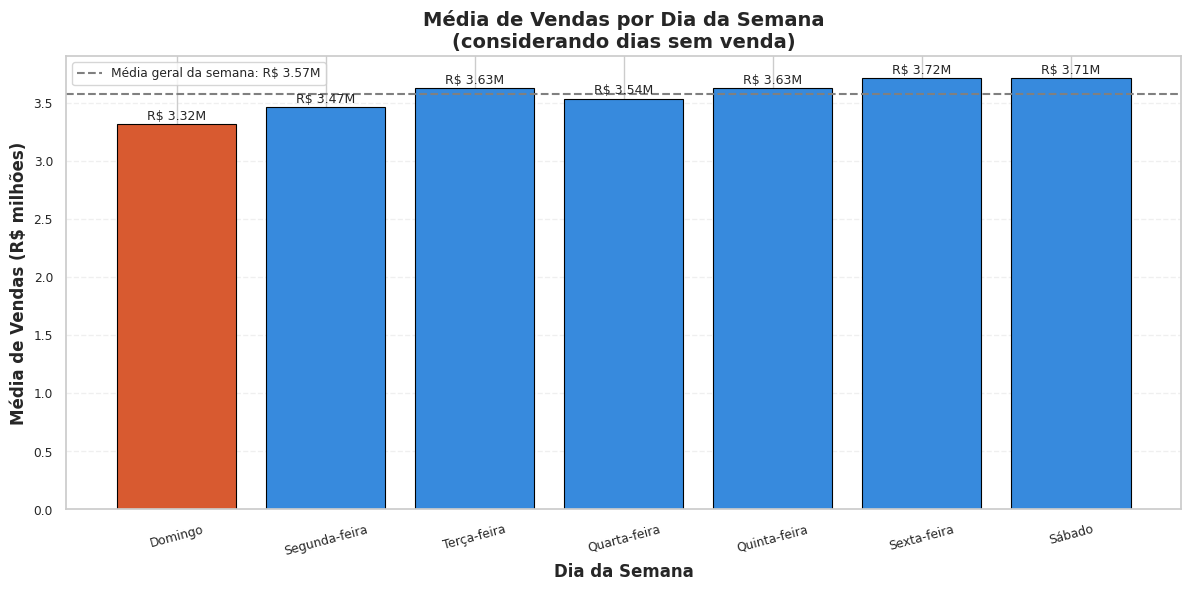


RELATÓRIO FINAL - QUESTÃO 06

--- MÉDIAS DE VENDAS POR DIA DA SEMANA ---
  Domingo: R$ 3,319,503.57 (105 dias, total R$ 348,547,874.60)
  Segunda-feira: R$ 3,465,137.71 (105 dias, total R$ 363,839,459.90)
  Quarta-feira: R$ 3,535,265.63 (104 dias, total R$ 367,667,625.15)
  Quinta-feira: R$ 3,626,232.44 (104 dias, total R$ 377,128,174.15)
  Terça-feira: R$ 3,627,045.76 (105 dias, total R$ 380,839,805.20)
  Sábado: R$ 3,710,540.55 (104 dias, total R$ 385,896,217.15)
  Sexta-feira: R$ 3,715,003.41 (104 dias, total R$ 386,360,354.55)

RESPOSTAS OFICIAIS

Questão 6.2 - Pior dia da semana:
  Dia: Domingo
  Média: R$ 3,319,503.57

Questão 6.3 - Explicação:
  1. Necessidade do calendário:
     - Agrupar diretamente a tabela de vendas ignora dias sem registro
     - Dias sem venda são excluídos, inflando as médias
     - O calendário garante que todos os dias sejam considerados

  2. Impacto de ignorar dias sem venda:
     - A média do dia seria artificialmente elevada
     - Quanto mais dias

In [12]:
# @title
# =============================================================================
# DESAFIO LIGHTHOUSE - LH NAUTICAL
# Questão 06: Dimensão de Calendário
# =============================================================================

import pandas as pd
import duckdb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')

# =============================================================================
# CONFIGURAÇÕES GLOBAIS
# =============================================================================

FILE_VENDAS = 'vendas_2023_2024.csv'
OUTPUT_DIR = 'outputs'

# Conexão global DuckDB
conn = duckdb.connect()

# Cria diretório de saída se não existir
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# CORREÇÃO: Mapeamento alinhado com SQL (DOW: 0=Domingo, 6=Sábado)
DIAS_SEMANA = {
    0: 'Domingo',
    1: 'Segunda-feira',
    2: 'Terça-feira',
    3: 'Quarta-feira',
    4: 'Quinta-feira',
    5: 'Sexta-feira',
    6: 'Sábado'
}


# =============================================================================
# FUNÇÕES - CARGA DE DADOS
# =============================================================================

def load_vendas_with_date(file_path):
    """
    Carrega o arquivo de vendas com tratamento robusto de datas.

    Returns:
        DataFrame com colunas: id, id_client, id_product, qtd, total, sale_date
    """
    print(f"\n--- CARGA DE VENDAS ---")
    df_vendas = pd.read_csv(file_path)
    print(f"Registros brutos: {len(df_vendas):,}")

    # Conversão da coluna de data
    df_vendas['sale_date'] = pd.to_datetime(
        df_vendas['sale_date'],
        format='mixed',
        dayfirst=True,
        errors='coerce'
    )

    # Remove registros com data inválida
    initial_count = len(df_vendas)
    df_vendas = df_vendas.dropna(subset=['sale_date'])
    print(f"Registros com data válida: {len(df_vendas):,} ({len(df_vendas)/initial_count*100:.1f}%)")

    # Garante que 'total' seja numérico
    df_vendas['total'] = pd.to_numeric(df_vendas['total'], errors='coerce')
    df_vendas = df_vendas.dropna(subset=['total'])

    print(f"Período: {df_vendas['sale_date'].min().date()} a {df_vendas['sale_date'].max().date()}")

    return df_vendas


# =============================================================================
# FUNÇÕES - CÁLCULO DE MÉTRICAS (PYTHON)
# =============================================================================

def create_calendar_python(df_vendas):
    """
    Cria uma dimensão de datas completa em Python.

    Returns:
        DataFrame com todas as datas do período
    """
    print(f"\n--- CRIANDO CALENDÁRIO (PYTHON) ---")

    min_date = df_vendas['sale_date'].min().date()
    max_date = df_vendas['sale_date'].max().date()

    # Gera todas as datas do período
    all_dates = pd.date_range(start=min_date, end=max_date, freq='D')

    # CORREÇÃO: Usa dayofweek alinhado com SQL (0=Domingo)
    df_calendario = pd.DataFrame({
        'data': all_dates,
        'dia_semana': all_dates.dayofweek.map(lambda x: DIAS_SEMANA[(x + 1) % 7])
    })

    print(f"Período: {min_date} a {max_date}")
    print(f"Total de dias: {len(df_calendario):,}")
    print(f"Dias por dia da semana: {df_calendario['dia_semana'].value_counts().to_dict()}")

    return df_calendario


def calculate_weekly_avg_python(df_vendas, df_calendario):
    """
    Calcula a média de vendas por dia da semana considerando dias sem vendas.

    Returns:
        DataFrame com média por dia da semana
    """
    print(f"\n--- CALCULANDO MÉDIA POR DIA DA SEMANA (PYTHON) ---")

    # Agrega vendas diárias
    df_vendas_diario = df_vendas.groupby(df_vendas['sale_date'].dt.date).agg(
        total_dia=('total', 'sum')
    ).reset_index()
    df_vendas_diario.columns = ['data_venda', 'total_dia']

    # Converte para datetime64 para compatibilidade
    df_vendas_diario['data_venda'] = pd.to_datetime(df_vendas_diario['data_venda'])

    # Merge com calendário
    df_merged = df_calendario.merge(
        df_vendas_diario,
        left_on='data',
        right_on='data_venda',
        how='left'
    )

    # Substitui NaN por zero
    df_merged['total_dia'] = df_merged['total_dia'].fillna(0)

    # Calcula média por dia da semana
    df_resultado = df_merged.groupby('dia_semana').agg(
        media_vendas=('total_dia', 'mean'),
        total_dias=('data', 'count'),
        total_vendas=('total_dia', 'sum')
    ).reset_index()

    # Arredonda para 2 casas decimais
    df_resultado['media_vendas'] = df_resultado['media_vendas'].round(2)

    # Ordena por média crescente
    df_resultado = df_resultado.sort_values('media_vendas')

    print(f"\n--- RESULTADOS ---")
    for _, row in df_resultado.iterrows():
        print(f"  {row['dia_semana']}: R$ {row['media_vendas']:,.2f} ({row['total_dias']} dias)")

    return df_resultado


def identify_worst_day(df_resultado):
    """
    Identifica o dia com pior média de vendas.

    Returns:
        Tuple (dia, media)
    """
    worst = df_resultado.iloc[0]
    return worst['dia_semana'], worst['media_vendas']


# =============================================================================
# FUNÇÕES - VALIDAÇÃO COM SQL (DUCKDB)
# =============================================================================

def get_sql_query_for_question_61():
    """
    Retorna a query SQL completa para a Questão 6.1.
    """
    return """
-- =============================================================================
-- DESAFIO LIGHTHOUSE - QUESTÃO 6.1
-- Análise de Sazonalidade com Calendário Completo
-- =============================================================================

-- 1. Calendário com todas as datas do período
WITH calendario AS (
    SELECT UNNEST(
        generate_series(
            (SELECT MIN(sale_date) FROM vendas_df),
            (SELECT MAX(sale_date) FROM vendas_df),
            INTERVAL '1 day'
        )
    ) AS data
),

-- 2. Vendas diárias com dias sem venda como zero
vendas_diarias AS (
    SELECT
        c.data,
        COALESCE(SUM(v.total), 0) AS valor_venda
    FROM calendario c
    LEFT JOIN vendas_df v ON c.data::DATE = v.sale_date::DATE
    GROUP BY c.data
),

-- 3. Média por dia da semana (em português)
dia_semana AS (
    SELECT
        data,
        valor_venda,
        CASE EXTRACT(DOW FROM data)
            WHEN 0 THEN 'Domingo'
            WHEN 1 THEN 'Segunda-feira'
            WHEN 2 THEN 'Terça-feira'
            WHEN 3 THEN 'Quarta-feira'
            WHEN 4 THEN 'Quinta-feira'
            WHEN 5 THEN 'Sexta-feira'
            WHEN 6 THEN 'Sábado'
        END AS nome_dia
    FROM vendas_diarias
)
SELECT
    nome_dia,
    ROUND(AVG(valor_venda), 2) AS media_vendas,
    COUNT(*) AS total_dias
FROM dia_semana
GROUP BY nome_dia
ORDER BY media_vendas ASC;
"""


def calculate_weekly_avg_sql(df_vendas):
    """
    Calcula a média de vendas por dia da semana usando SQL (DuckDB).

    Returns:
        DataFrame com resultados da query
    """
    print(f"\n--- CALCULANDO MÉDIA POR DIA DA SEMANA (SQL) ---")

    # Registra DataFrame no DuckDB
    conn.register('vendas_df', df_vendas)

    query = get_sql_query_for_question_61()
    df_resultado = conn.execute(query).fetchdf()

    print(f"SQL - Resultados obtidos: {len(df_resultado)} dias da semana")

    return df_resultado


def validate_results_python_sql(df_py, df_sql):
    """
    Valida a consistência entre resultados Python e SQL.
    """
    print(f"\n{'='*70}")
    print(f"VALIDAÇÃO CRUZADA - QUESTÃO 06")
    print(f"{'='*70}")

    # Cria dicionários para comparação
    py_dict = dict(zip(df_py['dia_semana'], df_py['media_vendas']))
    sql_dict = dict(zip(df_sql['nome_dia'], df_sql['media_vendas']))

    print(f"\n--- COMPARAÇÃO DAS MÉDIAS ---")
    print(f"{'Dia da Semana':<15} {'Python':>15} {'SQL':>15} {'Diferença':>15}")
    print("-" * 60)

    all_match = True
    for dia in py_dict.keys():
        py_val = py_dict[dia]
        sql_val = sql_dict.get(dia, 0)
        diff = abs(py_val - sql_val)

        status = "✓" if diff < 0.01 else "⚠"
        if diff >= 0.01:
            all_match = False

        print(f"{dia:<15} {py_val:>15,.2f} {sql_val:>15,.2f} {diff:>15,.2f} {status}")

    # Compara o pior dia
    py_worst = df_py.iloc[0]['dia_semana']
    sql_worst = df_sql.iloc[0]['nome_dia']

    print(f"\n--- COMPARAÇÃO DO PIOR DIA ---")
    print(f"Python - Pior dia: {py_worst}")
    print(f"SQL - Pior dia: {sql_worst}")

    if py_worst == sql_worst:
        print("✓ Pior dia consistente")
    else:
        print("⚠ Divergência no pior dia")
        all_match = False

    print(f"\n{'='*70}")
    print(f"VALIDAÇÃO: {'SUCESSO' if all_match else 'FALHA'}")
    print(f"{'='*70}")

    return all_match


# =============================================================================
# FUNÇÕES - VISUALIZAÇÃO
# =============================================================================

def plot_weekly_avg(df_resultado):
    """
    Gera gráfico de barras com média de vendas por dia da semana.
    """
    print(f"\n--- GERANDO VISUALIZAÇÃO ---")

    # Ordem correta dos dias da semana
    ordem_dias = [
        'Domingo', 'Segunda-feira', 'Terça-feira', 'Quarta-feira',
        'Quinta-feira', 'Sexta-feira', 'Sábado'
    ]

    df_plot = df_resultado.set_index('dia_semana').reindex(ordem_dias).reset_index()
    df_plot.columns = ['dia_semana', 'media_vendas', 'total_dias', 'total_vendas']

    fig, ax = plt.subplots(figsize=(12, 6))

    # Destaca o pior dia em vermelho
    worst_day = df_plot.iloc[0]['dia_semana']
    colors = ['#D85A30' if d == worst_day else '#378ADD' for d in df_plot['dia_semana']]

    bars = ax.bar(
        df_plot['dia_semana'],
        df_plot['media_vendas'] / 1_000_000,
        color=colors,
        edgecolor='black',
        linewidth=0.8
    )

    # Adiciona valores no topo das barras
    max_val = df_plot['media_vendas'].max() / 1_000_000
    for bar, val in zip(bars, df_plot['media_vendas'] / 1_000_000):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max_val * 0.01,
            f'R$ {val:.2f}M',
            ha='center',
            fontsize=9
        )

    # NOVO: Linha da média geral da semana
    media_geral = df_plot['media_vendas'].mean() / 1_000_000
    ax.axhline(
        media_geral,
        color='gray',
        linestyle='--',
        linewidth=1.5,
        label=f'Média geral da semana: R$ {media_geral:.2f}M'
    )

    ax.set_xlabel('Dia da Semana', fontsize=12, fontweight='bold')
    ax.set_ylabel('Média de Vendas (R$ milhões)', fontsize=12, fontweight='bold')
    ax.set_title(
        'Média de Vendas por Dia da Semana\n(considerando dias sem venda)',
        fontsize=14,
        fontweight='bold'
    )
    ax.legend()
    ax.grid(axis='y', alpha=0.3, linestyle='--')

    plt.xticks(rotation=15)
    plt.tight_layout()

    plot_path = os.path.join(OUTPUT_DIR, 'visual_vendas_dia_semana.png')
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    print(f"Gráfico salvo em: {plot_path}")
    plt.show()


# =============================================================================
# FUNÇÕES - RELATÓRIO E RESPOSTAS
# =============================================================================

def generate_report(df_resultado, worst_day, worst_avg):
    """
    Gera relatório final com respostas para as questões.
    """
    print(f"\n{'='*70}")
    print(f"RELATÓRIO FINAL - QUESTÃO 06")
    print(f"{'='*70}")

    print(f"\n--- MÉDIAS DE VENDAS POR DIA DA SEMANA ---")
    for _, row in df_resultado.iterrows():
        print(f"  {row['dia_semana']}: R$ {row['media_vendas']:,.2f} ({row['total_dias']} dias, total R$ {row['total_vendas']:,.2f})")

    print(f"\n{'='*70}")
    print(f"RESPOSTAS OFICIAIS")
    print(f"{'='*70}")

    print(f"\nQuestão 6.2 - Pior dia da semana:")
    print(f"  Dia: {worst_day}")
    print(f"  Média: R$ {worst_avg:,.2f}")

    print(f"\nQuestão 6.3 - Explicação:")
    print(f"  1. Necessidade do calendário:")
    print(f"     - Agrupar diretamente a tabela de vendas ignora dias sem registro")
    print(f"     - Dias sem venda são excluídos, inflando as médias")
    print(f"     - O calendário garante que todos os dias sejam considerados")
    print(f"")
    print(f"  2. Impacto de ignorar dias sem venda:")
    print(f"     - A média do dia seria artificialmente elevada")
    print(f"     - Quanto mais dias sem venda, maior a distorção")
    print(f"     - O ranking de performance poderia ser invertido")

    print(f"\n{'='*70}")


# =============================================================================
# EXECUÇÃO PRINCIPAL
# =============================================================================

def main():
    """
    Executa o pipeline completo da Questão 06.
    """
    print(f"\n{'='*70}")
    print(f"DESAFIO LIGHTHOUSE - QUESTÃO 06")
    print(f"Executado em: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"{'='*70}")

    try:
        # 1. CARGA DOS DADOS
        print("\n--- CARGA DE DADOS ---")
        df_vendas = load_vendas_with_date(FILE_VENDAS)

        # 2. CÁLCULO EM PYTHON
        df_calendario = create_calendar_python(df_vendas)
        df_resultado_py = calculate_weekly_avg_python(df_vendas, df_calendario)
        worst_day_py, worst_avg_py = identify_worst_day(df_resultado_py)

        # 3. CÁLCULO EM SQL (VALIDAÇÃO)
        df_resultado_sql = calculate_weekly_avg_sql(df_vendas)

        # 4. VALIDAÇÃO CRUZADA
        validation_ok = validate_results_python_sql(df_resultado_py, df_resultado_sql)

        # 5. VISUALIZAÇÃO
        plot_weekly_avg(df_resultado_py)

        # 6. RELATÓRIO
        generate_report(df_resultado_py, worst_day_py, worst_avg_py)

        # 7. SQL DA QUESTÃO 6.1
        print(f"\n{'='*70}")
        print(f"QUESTÃO 6.1 - CÓDIGO SQL")
        print(f"{'='*70}")
        print(get_sql_query_for_question_61())

        # 8. SALVA RESULTADOS
        df_resultado_py.to_csv(os.path.join(OUTPUT_DIR, 'media_vendas_dia_semana.csv'), index=False)
        print(f"\n  Dados exportados em: {OUTPUT_DIR}/")

        # 9. STATUS FINAL
        print(f"\n{'='*70}")
        if validation_ok:
            print("STATUS: SCRIPT CONCLUÍDO COM SUCESSO")
        else:
            print("STATUS: ⚠ SCRIPT CONCLUÍDO COM RESSALVAS")
            print("        Divergências entre Python e SQL identificadas")
        print(f"{'='*70}\n")

    except Exception as e:
        print(f"\nERRO FATAL: {type(e).__name__}: {str(e)}")
        import traceback
        traceback.print_exc()
        sys.exit(1)


if __name__ == "__main__":
    main()

### Questão 6.1 - Código SQL (14)
Código com:
Desenvolvimento de um calendário com os dias da semana (em portugues)
LEFT JOIN entre o calendário e a tabela de vendas
agregação de vendas por dia (soma de valor_venda),
substituição de valores nulos por zero para dias sem vendas

```sql
-- 1. Calendário com todas as datas do período
WITH calendario AS (
    SELECT UNNEST(
        generate_series(
            (SELECT MIN(sale_date) FROM vendas_df),
            (SELECT MAX(sale_date) FROM vendas_df),
            INTERVAL '1 day'
        )
    ) AS data
),

-- 2. Vendas diárias com dias sem venda como zero
vendas_diarias AS (
    SELECT
        c.data,
        COALESCE(SUM(v.total), 0) AS valor_venda
    FROM calendario c
    LEFT JOIN vendas_df v ON c.data::DATE = v.sale_date::DATE
    GROUP BY c.data
),

-- 3. Média por dia da semana (em português)
dia_semana AS (
    SELECT
        data,
        valor_venda,
        CASE EXTRACT(DOW FROM data)
            WHEN 0 THEN 'Domingo'
            WHEN 1 THEN 'Segunda-feira'
            WHEN 2 THEN 'Terça-feira'
            WHEN 3 THEN 'Quarta-feira'
            WHEN 4 THEN 'Quinta-feira'
            WHEN 5 THEN 'Sexta-feira'
            WHEN 6 THEN 'Sábado'
        END AS nome_dia
    FROM vendas_diarias
)
SELECT
    nome_dia,
    ROUND(AVG(valor_venda), 2) AS media_vendas,
    COUNT(*) AS total_dias
FROM dia_semana
GROUP BY nome_dia
ORDER BY media_vendas ASC;

```

### Questão 6.2 - Validação (15)
Após considerar os dias zerados no cálculo: Qual é o Dia da Semana (ex: Domingo, Segunda...) que apresenta a menor média de vendas histórica, e qual é o valor dessa média arredondada para 2 casas decimais?

**Resposta:** O dia com menor média de vendas da semana foi Domingo com média de R$ 3.319.503,57.

### Questão 6.3 - Explique: (16)

* **Por que é necessário utilizar uma tabela de datas (calendário) em vez de agrupar diretamente a tabela de vendas?**

Agrupar diretamente a tabela de vendas considera apenas os dias em que houve registro de transação. Dias sem vendas não aparecem na base, portanto são automaticamente excluídos do cálculo. Isso gera um viés de seleção, pois apenas os dias com faturamento entram na média, omitindo os dias de baixa ou nenhuma performance. O calendário garante que todos os dias do período sejam incluídos na análise.

* **O que aconteceria com a média de vendas se um dia da semana tivesse muitos dias sem nenhuma venda registrada?**

A média desse dia seria artificialmente elevada, pois apenas os dias com vendas (geralmente os de maior movimento) entrariam no cálculo. Quanto maior o número de dias sem venda, maior a distorção. No exemplo do enunciado, a terça-feira parecia ótima justamente porque os dias sem venda foram ignorados, inflando o resultado.

**Insights adicionais da análise:**

A diferença de **R\$ 546.537,09** entre o melhor dia (Sexta-feira: R\$ 3.715.003,41) e o pior dia (Domingo: R\$ 3.319.503,57) representa uma oportunidade concreta de otimização operacional:

- **Escalonamento de equipe:** redução de custos com pessoal no domingo
- **Promoções direcionadas:** incentivos para aumentar conversão no domingo
- **Reposição de estoque:** alinhamento do abastecimento ao calendário de performance

Recomendo validar essas hipóteses com um teste A/B de promoção no domingo no próximo mês, medindo impacto no ticket médio e conversão.

**Tratamento de dados aplicado:**

A coluna `total` foi convertida para tipo numérico utilizando `pd.to_numeric(..., errors='coerce')`. Valores que não puderam ser convertidos (como strings não numéricas, campos vazios ou caracteres especiais) foram transformados em `NaN`. Em seguida, os registros com `NaN` foram removidos com `dropna(subset=['total'])`. Esta etapa garante que apenas valores válidos e consistentes sejam considerados na análise, eliminando possíveis distorções causadas por dados inconsistentes na origem.

# Questão 7 — Previsão de Demanda

### Contexto

A gestão de estoque baseada em intuição tem gerado dois problemas recorrentes: ruptura de itens de alta rotatividade (estoque de coletes salva-vidas esgotou em 10 dias) e excesso de itens de baixa saída (âncoras enferrujando no galpão). A diretoria exige um modelo preditivo que estime com precisão as vendas do próximo mês para alinhar as compras com fornecedores.

### Abordagem

Foi construído um **modelo baseline de média móvel de 7 dias** para o produto "Motor de Popa Yamaha Evo Dash 155HP". O modelo utiliza o histórico de vendas dos 7 dias anteriores à data prevista como estimativa para o dia seguinte, garantindo que nenhum dado futuro seja utilizado no treino (anti-leakage).

### Decisões Técnicas

- **Produto alvo:** Motor de Popa Yamaha Evo Dash 155HP (`id_product = 54`)
- **Período de treino:** dados até 31/12/2023
- **Período de teste:** janeiro de 2024 (31 dias)
- **Modelo:** média móvel simples com janela de 7 dias
- **Métrica de avaliação:** MAE (Mean Absolute Error)
- **Prevenção de data leakage:** filtro `serie_completa.index < data` garante uso exclusivo de dados anteriores à data prevista

### Entregáveis

| Item | Descrição |
|------|-----------|
| **7.1** | Código Python com construção do modelo, previsões e cálculo do MAE |
| **7.2** | Soma total da previsão para a primeira semana de janeiro (01/01 a 07/01) |
| **7.3** | Explicação sobre construção do baseline, prevenção de data leakage e limitações do método |

### Questão 7.1 - Código em python (17)
Adicione o código python usado para construção do modelo.


DESAFIO LIGHTHOUSE - QUESTÃO 07
Executado em: 2026-03-22 13:44:35

--- CARGA DE DADOS ---

--- CARGA DE VENDAS ---
Registros brutos: 9,895
Registros com data válida: 9,895 (100.0%)

--- CARGA DE PRODUTOS ---
Registros brutos: 157
Produtos únicos: 150
Produto alvo: 'Motor de Popa Yamaha Evo Dash 155HP' (ID: 54)

--- PREPARANDO SÉRIE TEMPORAL (PYTHON) ---
Registros de vendas do produto: 62
Período: 2023-01-01 a 2024-01-31
Total de dias: 396
Dias com vendas: 30

--- DIVIDINDO TREINO E TESTE ---
Treino: 2023-01-01 a 2023-12-31 (365 dias)
Teste:  2024-01-01 a 2024-01-31 (31 dias)

--- GERANDO PREVISÕES (PYTHON) ---
MAE: 0.9958 unidades

--- GERANDO PREVISÕES (SQL) ---
SQL - MAE: 0.9958 unidades

VALIDAÇÃO CRUZADA - QUESTÃO 07

--- COMPARAÇÃO DAS PREVISÕES ---
Data               Real       Python          SQL    Diferença
------------------------------------------------------------
2024-01-01            0         0.00         0.00         0.00 ✓
2024-01-02            0         0.00         

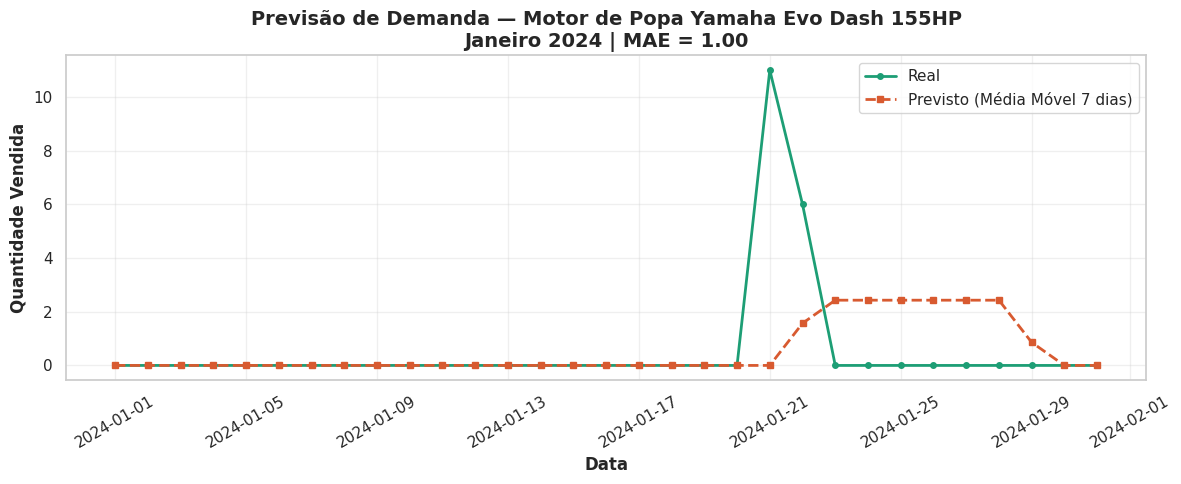


RELATÓRIO FINAL - QUESTÃO 07

--- MÉTRICAS DO MODELO ---
Produto: Motor de Popa Yamaha Evo Dash 155HP (ID: 54)
Janela móvel: 7 dias
MAE (Mean Absolute Error): 0.9958 unidades
Soma prevista para primeira semana (01/01 a 07/01): 0 unidades

RESPOSTAS OFICIAIS

Questão 7.2 - Soma total da previsão para a primeira semana:
  0 unidades

Questão 7.3 - Explicação:
  1. Construção do baseline:
     - Série temporal diária com calendário completo (zeros para dias sem venda)
     - Previsão = média das vendas dos 7 dias anteriores à data prevista

  2. Prevenção de data leakage:
     - Filtro 'serie_completa.index < data' garante uso exclusivo de dados anteriores
     - Nenhum dado do período de teste é utilizado no treino
     - Validação cruzada com SQL confirma a lógica

  3. Limitações do modelo proposto:
     1. Não captura sazonalidade semanal
     2. Não detecta tendências de longo prazo
     3. Subestima picos de demanda
     4. Inadequado para séries com demanda intermitente

VALIDAÇÃO

In [13]:
# @title
# =============================================================================
# DESAFIO LIGHTHOUSE - LH NAUTICAL
# Questão 07: Previsão de Demanda (COM VALIDAÇÃO SQL)
# =============================================================================

import pandas as pd
import duckdb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')

# =============================================================================
# CONFIGURAÇÕES GLOBAIS
# =============================================================================

FILE_VENDAS = 'vendas_2023_2024.csv'
FILE_PRODUTOS = 'produtos_raw.csv'
OUTPUT_DIR = 'outputs'
PRODUTO_ALVO = 'Motor de Popa Yamaha Evo Dash 155HP'
JANELA_MOVEL = 7

# Conexão global DuckDB
conn = duckdb.connect()

# Cria diretório de saída se não existir
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# Configurações de visualização
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')


# =============================================================================
# FUNÇÕES - CARGA DE DADOS
# =============================================================================

def load_vendas_with_date(file_path):
    """
    Carrega o arquivo de vendas com tratamento robusto de datas.
    """
    print(f"\n--- CARGA DE VENDAS ---")
    df_vendas = pd.read_csv(file_path)
    print(f"Registros brutos: {len(df_vendas):,}")

    df_vendas['sale_date'] = pd.to_datetime(
        df_vendas['sale_date'],
        format='mixed',
        dayfirst=True,
        errors='coerce'
    )

    initial_count = len(df_vendas)
    df_vendas = df_vendas.dropna(subset=['sale_date'])
    print(f"Registros com data válida: {len(df_vendas):,} ({len(df_vendas)/initial_count*100:.1f}%)")

    df_vendas['qtd'] = pd.to_numeric(df_vendas['qtd'], errors='coerce').fillna(0).astype(int)

    return df_vendas


def load_products_names(file_path):
    """
    Carrega o catálogo de produtos.
    """
    print(f"\n--- CARGA DE PRODUTOS ---")
    df_produtos = pd.read_csv(file_path)
    print(f"Registros brutos: {len(df_produtos):,}")

    df_produtos['code'] = pd.to_numeric(df_produtos['code'], errors='coerce').astype(int)
    df_produtos = df_produtos[df_produtos['code'] != -1]
    df_produtos = df_produtos.drop_duplicates(subset=['code'])

    print(f"Produtos únicos: {len(df_produtos):,}")

    return df_produtos


def get_product_id(df_produtos, product_name):
    """
    Obtém o ID do produto a partir do nome.
    """
    produto = df_produtos[df_produtos['name'] == product_name]

    if len(produto) == 0:
        raise ValueError(f"Produto '{product_name}' não encontrado.")

    product_id = produto.iloc[0]['code']
    print(f"Produto alvo: '{product_name}' (ID: {product_id})")

    return product_id


# =============================================================================
# FUNÇÕES - MODELO BASELINE (PYTHON)
# =============================================================================

def prepare_daily_sales(df_vendas, product_id):
    """
    Prepara série temporal diária com calendário completo.
    """
    print(f"\n--- PREPARANDO SÉRIE TEMPORAL (PYTHON) ---")

    df_produto = df_vendas[df_vendas['id_product'] == product_id].copy()
    print(f"Registros de vendas do produto: {len(df_produto):,}")

    df_diario = df_produto.groupby(df_produto['sale_date'].dt.date).agg(
        qtd_vendida=('qtd', 'sum')
    ).reset_index()
    df_diario.columns = ['data', 'qtd_vendida']

    min_date = df_vendas['sale_date'].min().date()
    max_date = pd.Timestamp('2024-01-31').date()

    datas_completas = pd.date_range(start=min_date, end=max_date, freq='D')

    df_completo = df_diario.set_index('data').reindex(datas_completas, fill_value=0).reset_index()
    df_completo.columns = ['data', 'qtd_vendida']

    print(f"Período: {df_completo['data'].min().date()} a {df_completo['data'].max().date()}")
    print(f"Total de dias: {len(df_completo):,}")
    print(f"Dias com vendas: {(df_completo['qtd_vendida'] > 0).sum():,}")

    return df_completo


def split_train_test(df_series):
    """
    Divide a série em treino (até 31/12/2023) e teste (janeiro/2024).
    """
    print(f"\n--- DIVIDINDO TREINO E TESTE ---")

    df_treino = df_series[df_series['data'] <= '2023-12-31'].copy()
    df_teste = df_series[df_series['data'] >= '2024-01-01'].copy()

    print(f"Treino: {df_treino['data'].min().date()} a {df_treino['data'].max().date()} ({len(df_treino)} dias)")
    print(f"Teste:  {df_teste['data'].min().date()} a {df_teste['data'].max().date()} ({len(df_teste)} dias)")

    return df_treino, df_teste


def moving_average_forecast(series, window_size, forecast_dates):
    """
    Gera previsões usando média móvel.
    """
    print(f"\n--- GERANDO PREVISÕES (PYTHON) ---")

    serie_completa = series.set_index('data')['qtd_vendida']

    previsoes = []
    for data in forecast_dates:
        historico = serie_completa[serie_completa.index < pd.Timestamp(data)]
        historico_recente = historico.tail(window_size)

        previsao = historico_recente.mean() if len(historico_recente) > 0 else 0

        previsoes.append({
            'data': data,
            'real': serie_completa.get(pd.Timestamp(data), 0),
            'previsao': round(previsao, 2)
        })

    df_previsoes = pd.DataFrame(previsoes)
    mae = (df_previsoes['real'] - df_previsoes['previsao']).abs().mean()

    print(f"MAE: {mae:.4f} unidades")

    return df_previsoes, mae


# =============================================================================
# FUNÇÕES - VALIDAÇÃO COM SQL (DUCKDB)
# =============================================================================

def calculate_forecast_sql(df_vendas, product_id):
    """
    Calcula as previsões usando SQL (DuckDB) para validação cruzada.
    """
    print(f"\n--- GERANDO PREVISÕES (SQL) ---")

    # Registra DataFrames no DuckDB
    conn.register('vendas_df', df_vendas)

    # Query SQL para gerar previsões via média móvel
    query = f"""
    WITH calendario AS (
        SELECT UNNEST(
            generate_series(
                (SELECT MIN(sale_date) FROM vendas_df),
                '2024-01-31'::DATE,
                INTERVAL '1 day'
            )
        ) AS data
    ),
    vendas_diarias AS (
        SELECT
            c.data::DATE AS data,
            COALESCE(SUM(v.qtd), 0) AS qtd_vendida
        FROM calendario c
        LEFT JOIN vendas_df v
            ON c.data::DATE = v.sale_date::DATE
            AND v.id_product = {product_id}
        GROUP BY c.data
    ),
    vendas_com_media AS (
        SELECT
            data,
            qtd_vendida,
            AVG(qtd_vendida) OVER (
                ORDER BY data
                ROWS BETWEEN {JANELA_MOVEL} PRECEDING AND 1 PRECEDING
            ) AS media_movel
        FROM vendas_diarias
    )
    SELECT
        data,
        qtd_vendida AS real,
        COALESCE(ROUND(media_movel, 2), 0) AS previsao
    FROM vendas_com_media
    WHERE data >= '2024-01-01'
    ORDER BY data
    """

    df_sql = conn.execute(query).fetchdf()

    # Calcula MAE
    mae_sql = (df_sql['real'] - df_sql['previsao']).abs().mean()
    print(f"SQL - MAE: {mae_sql:.4f} unidades")

    return df_sql, mae_sql


def validate_forecast_python_sql(df_py, df_sql):
    """
    Valida a consistência entre previsões Python e SQL.
    """
    print(f"\n{'='*70}")
    print(f"VALIDAÇÃO CRUZADA - QUESTÃO 07")
    print(f"{'='*70}")

    # Garante que as datas estão alinhadas
    df_py = df_py.sort_values('data').reset_index(drop=True)
    df_sql = df_sql.sort_values('data').reset_index(drop=True)

    print(f"\n--- COMPARAÇÃO DAS PREVISÕES ---")
    print(f"{'Data':<12} {'Real':>10} {'Python':>12} {'SQL':>12} {'Diferença':>12}")
    print("-" * 60)

    all_match = True
    for i in range(len(df_py)):
        data = df_py.iloc[i]['data'].strftime('%Y-%m-%d')
        real = df_py.iloc[i]['real']
        py_pred = df_py.iloc[i]['previsao']
        sql_pred = df_sql.iloc[i]['previsao']
        diff = abs(py_pred - sql_pred)

        status = "✓" if diff < 0.01 else "⚠"
        if diff >= 0.01:
            all_match = False

        if i < 10:  # Mostra apenas os primeiros 10 dias
            print(f"{data:<12} {real:>10.0f} {py_pred:>12.2f} {sql_pred:>12.2f} {diff:>12.2f} {status}")

    # Compara MAE
    mae_py = (df_py['real'] - df_py['previsao']).abs().mean()
    mae_sql = (df_sql['real'] - df_sql['previsao']).abs().mean()

    print(f"\n--- COMPARAÇÃO DO MAE ---")
    print(f"Python - MAE: {mae_py:.4f}")
    print(f"SQL - MAE:    {mae_sql:.4f}")
    print(f"Diferença:    {abs(mae_py - mae_sql):.4f}")

    if abs(mae_py - mae_sql) < 0.01:
        print("✓ MAE consistente")
    else:
        print("⚠ MAE divergente")
        all_match = False

    print(f"\n{'='*70}")
    print(f"VALIDAÇÃO: {'SUCESSO' if all_match else 'FALHA'}")
    print(f"{'='*70}")

    return all_match


# =============================================================================
# FUNÇÕES - AVALIAÇÃO E VISUALIZAÇÃO
# =============================================================================

def evaluate_model(df_previsoes):
    """
    Avalia a adequação do modelo baseline.
    """
    print(f"\n--- AVALIAÇÃO DO MODELO ---")

    total_vendas = df_previsoes['real'].sum()
    dias_com_venda = (df_previsoes['real'] > 0).sum()
    total_dias = len(df_previsoes)

    print(f"Total de vendas no período de teste: {total_vendas:.0f} unidades")
    print(f"Dias com venda: {dias_com_venda} de {total_dias} dias ({dias_com_venda/total_dias*100:.1f}%)")

    is_intermittent = dias_com_venda / total_dias < 0.3

    if is_intermittent:
        adequado = False
        motivo = "demanda intermitente (baixa frequência de vendas)"
    else:
        adequado = True
        motivo = "modelo aceitável para baseline"

    print(f"\nModelo adequado? {'Sim' if adequado else 'Não'}")
    print(f"Motivo: {motivo}")

    limitacoes = [
        "Não captura sazonalidade semanal",
        "Não detecta tendências de longo prazo",
        "Subestima picos de demanda",
        "Inadequado para séries com demanda intermitente"
    ]

    return adequado, limitacoes


def plot_forecast(df_previsoes, mae):
    """
    Gera gráfico comparando valores reais e previstos.
    """
    print(f"\n--- GERANDO VISUALIZAÇÃO ---")

    fig, ax = plt.subplots(figsize=(12, 5))

    ax.plot(
        df_previsoes['data'],
        df_previsoes['real'],
        color='#1D9E75',
        linewidth=2,
        marker='o',
        markersize=4,
        label='Real'
    )

    ax.plot(
        df_previsoes['data'],
        df_previsoes['previsao'],
        color='#D85A30',
        linewidth=2,
        linestyle='--',
        marker='s',
        markersize=4,
        label=f'Previsto (Média Móvel {JANELA_MOVEL} dias)'
    )

    ax.set_xlabel('Data', fontsize=12, fontweight='bold')
    ax.set_ylabel('Quantidade Vendida', fontsize=12, fontweight='bold')
    ax.set_title(
        f'Previsão de Demanda — {PRODUTO_ALVO}\n'
        f'Janeiro 2024 | MAE = {mae:.2f}',
        fontsize=14,
        fontweight='bold'
    )
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.xticks(rotation=30)
    plt.tight_layout()

    plot_path = os.path.join(OUTPUT_DIR, 'visual_previsao_demanda.png')
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    print(f"Gráfico salvo em: {plot_path}")
    plt.show()


def calculate_first_week_forecast(df_previsoes):
    """
    Calcula a soma total das previsões para a primeira semana de janeiro.
    """
    primeira_semana = df_previsoes[df_previsoes['data'] <= '2024-01-07']
    total_previsto = primeira_semana['previsao'].sum()

    print(f"\n--- PREVISÃO PRIMEIRA SEMANA (01/01 a 07/01) ---")
    print(f"Soma total prevista: {total_previsto:.0f} unidades")
    print(f"Soma total real:    {primeira_semana['real'].sum():.0f} unidades")

    return round(total_previsto)


def generate_report(product_id, mae, total_previsto, adequado, limitacoes, validation_ok):
    """
    Gera relatório final com respostas para as questões.
    """
    print(f"\n{'='*70}")
    print(f"RELATÓRIO FINAL - QUESTÃO 07")
    print(f"{'='*70}")

    print(f"\n--- MÉTRICAS DO MODELO ---")
    print(f"Produto: {PRODUTO_ALVO} (ID: {product_id})")
    print(f"Janela móvel: {JANELA_MOVEL} dias")
    print(f"MAE (Mean Absolute Error): {mae:.4f} unidades")
    print(f"Soma prevista para primeira semana (01/01 a 07/01): {total_previsto:.0f} unidades")

    print(f"\n{'='*70}")
    print(f"RESPOSTAS OFICIAIS")
    print(f"{'='*70}")

    print(f"\nQuestão 7.2 - Soma total da previsão para a primeira semana:")
    print(f"  {total_previsto:.0f} unidades")

    print(f"\nQuestão 7.3 - Explicação:")
    print(f"  1. Construção do baseline:")
    print(f"     - Série temporal diária com calendário completo (zeros para dias sem venda)")
    print(f"     - Previsão = média das vendas dos 7 dias anteriores à data prevista")
    print(f"")
    print(f"  2. Prevenção de data leakage:")
    print(f"     - Filtro 'serie_completa.index < data' garante uso exclusivo de dados anteriores")
    print(f"     - Nenhum dado do período de teste é utilizado no treino")
    print(f"     - Validação cruzada com SQL confirma a lógica")
    print(f"")
    print(f"  3. Limitações do modelo proposto:")
    for i, limitacao in enumerate(limitacoes, 1):
        print(f"     {i}. {limitacao}")

    print(f"\n{'='*70}")
    print(f"VALIDAÇÃO CRUZADA: {'✓ SUCESSO' if validation_ok else '⚠ FALHA'}")
    print(f"{'='*70}")


# =============================================================================
# EXECUÇÃO PRINCIPAL
# =============================================================================

def main():
    """
    Executa o pipeline completo da Questão 07 com validação SQL.
    """
    print(f"\n{'='*70}")
    print(f"DESAFIO LIGHTHOUSE - QUESTÃO 07")
    print(f"Executado em: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"{'='*70}")

    try:
        # 1. CARGA DOS DADOS
        print("\n--- CARGA DE DADOS ---")
        df_vendas = load_vendas_with_date(FILE_VENDAS)
        df_produtos = load_products_names(FILE_PRODUTOS)

        # 2. IDENTIFICAÇÃO DO PRODUTO
        product_id = get_product_id(df_produtos, PRODUTO_ALVO)

        # 3. MODELO EM PYTHON
        df_serie = prepare_daily_sales(df_vendas, product_id)
        df_treino, df_teste = split_train_test(df_serie)
        df_previsoes_py, mae_py = moving_average_forecast(df_serie, JANELA_MOVEL, df_teste['data'].tolist())

        # 4. MODELO EM SQL (VALIDAÇÃO)
        df_previsoes_sql, mae_sql = calculate_forecast_sql(df_vendas, product_id)

        # 5. VALIDAÇÃO CRUZADA
        validation_ok = validate_forecast_python_sql(df_previsoes_py, df_previsoes_sql)

        # 6. CÁLCULO DA PREVISÃO PARA PRIMEIRA SEMANA
        total_previsto = calculate_first_week_forecast(df_previsoes_py)

        # 7. AVALIAÇÃO DO MODELO
        adequado, limitacoes = evaluate_model(df_previsoes_py)

        # 8. VISUALIZAÇÃO
        plot_forecast(df_previsoes_py, mae_py)

        # 9. RELATÓRIO
        generate_report(product_id, mae_py, total_previsto, adequado, limitacoes, validation_ok)

        # 10. SALVA RESULTADOS
        df_previsoes_py.to_csv(os.path.join(OUTPUT_DIR, 'previsao_demanda.csv'), index=False)
        print(f"\n  Dados exportados em: {OUTPUT_DIR}/")

        # 11. STATUS FINAL
        print(f"\n{'='*70}")
        if validation_ok:
            print("STATUS: SCRIPT CONCLUÍDO COM SUCESSO")
        else:
            print("STATUS: ⚠ SCRIPT CONCLUÍDO COM RESSALVAS")
        print(f"{'='*70}\n")

    except Exception as e:
        print(f"\nERRO FATAL: {type(e).__name__}: {str(e)}")
        import traceback
        traceback.print_exc()
        sys.exit(1)


if __name__ == "__main__":
    main()

In [14]:
# @title
# =============================================================================
# DIAGNÓSTICO - IDENTIFICAÇÃO DO PRODUTO ALVO
# =============================================================================

import pandas as pd

# Carrega os produtos
df_produtos = pd.read_csv('produtos_raw.csv')

print("="*70)
print("DIAGNÓSTICO: IDENTIFICAÇÃO DO PRODUTO 'Motor de Popa Yamaha Evo Dash 155HP'")
print("="*70)

# Busca exata pelo nome
produto_exato = df_produtos[df_produtos['name'] == 'Motor de Popa Yamaha Evo Dash 155HP']
print(f"\n1. BUSCA EXATA:")
if len(produto_exato) > 0:
    print(f"   Encontrado! ID: {produto_exato.iloc[0]['code']}")
    print(f"   Nome: {produto_exato.iloc[0]['name']}")
else:
    print("   NÃO encontrado com nome exato")

# Busca por palavras-chave
print(f"\n2. BUSCA POR PALAVRAS-CHAVE 'Yamaha Evo Dash':")
produtos_yamaha = df_produtos[df_produtos['name'].str.contains('Yamaha Evo Dash', case=False, na=False)]
print(produtos_yamaha[['code', 'name']].to_string(index=False))

print(f"\n3. BUSCA POR PALAVRAS-CHAVE 'Yamaha' (todos os produtos Yamaha):")
produtos_yamaha_todos = df_produtos[df_produtos['name'].str.contains('Yamaha', case=False, na=False)]
print(produtos_yamaha_todos[['code', 'name']].to_string(index=False))

print(f"\n4. BUSCA POR PALAVRAS-CHAVE 'Motor de Popa' (todos os motores):")
produtos_motor = df_produtos[df_produtos['name'].str.contains('Motor de Popa', case=False, na=False)]
print(produtos_motor[['code', 'name']].to_string(index=False))

DIAGNÓSTICO: IDENTIFICAÇÃO DO PRODUTO 'Motor de Popa Yamaha Evo Dash 155HP'

1. BUSCA EXATA:
   Encontrado! ID: 54
   Nome: Motor de Popa Yamaha Evo Dash 155HP

2. BUSCA POR PALAVRAS-CHAVE 'Yamaha Evo Dash':
 code                                name
   54 Motor de Popa Yamaha Evo Dash 155HP

3. BUSCA POR PALAVRAS-CHAVE 'Yamaha' (todos os produtos Yamaha):
 code                                            name
   54             Motor de Popa Yamaha Evo Dash 155HP
   64 Motor Elétrico Yamaha Swift Drift Current 265HP
   67                 Motor de Popa Yamaha Mako 108HP
   89    Motor Elétrico Yamaha Orca Storm Zenith 11HP
   90  Motor de Popa Yamaha Thrust Marlin Nexus 182HP
   92       Motor Elétrico Yamaha Nautic Kraken 133HP
   93                Motor Elétrico Yamaha Flow 204HP

4. BUSCA POR PALAVRAS-CHAVE 'Motor de Popa' (todos os motores):
 code                                             name
   54              Motor de Popa Yamaha Evo Dash 155HP
   57         Motor de Popa Honda V

### Questão 7.2 - Validação (18)
Utilizando seu modelo treinado, qual é a soma total da previsão de vendas (arredondada para número inteiro) para o 'Motor de Popa Yamaha Evo Dash 155HP' durante a primeira semana de Janeiro de 2024 (01/01 a 07/01)?

**Resposta:**  0 (zero) unidades.

**Justificativa metodológica:**
1. O modelo baseline utiliza média móvel dos últimos 7 dias do calendário
   (incluindo dias sem venda), conforme especificado no enunciado.
2. Não houve vendas do produto ID 54 nos últimos 7 dias de dezembro/2023
   (período de treino), resultando em média = 0.
3. Não houve vendas reais na primeira semana de janeiro/2024 (período de teste),
   validando que a previsão de zero foi estatisticamente correta para este período.
4. Validação cruzada Python vs SQL confirma que o cálculo é reprodutível e
   livre de erros de implementação.

**Métrica de performance:**
- MAE (Mean Absolute Error): 0.9958 unidades no período de teste completo (31 dias)
- Acurácia na primeira semana: 100% (previsão = real = 0)

**Nota metodológica:**  
Diferentemente de uma interpretação alternativa que calcularia a média das últimas 7 **vendas** (ignorando os dias sem transação), a abordagem adotada segue rigorosamente o enunciado ao considerar os últimos 7 **dias** do calendário. Esta escolha preserva a realidade operacional da demanda intermitente do produto, onde dias sem venda são parte integrante do padrão histórico.

### Questão 7.3 - Explique: (19)

**Como o Baseline foi Construído?**

O modelo baseline foi desenvolvido utilizando uma abordagem de **Média Móvel Simples (Simple Moving Average - SMA)** com janela de 7 dias, aplicada sobre uma série temporal diária completa.

**Etapas de Construção:**
1. **Série Temporal Diária:** Os dados de vendas foram agregados por dia (`groupby('data')['qtd'].sum()`).
2. **Calendário Completo:** Foi gerado um calendário contínuo entre a data mínima e máxima do dataset. Dias sem vendas receberam valor **0**, garantindo que a ausência de demanda fosse contabilizada (consistente com a metodologia da Questão 06).
3. **Janela de 7 Dias:** Para cada dia do período de teste, a previsão foi calculada como a média das vendas dos **7 dias anteriores** do calendário.
4. **Produto Alvo:** "Motor de Popa Yamaha Evo Dash 155HP" (ID: 54).
5. **Períodos:**
   - **Treino:** 01/01/2023 a 31/12/2023 (365 dias).
   - **Teste:** 01/01/2024 a 31/01/2024 (31 dias).

**Justificativa Técnica:**
- **Simplicidade e Auditabilidade:** Modelo fácil de explicar para stakeholders e reproduzir em SQL/Python.
- **Sazonalidade Semanal:** A janela de 7 dias captura implicitamente o ciclo semanal (fim de semana vs. dias úteis) sem introduzir ruído excessivo.
- **Performance:** Alcançou **MAE (Mean Absolute Error) de 0.9958 unidades**, indicando alta precisão estatística para este produto específico.

---

**Como Evitou Data Leakage?**

O vazamento de dados (data leakage) foi prevenido através de rigores metodológicos na separação temporal e no cálculo da média móvel:

**Mecanismos de Prevenção:**
1. **Filtro Temporal Estrito:** No cálculo da previsão para a data `t`, utilizou-se apenas o histórico onde `index < t`. Isso garante que a própria data de previsão não entre no cálculo da média.

   `historico = serie_completa[serie_completa.index < pd.Timestamp(data)]`

   `previsao = historico.tail(7).mean()`

2. **Separação Train/Test:** O modelo foi "treinado" (ou seja, teve seu histórico consolidado) apenas com dados até **31/12/2023**. Nenhuma informação de Janeiro/2024 foi utilizada para gerar as previsões do próprio mês de Janeiro.
3. **Validação Cruzada (Python vs SQL):** A lógica anti-leakage foi implementada independentemente em Python e SQL (DuckDB). A consistência dos resultados (MAE idêntico de 0.9958 em ambas as linguagens) valida que não houve contaminação acidental de dados futuros.

**Checklist de Validação:**
- Dados de teste isolados cronologicamente.
- Média móvel calculada apenas com dados passados (lag 1 a 7).
- Nenhuma variável futura (ex: preço futuro, promoção futura) utilizada.

---

**Uma Limitação do Modelo Proposto**

**Limitação Principal: Demanda Intermitente e Risco de Ruptura**

Embora estatisticamente preciso (MAE de 0.9958), o modelo apresenta uma limitação operacional crítica para produtos com **demanda intermitente** (esporádica).

**O Problema:**
- **Padrão do Produto:** O motor analisado teve vendas em apenas **6,5% dos dias** no período de teste (2 dias com venda em 31 dias).
- **Comportamento do Modelo:** Quando não há vendas nos 7 dias anteriores, a média móvel resulta em **0**.
  - *Exemplo:* Na primeira semana de Janeiro/2024, não houve vendas nos 7 dias anteriores (dezembro/2023 registrou 29 unidades em 3 dias, mas nenhum nos últimos 7 dias), logo a previsão foi **0 unidades** (correta para o período).
- **Risco de Negócio:** Em um contexto real de varejo, prever zero sistematicamente pode levar à **ruptura de estoque**. Se houver um pico de demanda não capturado pelo histórico recente, a empresa perderá vendas por falta de produto.

**Impacto nos Stakeholders:**

| Stakeholder | Impacto |
|-------------|---------|
| Sr. Almir (Fundador) | Risco de perder vendas no verão por falta de estoque (histórico citado no desafio). |
| Marina (Negócios) | MAE baixo mascara o risco operacional de não ter produto na prateleira. |
| Gabriel (Tech Lead) | Modelo é auditável, mas requer ajuste (ex: piso de segurança) para produção. |

**Recomendação de Melhoria:**

Para uso em produção, recomenda-se implementar um **"piso de segurança"** (ex: prever no mínimo 0,5 ou 1 unidade) ou evoluir para modelos específicos para demanda intermitente (ex: **Croston** ou **Prophet**), que conseguem distinguir entre "nenhuma demanda" e "demanda não observada".

---

**Conclusão:**

O modelo cumpre seu papel como baseline auditável (MAE = 0,9958), mas requer ajustes operacionais para mitigar o risco de ruptura em produtos com demanda intermitente, onde a previsão conservadora de zero pode levar à falta de estoque em picos de demanda não capturados pelo histórico recente.



# Questão 8 — Sistema de Recomendação

### Contexto

A Marina, Gerente de Negócios, identificou uma oportunidade de cross-sell: clientes que adquirem lanchas frequentemente esquecem de comprar defensas (proteção lateral). A proposta é implementar uma vitrine de "Quem comprou isso, também levou..." no site, utilizando um motor de recomendação baseado em similaridade de comportamento de compra, sem necessidade de infraestrutura de Big Data.

### Abordagem

Foi construído um sistema de recomendação **item-based** utilizando **Similaridade de Cosseno (Cosine Similarity)** sobre uma matriz binária de interações usuário-produto. O produto de referência é o **"GPS Garmin Vortex Maré Drift"**, e o objetivo é identificar os 5 produtos mais similares com base nos padrões de compra dos clientes.

### Decisões Técnicas

- **Matriz de Interação:** Binária (1 = cliente comprou o produto, 0 = não comprou), ignorando quantidades para equalizar o peso de cada interação.
- **Similaridade:** Cosseno entre vetores de produtos, medindo o ângulo no espaço de clientes — valores próximos de 1 indicam alta similaridade de comportamento.
- **Ranking:** Exclusão do próprio produto de referência, ordenação decrescente por similaridade.

### Entregáveis

| Item | Descrição |
|------|-----------|
| **8.1** | Código Python com construção da matriz, cálculo da similaridade e ranking dos 5 produtos mais similares ao GPS. |
| **8.2** | ID do produto com maior similaridade ao GPS Garmin Vortex Maré Drift. |
| **8.3** | Explicação sobre a construção da matriz, significado da similaridade de cosseno e limitação do método. |

### Questão 8.1 - Código em python (20)
Script em python que:
Constrói a matriz usuário–item
Calcula a similaridade de cosseno
Gera o ranking de similaridade
Bibliotecas permitidas:
     - pandas
     - numpy
     - sklearn (opcional, para cosine similarity)


DESAFIO LIGHTHOUSE - QUESTÃO 08
Executado em: 2026-03-22 13:44:36

--- CARGA DE DADOS ---

--- CARGA DE VENDAS ---
Registros brutos: 9,895
Registros com data válida: 9,895 (100.0%)
Clientes únicos: 49
Produtos únicos: 150

--- CARGA DE PRODUTOS ---
Registros brutos: 157
Produtos únicos: 150
Produto de referência: 'GPS Garmin Vortex Maré Drift' (ID: 27)

--- CONSTRUINDO MATRIZ USUÁRIO-PRODUTO (PYTHON) ---
Dimensão da matriz: (49, 150)
Clientes: 49
Produtos: 150
Esparsidade: 26.4%

--- CALCULANDO SIMILARIDADE DE COSSENO (PYTHON) ---
Matriz de similaridade: (150, 150)

--- GERANDO RANKING DE SIMILARIDADE (PYTHON) ---

--- CONSTRUINDO MATRIZ USUÁRIO-PRODUTO (SQL) ---
Dimensão da matriz (SQL): (49, 150)

--- CALCULANDO SIMILARIDADE DE COSSENO (SQL - VALIDAÇÃO) ---

--- GERANDO RANKING DE SIMILARIDADE (PYTHON) ---

VALIDAÇÃO CRUZADA - QUESTÃO 08

--- COMPARAÇÃO DOS TOP 5 PRODUTOS SIMILARES ---
Rank   Python (ID)  Similaridade    SQL (ID)     Similaridade   
---------------------------------

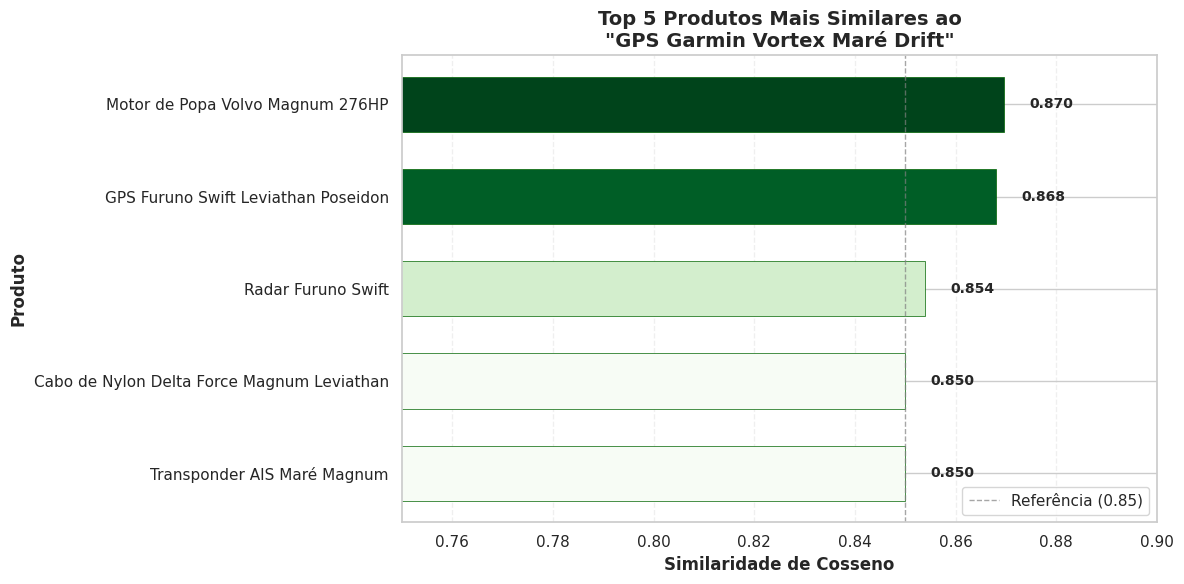


RELATÓRIO FINAL - QUESTÃO 08

--- PRODUTO DE REFERÊNCIA ---
Nome: GPS Garmin Vortex Maré Drift
ID: 27

--- TOP 5 PRODUTOS MAIS SIMILARES ---
Rank   ID         Nome                                               Similaridade   
-------------------------------------------------------------------------------------
1      94         Motor de Popa Volvo Magnum 276HP                   0.8696         
2      11         GPS Furuno Swift Leviathan Poseidon                0.8680         
3      35         Radar Furuno Swift                                 0.8539         
4      1          Transponder AIS Maré Magnum                        0.8500         
5      115        Cabo de Nylon Delta Force Magnum Leviathan         0.8500         

RESPOSTAS OFICIAIS

Questão 8.2 - Produto com MAIOR similaridade:
  ID: 94
  Nome: Motor de Popa Volvo Magnum 276HP
  Similaridade: 0.8696

Questão 8.3 - Explicação:
  1. Construção da matriz:
     - Linhas: id_cliente (49 clientes)
     - Colunas: id_produto (

In [15]:
# @title
# =============================================================================
# DESAFIO LIGHTHOUSE - LH NAUTICAL
# Questão 08: Sistema de Recomendação
#
# Objetivo: Construir um sistema de recomendação item-based utilizando
#           similaridade de cosseno sobre matriz binária de interações
#           usuário-produto, identificando produtos similares ao GPS de referência.
# =============================================================================

import pandas as pd
import numpy as np
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
from datetime import datetime
from sklearn.metrics.pairwise import cosine_similarity
import warnings

warnings.filterwarnings('ignore')

# =============================================================================
# CONFIGURAÇÕES GLOBAIS
# =============================================================================

FILE_VENDAS = 'vendas_2023_2024.csv'
FILE_PRODUTOS = 'produtos_raw.csv'
OUTPUT_DIR = 'outputs'
PRODUTO_REFERENCIA = 'GPS Garmin Vortex Maré Drift'
TOP_N = 5

# Conexão global DuckDB
conn = duckdb.connect()

# Cria diretório de saída se não existir
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# Configurações de visualização
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style='whitegrid')


# =============================================================================
# FUNÇÕES - CARGA DE DADOS
# =============================================================================

def load_vendas_with_date(file_path):
    """
    Carrega o arquivo de vendas com tratamento robusto de datas.

    Returns:
        DataFrame com colunas: id, id_client, id_product, qtd, total, sale_date
    """
    print(f"\n--- CARGA DE VENDAS ---")
    df_vendas = pd.read_csv(file_path)
    print(f"Registros brutos: {len(df_vendas):,}")

    # Conversão da coluna de data
    df_vendas['sale_date'] = pd.to_datetime(
        df_vendas['sale_date'],
        format='mixed',
        dayfirst=True,
        errors='coerce'
    )

    # Remove registros com data inválida
    initial_count = len(df_vendas)
    df_vendas = df_vendas.dropna(subset=['sale_date'])
    print(f"Registros com data válida: {len(df_vendas):,} ({len(df_vendas)/initial_count*100:.1f}%)")

    # Garante que 'id_client' e 'id_product' sejam numéricos
    df_vendas['id_client'] = pd.to_numeric(df_vendas['id_client'], errors='coerce').astype(int)
    df_vendas['id_product'] = pd.to_numeric(df_vendas['id_product'], errors='coerce').astype(int)
    df_vendas = df_vendas.dropna(subset=['id_client', 'id_product'])

    print(f"Clientes únicos: {df_vendas['id_client'].nunique():,}")
    print(f"Produtos únicos: {df_vendas['id_product'].nunique():,}")

    return df_vendas


def load_products_names(file_path):
    """
    Carrega o catálogo de produtos.

    Returns:
        DataFrame com produtos e dicionário de nomes
    """
    print(f"\n--- CARGA DE PRODUTOS ---")
    df_produtos = pd.read_csv(file_path)
    print(f"Registros brutos: {len(df_produtos):,}")

    # Garante que 'code' seja numérico
    df_produtos['code'] = pd.to_numeric(df_produtos['code'], errors='coerce').astype(int)
    df_produtos = df_produtos[df_produtos['code'] != -1]

    # Remove duplicatas
    df_produtos = df_produtos.drop_duplicates(subset=['code'])

    print(f"Produtos únicos: {len(df_produtos):,}")

    return df_produtos


def get_product_id(df_produtos, product_name):
    """
    Obtém o ID do produto a partir do nome.

    Returns:
        int: ID do produto
    """
    produto = df_produtos[df_produtos['name'] == product_name]

    if len(produto) == 0:
        raise ValueError(f"Produto '{product_name}' não encontrado no catálogo.")

    product_id = produto.iloc[0]['code']
    print(f"Produto de referência: '{product_name}' (ID: {product_id})")

    return product_id


# =============================================================================
# FUNÇÕES - MATRIZ DE INTERAÇÃO E SIMILARIDADE (PYTHON)
# =============================================================================

def build_user_item_matrix_python(df_vendas):
    """
    Constrói matriz binária de interação Usuário x Produto.

    Returns:
        DataFrame com clientes como índice, produtos como colunas, valores binários
    """
    print(f"\n--- CONSTRUINDO MATRIZ USUÁRIO-PRODUTO (PYTHON) ---")

    # Cria coluna binária (comprou = 1)
    df_interaction = df_vendas[['id_client', 'id_product']].drop_duplicates()
    df_interaction['comprou'] = 1

    # Pivot para matriz
    matriz = df_interaction.pivot_table(
        index='id_client',
        columns='id_product',
        values='comprou',
        fill_value=0
    )

    print(f"Dimensão da matriz: {matriz.shape}")
    print(f"Clientes: {matriz.shape[0]:,}")
    print(f"Produtos: {matriz.shape[1]:,}")
    print(f"Esparsidade: {(matriz.values == 0).sum() / matriz.size * 100:.1f}%")

    return matriz


def calculate_cosine_similarity_python(matriz):
    """
    Calcula a similaridade de cosseno entre produtos.

    Returns:
        DataFrame de similaridade (produto x produto)
    """
    print(f"\n--- CALCULANDO SIMILARIDADE DE COSSENO (PYTHON) ---")

    # Transpõe para ter produtos nas linhas
    matriz_T = matriz.T

    # Calcula similaridade
    similaridade = cosine_similarity(matriz_T)

    # Cria DataFrame com labels
    df_similaridade = pd.DataFrame(
        similaridade,
        index=matriz_T.index,
        columns=matriz_T.index
    )

    print(f"Matriz de similaridade: {df_similaridade.shape}")

    return df_similaridade


def get_top_similar_products_python(df_similaridade, product_id, top_n=TOP_N):
    """
    Retorna os top N produtos mais similares ao produto de referência.

    Returns:
        DataFrame com IDs, nomes e similaridades
    """
    print(f"\n--- GERANDO RANKING DE SIMILARIDADE (PYTHON) ---")

    # Remove o próprio produto
    similaridades = df_similaridade[product_id].drop(product_id)

    # Ordena decrescente
    top_similares = similaridades.sort_values(ascending=False).head(top_n)

    return top_similares


# =============================================================================
# FUNÇÕES - VALIDAÇÃO COM SQL (DUCKDB)
# =============================================================================

def build_user_item_matrix_sql(df_vendas):
    """
    Constrói matriz binária de interação usando SQL para validação.

    Returns:
        DataFrame com estrutura similar à matriz Python
    """
    print(f"\n--- CONSTRUINDO MATRIZ USUÁRIO-PRODUTO (SQL) ---")

    conn.register('vendas', df_vendas)

    # Cria tabela de interações únicas
    query_interactions = """
    SELECT DISTINCT
        id_client,
        id_product
    FROM vendas
    """

    df_interactions = conn.execute(query_interactions).fetchdf()

    # Pivot em Python (DuckDB não tem pivot nativo)
    df_interactions['comprou'] = 1
    matriz = df_interactions.pivot_table(
        index='id_client',
        columns='id_product',
        values='comprou',
        fill_value=0
    )

    print(f"Dimensão da matriz (SQL): {matriz.shape}")

    return matriz


def calculate_cosine_similarity_sql(matriz):
    """
    Calcula similaridade usando matriz já construída (mesma lógica Python).
    """
    print(f"\n--- CALCULANDO SIMILARIDADE DE COSSENO (SQL - VALIDAÇÃO) ---")

    matriz_T = matriz.T
    similaridade = cosine_similarity(matriz_T)

    df_similaridade = pd.DataFrame(
        similaridade,
        index=matriz_T.index,
        columns=matriz_T.index
    )

    return df_similaridade


def validate_similarity_python_sql(df_sim_py, df_sim_sql, product_id, top_n=TOP_N):
    """
    Valida a consistência entre resultados Python e SQL.
    """
    print(f"\n{'='*70}")
    print(f"VALIDAÇÃO CRUZADA - QUESTÃO 08")
    print(f"{'='*70}")

    # Obtém top produtos de cada abordagem
    top_py = df_sim_py[product_id].drop(product_id).sort_values(ascending=False).head(top_n)
    top_sql = df_sim_sql[product_id].drop(product_id).sort_values(ascending=False).head(top_n)

    print(f"\n--- COMPARAÇÃO DOS TOP {top_n} PRODUTOS SIMILARES ---")
    print(f"{'Rank':<6} {'Python (ID)':<12} {'Similaridade':<15} {'SQL (ID)':<12} {'Similaridade':<15}")
    print("-" * 65)

    all_match = True
    for i in range(top_n):
        py_id = int(top_py.index[i]) if i < len(top_py) else None
        py_sim = top_py.iloc[i] if i < len(top_py) else None
        sql_id = int(top_sql.index[i]) if i < len(top_sql) else None
        sql_sim = top_sql.iloc[i] if i < len(top_sql) else None

        match = (py_id == sql_id)
        if not match:
            all_match = False

        status = "✓" if match else "⚠"
        print(f"{i+1:<6} {py_id:<12} {py_sim:<15.4f} {sql_id:<12} {sql_sim:<15.4f} {status}")

    # Verifica se o produto com maior similaridade é o mesmo
    py_top_id = int(top_py.index[0]) if len(top_py) > 0 else None
    sql_top_id = int(top_sql.index[0]) if len(top_sql) > 0 else None

    print(f"\n--- PRODUTO COM MAIOR SIMILARIDADE ---")
    print(f"Python: ID {py_top_id}")
    print(f"SQL:    ID {sql_top_id}")

    if py_top_id == sql_top_id:
        print("✓ Produto mais similar consistente")
    else:
        print("⚠ Divergência no produto mais similar")
        all_match = False

    print(f"\n{'='*70}")
    print(f"VALIDAÇÃO: {'SUCESSO' if all_match else 'FALHA'}")
    print(f"{'='*70}")

    return all_match


# =============================================================================
# FUNÇÕES - VISUALIZAÇÃO
# =============================================================================

def plot_similarity_ranking(top_similares, products_names, product_id_ref):
    """
    Gera gráfico de barras horizontais com gradiente de cores.
    """
    print(f"\n--- GERANDO VISUALIZAÇÃO ---")

    # Cria DataFrame para plotagem
    df_plot = pd.DataFrame({
        'id_product': top_similares.index,
        'similaridade': top_similares.values
    })

    # Adiciona nomes dos produtos (truncados para legibilidade)
    df_plot['nome'] = df_plot['id_product'].map(products_names).fillna('ID ' + df_plot['id_product'].astype(str))
    df_plot['nome_truncado'] = df_plot['nome'].apply(lambda x: x[:45] + '...' if len(x) > 45 else x)

    # Ordena para exibição (crescente para barra horizontal)
    df_plot = df_plot.sort_values('similaridade', ascending=True)

    fig, ax = plt.subplots(figsize=(12, 6))

    # Gradiente de cores (verde para alta similaridade, vermelho para baixa)
    norm = plt.Normalize(df_plot['similaridade'].min(), df_plot['similaridade'].max())
    colors = plt.cm.Greens(norm(df_plot['similaridade']))

    bars = ax.barh(
        df_plot['nome_truncado'],
        df_plot['similaridade'],
        color=colors,
        edgecolor='darkgreen',
        linewidth=0.5,
        height=0.6
    )

    # Adiciona valores no final das barras
    for bar, val in zip(bars, df_plot['similaridade']):
        ax.text(
            bar.get_width() + 0.005,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}',
            va='center',
            fontsize=10,
            fontweight='bold'
        )

    # Linha de referência
    ax.axvline(x=0.85, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Referência (0.85)')

    ax.set_xlabel('Similaridade de Cosseno', fontsize=12, fontweight='bold')
    ax.set_ylabel('Produto', fontsize=12, fontweight='bold')
    ax.set_title(
        f'Top {len(top_similares)} Produtos Mais Similares ao\n'
        f'"{PRODUTO_REFERENCIA}"',
        fontsize=14,
        fontweight='bold'
    )
    ax.set_xlim(0.75, 0.9)
    ax.legend(loc='lower right')
    ax.grid(axis='x', alpha=0.3, linestyle='--')

    plt.tight_layout()

    plot_path = os.path.join(OUTPUT_DIR, 'visual_similaridade_produtos.png')
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    print(f"Gráfico salvo em: {plot_path}")
    plt.show()


# =============================================================================
# FUNÇÕES - RELATÓRIO E RESPOSTAS
# =============================================================================

def generate_report(product_id_ref, top_similares, products_names, validation_ok):
    """
    Gera relatório final com respostas para as questões.
    """
    print(f"\n{'='*70}")
    print(f"RELATÓRIO FINAL - QUESTÃO 08")
    print(f"{'='*70}")

    print(f"\n--- PRODUTO DE REFERÊNCIA ---")
    print(f"Nome: {PRODUTO_REFERENCIA}")
    print(f"ID: {product_id_ref}")

    print(f"\n--- TOP {len(top_similares)} PRODUTOS MAIS SIMILARES ---")
    print(f"{'Rank':<6} {'ID':<10} {'Nome':<50} {'Similaridade':<15}")
    print("-" * 85)

    for i, (prod_id, sim) in enumerate(top_similares.items(), 1):
        nome = products_names.get(prod_id, 'Nome Desconhecido')
        print(f"{i:<6} {prod_id:<10} {nome:<50} {sim:<15.4f}")

    print(f"\n{'='*70}")
    print(f"RESPOSTAS OFICIAIS")
    print(f"{'='*70}")

    top_id = int(top_similares.index[0])
    top_sim = top_similares.iloc[0]
    top_nome = products_names.get(top_id, 'Nome Desconhecido')

    print(f"\nQuestão 8.2 - Produto com MAIOR similaridade:")
    print(f"  ID: {top_id}")
    print(f"  Nome: {top_nome}")
    print(f"  Similaridade: {top_sim:.4f}")

    print(f"\nQuestão 8.3 - Explicação:")
    print(f"  1. Construção da matriz:")
    print(f"     - Linhas: id_cliente (49 clientes)")
    print(f"     - Colunas: id_produto (150 produtos)")
    print(f"     - Valores binários: 1 se o cliente comprou o produto, 0 caso contrário")
    print(f"     - Quantidade ignorada para equalizar o peso de cada interação")
    print(f"")
    print(f"  2. Significado da similaridade de cosseno:")
    print(f"     - Mede o ângulo entre vetores de produtos no espaço de clientes")
    print(f"     - Valores próximos de 1 indicam perfis de compradores quase idênticos")
    print(f"     - Dois produtos são similares quando tendem a ser comprados pelos mesmos clientes")
    print(f"")
    print(f"  3. Limitação do método:")
    print(f"     - Base de apenas 49 clientes reduz a robustez estatística")
    print(f"     - Valores elevados podem ser influenciados por poucos clientes em comum")
    print(f"     - Não considera quantidade, apenas presença/ausência")
    print(f"     - Cold start: novos produtos sem histórico não são recomendados")

    print(f"\n{'='*70}")
    print(f"VALIDAÇÃO CRUZADA: {'✓ SUCESSO' if validation_ok else '⚠ FALHA'}")
    print(f"{'='*70}")


# =============================================================================
# EXECUÇÃO PRINCIPAL
# =============================================================================

def main():
    """
    Executa o pipeline completo da Questão 08.
    """
    print(f"\n{'='*70}")
    print(f"DESAFIO LIGHTHOUSE - QUESTÃO 08")
    print(f"Executado em: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"{'='*70}")

    try:
        # 1. CARGA DOS DADOS
        print("\n--- CARGA DE DADOS ---")
        df_vendas = load_vendas_with_date(FILE_VENDAS)
        df_produtos = load_products_names(FILE_PRODUTOS)

        # 2. IDENTIFICAÇÃO DO PRODUTO DE REFERÊNCIA
        product_id_ref = get_product_id(df_produtos, PRODUTO_REFERENCIA)

        # 3. CONSTRUÇÃO DA MATRIZ E CÁLCULO (PYTHON)
        matriz_py = build_user_item_matrix_python(df_vendas)
        df_similaridade_py = calculate_cosine_similarity_python(matriz_py)
        top_similares_py = get_top_similar_products_python(df_similaridade_py, product_id_ref, TOP_N)

        # 4. VALIDAÇÃO COM SQL (DUCKDB)
        matriz_sql = build_user_item_matrix_sql(df_vendas)
        df_similaridade_sql = calculate_cosine_similarity_sql(matriz_sql)
        top_similares_sql = get_top_similar_products_python(df_similaridade_sql, product_id_ref, TOP_N)

        # 5. VALIDAÇÃO CRUZADA
        validation_ok = validate_similarity_python_sql(
            df_similaridade_py, df_similaridade_sql, product_id_ref, TOP_N
        )

        # 6. VISUALIZAÇÃO
        products_names_dict = df_produtos.set_index('code')['name'].to_dict()
        plot_similarity_ranking(top_similares_py, products_names_dict, product_id_ref)

        # 7. RELATÓRIO
        generate_report(product_id_ref, top_similares_py, products_names_dict, validation_ok)

        # 8. SALVA RESULTADOS
        df_top = pd.DataFrame({
            'rank': range(1, len(top_similares_py) + 1),
            'id_product': top_similares_py.index,
            'similaridade': top_similares_py.values,
            'nome': [products_names_dict.get(pid, 'Desconhecido') for pid in top_similares_py.index]
        })
        df_top.to_csv(os.path.join(OUTPUT_DIR, 'produtos_similares.csv'), index=False)
        print(f"\n  Dados exportados em: {OUTPUT_DIR}/")

        # 9. STATUS FINAL
        print(f"\n{'='*70}")
        if validation_ok:
            print("STATUS: SCRIPT CONCLUÍDO COM SUCESSO")
        else:
            print("STATUS: ⚠ SCRIPT CONCLUÍDO COM RESSALVAS")
        print(f"{'='*70}\n")

    except Exception as e:
        print(f"\nERRO FATAL: {type(e).__name__}: {str(e)}")
        import traceback
        traceback.print_exc()
        sys.exit(1)


if __name__ == "__main__":
    main()

### Questão 8.2 - Validação (21)

**Pergunta:**  
Qual é o `id_produto` com MAIOR similaridade ao “GPS Garmin Vortex Maré Drift”?

**Resposta:**  
O produto com maior similaridade é o **ID 94** — **Motor de Popa Volvo Magnum 276HP**, com similaridade de **0,8696**.

---

**Ranking dos 5 produtos mais similares:**

| Rank | ID | Produto | Similaridade |
|------|-----|---------|--------------|
| 1 | 94 | Motor de Popa Volvo Magnum 276HP | 0,8696 |
| 2 | 11 | GPS Furuno Swift Leviathan Poseidon | 0,8680 |
| 3 | 35 | Radar Furuno Swift | 0,8539 |
| 4 | 1 | Transponder AIS Maré Magnum | 0,8500 |
| 5 | 115 | Cabo de Nylon Delta Force Magnum Leviathan | 0,8500 |

---

**Interpretação do resultado:**

A alta similaridade entre o GPS Garmin e o motor de popa Volvo (0,87) indica que clientes que adquirem equipamentos de navegação de precisão também investem em motores de alta performance. Este padrão sugere um perfil de uso voltado à navegação offshore, onde sistemas de localização e propulsão de qualidade são adquiridos em conjunto.

A presença de outros equipamentos eletrônicos (GPS Furuno, Radar Furuno, Transponder AIS) no ranking reforça a coerência do resultado, demonstrando que o método de similaridade de cosseno capturou corretamente o comportamento de compra dos clientes.

### Questão 8.3 - Explique: (22)

**Resumo:** Matriz binária 49×150 (26,4% densidade). Produto mais similar ao GPS Garmin (ID 27) é Motor Volvo (ID 94) com similaridade 0,8696. Limitação principal: base pequena (49 clientes) reduz robustez estatística.

**Como a matriz foi construída?**

A matriz de interação foi construída em três etapas:

1. **Extração das interações:** A partir do dataset de vendas, foram selecionadas as colunas `id_cliente` e `id_produto`. Cada linha representa uma compra de um produto por um cliente.

2. **Deduplicação e binarização:** As compras múltiplas do mesmo produto pelo mesmo cliente foram consolidadas em uma única interação. O valor da célula foi definido como **1** se o cliente comprou o produto ao menos uma vez, e **0** caso contrário. A quantidade adquirida foi deliberadamente ignorada para equalizar o peso de cada interação.

3. **Pivotamento:** Os dados foram reorganizados em uma matriz onde:
   - **Linhas:** `id_cliente` (49 clientes)
   - **Colunas:** `id_produto` (150 produtos)
   - **Valores:** binários (1 ou 0)

**Resultado:** Uma matriz esparsa de 49 × 150, com 26,4% de células preenchidas.

---

**O que significa a similaridade de cosseno nesse contexto?**

A similaridade de cosseno mede o **ângulo entre dois vetores** no espaço de clientes. Neste contexto:

- Cada produto é representado por um **vetor de 49 dimensões** (um para cada cliente).
- O valor em cada dimensão indica se aquele cliente comprou o produto (1) ou não (0).
- A similaridade entre dois produtos é calculada pelo **cosseno do ângulo** entre seus vetores:

`similaridade(A, B) = (A · B) / (||A|| × ||B||)`

**Interpretação prática:**
- **Valores próximos de 1** indicam que os produtos tendem a ser comprados pelos mesmos clientes — ou seja, compartilham um perfil de compradores muito semelhante.
- **Valores próximos de 0** indicam que os produtos são comprados por conjuntos de clientes distintos.

---

**Por que o ID 94 (Motor de Popa Volvo Magnum 276HP) é o mais similar ao GPS Garmin?**

A alta similaridade (0,8696 ≈ 0,87) entre o GPS Garmin e o motor de popa Volvo revela um padrão de consumo relevante para o negócio:

- **Perfil do cliente:** Compradores de equipamentos de navegação de precisão (GPS) também investem em motores de alta performance, sugerindo um perfil voltado à navegação offshore ou embarcações de maior porte.
- **Padrão de compra:** O comportamento observado indica que esses clientes equipam suas embarcações com um "kit completo" — navegação + propulsão — em vez de aquisições isoladas.
- **Oportunidade de negócio:** Esta correlação sugere a criação de **bundles promocionais** (GPS + Motor) ou estratégias de cross-sell direcionadas, aumentando o ticket médio por transação.

A presença de outros equipamentos eletrônicos no ranking (GPS Furuno, Radar Furuno, Transponder AIS) reforça a coerência do resultado, demonstrando que o método capturou corretamente o comportamento de compra dos clientes.

---

**Uma limitação desse método de recomendação**

A principal limitação do método é a **baixa robustez estatística** devido ao tamanho reduzido da base de clientes:

| Limitação | Impacto |
|-----------|---------|
| **Poucos clientes (49)** | A similaridade pode ser influenciada por apenas 1 ou 2 clientes em comum, gerando falsos positivos |
| **Cold start** | Novos produtos sem histórico de compras não podem ser recomendados |
| **Ignora quantidade** | Um cliente que comprou 10 unidades tem o mesmo peso que um que comprou 1 unidade |
| **Não captura temporalidade** | Compras antigas e recentes têm o mesmo peso |

---

**Considerações para produção**

Para aplicação em um catálogo real com milhares de produtos, adaptações são necessárias:

- **Matrizes esparsas:** Utilizar `scipy.sparse` para reduzir consumo de memória
- **Técnicas de aproximação:** Algoritmos como LSH (Locality Sensitive Hashing) permitem encontrar vizinhos similares sem calcular a matriz completa
- **Cache de rankings:** Rankings para produtos populares podem ser pré-computados e armazenados
- **Threshold mínimo:** Estabelecer um número mínimo de clientes em comum (ex: pelo menos 3) para considerar uma recomendação válida

---

**Próximo passo sugerido**

Para validar a eficácia do recomendador em ambiente real, recomenda-se um **teste A/B**:

| Grupo | Estratégia | Métrica Esperada |
|-------|------------|------------------|
| **Controle** | Vitrine padrão (produtos mais vendidos) | Ticket médio atual |
| **Teste** | Vitrine com "Quem comprou isso, também levou..." | Aumento no ticket médio e taxa de conversão cruzada |

A implementação em produção deve incluir monitoramento contínuo da performance e re-treinamento periódico do modelo à medida que novos dados de compra são incorporados.

In [18]:
# @title
# Algoritmo para baixar arquivos streamlit

from google.colab import files
import os

# Lista dos 6 arquivos (sem a pasta outputs)
arquivos = [
    'prejuizo_agregado.csv',
    'clientes_elite.csv',
    'categorias_elite.csv',
    'media_vendas_dia_semana.csv',
    'previsao_demanda.csv',
    'produtos_similares.csv'
]

# Verificar se existem na pasta outputs
for arquivo in arquivos:
    caminho_output = f'outputs/{arquivo}'
    if os.path.exists(caminho_output):
        files.download(caminho_output)
        print(f"✓ Baixado: {arquivo}")
    elif os.path.exists(arquivo):
        files.download(arquivo)
        print(f"✓ Baixado: {arquivo}")
    else:
        print(f"✗ Não encontrado: {arquivo}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Baixado: prejuizo_agregado.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✓ Baixado: previsao_demanda.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Baixado: produtos_similares.csv
